# SENTRAL — Multi-Spectrum Stock Analysis
### Complete Investment Decision Engine: Fundamental + Technical + Sentiment + Forecasting

**How to use:**
1. Set your `TICKER` in Section 1 (e.g. `'HAL.NS'` for NSE, `'AAPL'` for US stocks)
2. Run all cells top to bottom (Run All)
3. Review the final **BUY / HOLD / SELL** recommendation at the end

---
| Section | What it does |
|---------|-------------|
| 1. Setup | Loads env, installs missing packages |
| 2. Data | Downloads OHLCV via yfinance |
| 3. Fundamentals | 14+ ratios, Piotroski F-Score, Altman Z-Score |
| 4. Technicals | 18+ indicators, interactive charts |
| 5. Peer Compare | Sector benchmarking |
| 6. News APIs | 7 sources — AlphaVantage, Finnhub, Tavily, NewsAPI, EODHD, Marketaux, APILayer |
| 7. Web Scraping | Yahoo Finance, MoneyControl, Economic Times, Reuters (BS4 + Selenium) |
| 8. Sentiment | NLTK VADER, FinBERT, DistilRoberta, RoBERTa-large, StockTwits, Gemma-2, Llama-3, Mixtral, Gemini |
| 9. Forecasting | LSTM + Transformer price prediction (PyTorch) |
| 10. Signal Engine | Ensemble Buy/Hold/Sell probabilities |

# Section 1 — Setup & Configuration

In [130]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

required = [
    "yfinance", "ta", "mplfinance", "plotly", "seaborn", "requests",
    "python-dotenv", "nltk", "transformers", "huggingface-hub",
    "beautifulsoup4", "newspaper3k", "lxml", "feedparser",
    "gnews", "newsapi-python", "tavily-python", "google-generativeai",
    "openai", "groq", "scikit-learn", "torch", "selenium", "webdriver-manager",
    "stockstats", "scipy"
]

for pkg in required:
    try:
        __import__(pkg.replace("-","_").split(">=")[0])
    except ImportError:
        print(f"Installing {pkg}...")
        pip_install(pkg)

print("All packages ready.")

Installing python-dotenv...
Installing beautifulsoup4...
Installing newspaper3k...
Installing newsapi-python...
Installing tavily-python...
Installing google-generativeai...
Installing scikit-learn...
All packages ready.


In [131]:
# ── Core imports ────────────────────────────────────────────────────────────
import os, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import mplfinance as mpf
from IPython.display import display, HTML

# ── Environment variables ───────────────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv()

# ── Stock data ──────────────────────────────────────────────────────────────
import yfinance as yf

# ── Technical analysis ──────────────────────────────────────────────────────
import ta
from stockstats import StockDataFrame

# ── NLP & Sentiment ─────────────────────────────────────────────────────────
import nltk
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# ── ML / Deep Learning ──────────────────────────────────────────────────────
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Web requests & scraping ─────────────────────────────────────────────────
import requests
from bs4 import BeautifulSoup
import feedparser

print("✅ All imports successful")
print(f"   PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print(f"   Pandas : {pd.__version__} | NumPy: {np.__version__}")

✅ All imports successful
   PyTorch: 2.12.0+cpu | CUDA: False
   Pandas : 3.0.3 | NumPy: 2.4.6


In [132]:
# ════════════════════════════════════════════════════════════════════════════
# ★  CHANGE THIS TICKER TO ANALYSE ANY STOCK  ★
# Examples: 'RELIANCE.NS', 'TCS.NS', 'HAL.NS'  ← NSE India
#           'AAPL', 'MSFT', 'NVDA', 'TSLA'     ← US Stocks
# ════════════════════════════════════════════════════════════════════════════
TICKER        = 'HAL.NS'         # Primary stock
PERIOD        = '2y'             # Data period: 1y, 2y, 5y
PERIOD_HIST   = '1y'             # History window for technical charts
BENCHMARK     = '^NSEI'          # Benchmark index: ^NSEI (Nifty), ^GSPC (S&P500)
CURRENCY_SYM  = '₹'             # ₹ for INR, $ for USD
MAX_NEWS      = 15               # Max news articles per source

# ── API Keys from .env ──────────────────────────────────────────────────────
ALPHA_VANTAGE_KEY = os.getenv("ALPHA_VANTAGE_API_KEY", "")
FINNHUB_KEY       = os.getenv("FINNHUB_API_KEY", "")
TAVILY_KEY        = os.getenv("TAVILY_API_KEY", "")
NEWSAPI_KEY       = os.getenv("NEWSAPI_KEY", "")
EODHD_KEY         = os.getenv("EODHD_API_KEY", "")
MARKETAUX_KEY     = os.getenv("MARKETAUX_API_KEY", "")
APILAYER_KEY      = os.getenv("APILAYER_API_KEY", "")
HF_TOKEN          = os.getenv("HF_TOKEN", "")
GROQ_KEY          = os.getenv("GROQ_API_KEY", "")
GEMINI_KEY        = os.getenv("GEMINI_API_KEY", "")
os.environ["HF_TOKEN"] = HF_TOKEN

print(f"📈 Analysing: {TICKER}")
print(f"   Benchmark : {BENCHMARK}")
print(f"   Period    : {PERIOD}")
keys_loaded = sum(bool(k) for k in [ALPHA_VANTAGE_KEY, FINNHUB_KEY, TAVILY_KEY, NEWSAPI_KEY, 
                                      EODHD_KEY, MARKETAUX_KEY, APILAYER_KEY, HF_TOKEN, GROQ_KEY, GEMINI_KEY])
print(f"   API keys loaded: {keys_loaded}/10")

📈 Analysing: HAL.NS
   Benchmark : ^NSEI
   Period    : 2y
   API keys loaded: 10/10


# Section 2 — Data Collection

In [133]:
print(f"⬇  Downloading {TICKER} data ({PERIOD})…")

stock     = yf.Ticker(TICKER)
info      = stock.info

# OHLCV data (auto-adjusted for splits/dividends)
data      = yf.download(TICKER, period=PERIOD, auto_adjust=True, progress=False)
hist      = stock.history(period=PERIOD)

# Flatten MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns]

# Financial statements
financials    = stock.financials       # income statement (columns = yearly)
balance_sheet = stock.balance_sheet
cashflow      = stock.cashflow

# Transposed for easier row-access by date
fin = stock.financials.T
bal = stock.balance_sheet.T
cf  = stock.cashflow.T

# Basic info
company_name = info.get("longName", TICKER)
sector       = info.get("sector", "N/A")
industry     = info.get("industry", "N/A")
currency     = info.get("currency", "INR")
exchange     = info.get("exchange", "N/A")

print(f"\n✅ Data loaded for: {company_name}")
print(f"   Exchange : {exchange} | Currency: {currency}")
print(f"   Sector   : {sector}")
print(f"   Industry : {industry}")
print(f"   Rows     : {len(data)}  ({data.index[0].date()} → {data.index[-1].date()})")

⬇  Downloading HAL.NS data (2y)…

✅ Data loaded for: Hindustan Aeronautics Limited
   Exchange : NSI | Currency: INR
   Sector   : Industrials
   Industry : Aerospace & Defense
   Rows     : 498  (2024-05-29 → 2026-05-29)


In [134]:
# Quick preview of price data
print("=== Price Data (Last 5 rows) ===")
display(data.tail())

# Benchmark download
try:
    bench = yf.download(BENCHMARK, period=PERIOD, auto_adjust=True, progress=False)
    if isinstance(bench.columns, pd.MultiIndex):
        bench.columns = [col[0] for col in bench.columns]
    print(f"\n✅ Benchmark {BENCHMARK} loaded: {len(bench)} rows")
except Exception as e:
    bench = None
    print(f"⚠  Benchmark download failed: {e}")

=== Price Data (Last 5 rows) ===


,Close,High,Low,Open,Volume
Date,,,,,
2026-05-25,4425.899902,4437.899902,4385.399902,4391.200195,1063255
2026-05-26,4427.700195,4449.299805,4393.700195,4424.899902,983680
2026-05-27,4413.000000,4474.000000,4404.200195,4430.000000,502395
2026-05-28,4413.000000,4413.000000,4413.000000,4413.000000,0
2026-05-29,4303.799805,4418.000000,4255.299805,4409.799805,4597399



✅ Benchmark ^NSEI loaded: 495 rows


# Section 3 — Fundamental Analysis
## 3.1 — Key Metrics Overview (14+ ratios)

In [135]:
def safe(d, key, default=None):
    """Safely get value from dict or series."""
    try:
        val = d.get(key, default) if isinstance(d, dict) else d[key]
        return val if pd.notna(val) else default
    except Exception:
        return default

# ── Build comprehensive metrics table ────────────────────────────────────────
mc  = info.get('marketCap', None)
rev = info.get('totalRevenue', None)
eps = safe(info, 'trailingEps')
bvs = safe(info, 'bookValue')
price = safe(info, 'currentPrice') or safe(info, 'regularMarketPrice')

# Compute derived metrics from financial statements
try:
    _b = bal.iloc[0]; _f = fin.iloc[0]; _c = cf.iloc[0]
    _ebit    = _f.get('EBIT') or _f.get('Operating Income')
    _int_exp = abs(_f.get('Interest Expense', 0) or 0)
    _fcf     = _c.get('Free Cash Flow')
    _ni      = _f.get('Net Income')
    _ta      = _b.get('Total Assets')
    _eq      = _b.get('Common Stock Equity') or _b.get('Stockholders Equity')
    _rv      = _f.get('Total Revenue')

    interest_coverage = round(_ebit / _int_exp, 2) if (_ebit and _int_exp) else None
    fcf_yield         = round((_fcf / mc) * 100, 2) if (_fcf and mc) else None
    fcf_per_share     = round(_fcf / info.get('sharesOutstanding', 1), 2) if _fcf else None
    earnings_yield    = round((eps / price) * 100, 2) if (eps and price) else None
    graham_number     = round((22.5 * abs(eps) * abs(bvs)) ** 0.5, 2) if (eps and bvs and eps > 0 and bvs > 0) else None
    # DuPont: ROE = Net Margin x Asset Turnover x Equity Multiplier
    net_margin_dp  = (_ni / _rv)  if (_ni and _rv) else None
    asset_turn_dp  = (_rv / _ta)  if (_rv and _ta) else None
    equity_mult_dp = (_ta / _eq)  if (_ta and _eq) else None
    roe_dupont     = round(net_margin_dp * asset_turn_dp * equity_mult_dp * 100, 2) if all(
        v is not None for v in [net_margin_dp, asset_turn_dp, equity_mult_dp]) else None
except Exception as _e:
    interest_coverage = fcf_yield = fcf_per_share = earnings_yield = graham_number = roe_dupont = None
    net_margin_dp = asset_turn_dp = equity_mult_dp = None

metrics = {
    # ── Valuation ────────────────────────────────────────────────────────────
    "P/E Ratio (TTM)"            : safe(info, 'trailingPE'),
    "Forward P/E"                : safe(info, 'forwardPE'),
    "P/B Ratio"                  : safe(info, 'priceToBook'),
    "P/S Ratio"                  : round(mc/rev, 2) if mc and rev else None,
    "PEG Ratio"                  : safe(info, 'pegRatio'),
    "EV/EBITDA"                  : safe(info, 'enterpriseToEbitda'),
    "EV/Revenue"                 : safe(info, 'enterpriseToRevenue'),
    "Earnings Yield (%)"         : earnings_yield,
    "Graham Number"              : graham_number,
    # ── Profitability ─────────────────────────────────────────────────────────
    "ROE (%)"                    : round(safe(info,'returnOnEquity',0)*100, 2),
    "ROA (%)"                    : round(safe(info,'returnOnAssets',0)*100, 2),
    "Gross Margin (%)"           : round(safe(info,'grossMargins',0)*100, 2),
    "Operating Margin (%)"       : round(safe(info,'operatingMargins',0)*100, 2),
    "Net Margin (%)"             : round(safe(info,'profitMargins',0)*100, 2),
    "EBITDA Margin (%)"          : round(safe(info,'ebitdaMargins',0)*100, 2) if safe(info,'ebitdaMargins') else None,
    "Interest Coverage (x)"      : interest_coverage,
    # ── DuPont ROE Decomposition ──────────────────────────────────────────────
    "DuPont ROE (%)"             : roe_dupont,
    "  DuPont: Net Margin (%)"   : round(net_margin_dp*100, 2) if net_margin_dp else None,
    "  DuPont: Asset Turnover"   : round(asset_turn_dp, 4) if asset_turn_dp else None,
    "  DuPont: Equity Multiplier": round(equity_mult_dp, 4) if equity_mult_dp else None,
    # ── Growth ────────────────────────────────────────────────────────────────
    "Revenue Growth (YoY %)"     : round(safe(info,'revenueGrowth',0)*100, 2),
    "Earnings Growth (YoY %)"    : round(safe(info,'earningsGrowth',0)*100, 2) if safe(info,'earningsGrowth') else None,
    # ── Per Share ────────────────────────────────────────────────────────────
    "EPS (TTM)"                  : eps,
    "Forward EPS"                : safe(info, 'forwardEps'),
    "Book Value/Share"           : bvs,
    "FCF per Share"              : fcf_per_share,
    "Dividend Yield (%)"         : round(safe(info,'dividendYield',0)*100, 2),
    # ── Solvency / Liquidity ─────────────────────────────────────────────────
    "Debt/Equity"                : safe(info, 'debtToEquity'),
    "Current Ratio"              : safe(info, 'currentRatio'),
    "Quick Ratio"                : safe(info, 'quickRatio'),
    "FCF Yield (%)"              : fcf_yield,
    "Total Debt"                 : safe(info, 'totalDebt'),
    "Total Cash"                 : safe(info, 'totalCash'),
    # ── Size & Market ─────────────────────────────────────────────────────────
    "Market Cap"                 : mc,
    "Enterprise Value"           : safe(info, 'enterpriseValue'),
    "52-Week High"               : safe(info, 'fiftyTwoWeekHigh'),
    "52-Week Low"                : safe(info, 'fiftyTwoWeekLow'),
    "Beta"                       : safe(info, 'beta'),
}

df_metrics = pd.DataFrame(metrics.items(), columns=["Metric", "Value"])
df_metrics["Value"] = df_metrics["Value"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) and x > 1e6
    else (f"{x:.4f}" if isinstance(x, float) else x)
)
print(f"=== {company_name} \u2014 Fundamental Snapshot ({len(metrics)} metrics) ===")
display(df_metrics.set_index("Metric"))

# ── DuPont summary ───────────────────────────────────────────────────────────
if all(v is not None for v in [net_margin_dp, asset_turn_dp, equity_mult_dp]):
    print(f"\n\u2554{'\u2550'*60}\u2557")
    print(f"\u2551  DuPont ROE Decomposition (most recent fiscal year)       \u2551")
    print(f"\u2554{'\u2550'*60}\u2557")
    print(f"  ROE = Net Margin  \u00d7  Asset Turnover  \u00d7  Equity Multiplier")
    print(f"      = {net_margin_dp*100:.2f}%  \u00d7  {asset_turn_dp:.4f}  \u00d7  {equity_mult_dp:.4f}")
    print(f"      = {roe_dupont:.2f}%")
    print(f"  (yfinance ROE = {round(safe(info,'returnOnEquity',0)*100,2)}%)")


=== Hindustan Aeronautics Limited — Fundamental Snapshot (38 metrics) ===


,Value
Metric,
P/E Ratio (TTM),31.5458
Forward P/E,25.7844
P/B Ratio,7.0135
P/S Ratio,8.7000
PEG Ratio,nan
EV/EBITDA,29.7250
EV/Revenue,7.3030
Earnings Yield (%),3.1700
Graham Number,1372.4800



╔════════════════════════════════════════════════════════════╗
║  DuPont ROE Decomposition (most recent fiscal year)       ║
╔════════════════════════════════════════════════════════════╗
  ROE = Net Margin  ×  Asset Turnover  ×  Equity Multiplier
      = 27.55%  ×  0.2499  ×  3.2264
      = 22.21%
  (yfinance ROE = 23.98%)


## 3.2 — Income Statement, Balance Sheet & Cash Flow Trends

In [136]:
# ── Income Statement Trends ──────────────────────────────────────────────────
try:
    fin_disp = fin.copy()
    for col in ['Total Revenue', 'Net Income', 'Gross Profit', 'Operating Income']:
        if col in fin_disp.columns:
            fin_disp[col] = fin_disp[col] / 1e9  # → Billions

    cols_show = [c for c in ['Total Revenue', 'Gross Profit', 'Operating Income', 'Net Income']
                 if c in fin_disp.columns]
    print("=== Income Statement Trends (Billions) ===")
    display(fin_disp[cols_show].round(3).tail(5))

    # YoY Growth
    if 'Total Revenue' in fin.columns and 'Net Income' in fin.columns:
        growth = pd.DataFrame({
            'Revenue Growth %'   : fin['Total Revenue'].pct_change() * 100,
            'Net Income Growth %': fin['Net Income'].pct_change() * 100,
        })
        print("\n=== YoY Growth (%) ===")
        display(growth.round(2).tail(4))
except Exception as e:
    print(f"Income statement: {e}")

=== Income Statement Trends (Billions) ===


,Total Revenue,Gross Profit,Operating Income,Net Income
2026-03-31,330.888,118.284,84.273,91.156
2025-03-31,309.810,126.049,82.924,83.641
2024-03-31,281.619,119.434,84.046,76.210
2023-03-31,263.606,109.161,57.087,58.277
2022-03-31,NaN,NaN,NaN,NaN



=== YoY Growth (%) ===


,Revenue Growth %,Net Income Growth %
2025-03-31,-6.37,-8.24
2024-03-31,-9.10,-8.88
2023-03-31,-6.40,-23.53
2022-03-31,NaN,NaN


In [137]:
# ── Balance Sheet Snapshot ──────────────────────────────────────────────────
try:
    bal_disp = bal.copy()
    for col in bal_disp.select_dtypes(include='number').columns:
        bal_disp[col] = bal_disp[col] / 1e9
    cols_bs = [c for c in ['Total Assets', 'Total Liabilities Net Minority Interest',
                            'Stockholders Equity', 'Long Term Debt', 'Cash And Cash Equivalents']
               if c in bal_disp.columns]
    print("=== Balance Sheet (Billions) ===")
    display(bal_disp[cols_bs].round(3).tail(4))
except Exception as e:
    print(f"Balance sheet: {e}")

# ── Cash Flow ────────────────────────────────────────────────────────────────
try:
    cf_disp = cf.copy()
    for col in cf_disp.select_dtypes(include='number').columns:
        cf_disp[col] = cf_disp[col] / 1e9
    cf_cols = [c for c in ['Operating Cash Flow', 'Free Cash Flow',
                            'Cash Flow From Continuing Operating Activities',
                            'Capital Expenditure']
               if c in cf_disp.columns]
    if cf_cols:
        print("\n=== Cash Flow (Billions) ===")
        display(cf_disp[cf_cols].round(3).tail(4))
except Exception as e:
    print(f"Cash flow: {e}")

=== Balance Sheet (Billions) ===


,Total Assets,Total Liabilities Net Minority Interest,Stockholders Equity,Long Term Debt,Cash And Cash Equivalents
2025-03-31,1062.668,712.817,349.816,0.0,45.486
2024-03-31,780.952,489.534,291.382,0.0,42.547
2023-03-31,672.038,436.279,235.722,0.0,44.408
2022-03-31,NaN,NaN,NaN,NaN,NaN



=== Cash Flow (Billions) ===


,Operating Cash Flow,Free Cash Flow,Capital Expenditure
2025-03-31,136.435,118.865,-17.569
2024-03-31,82.228,64.677,-17.552
2023-03-31,88.297,70.485,-17.812
2022-03-31,NaN,NaN,NaN


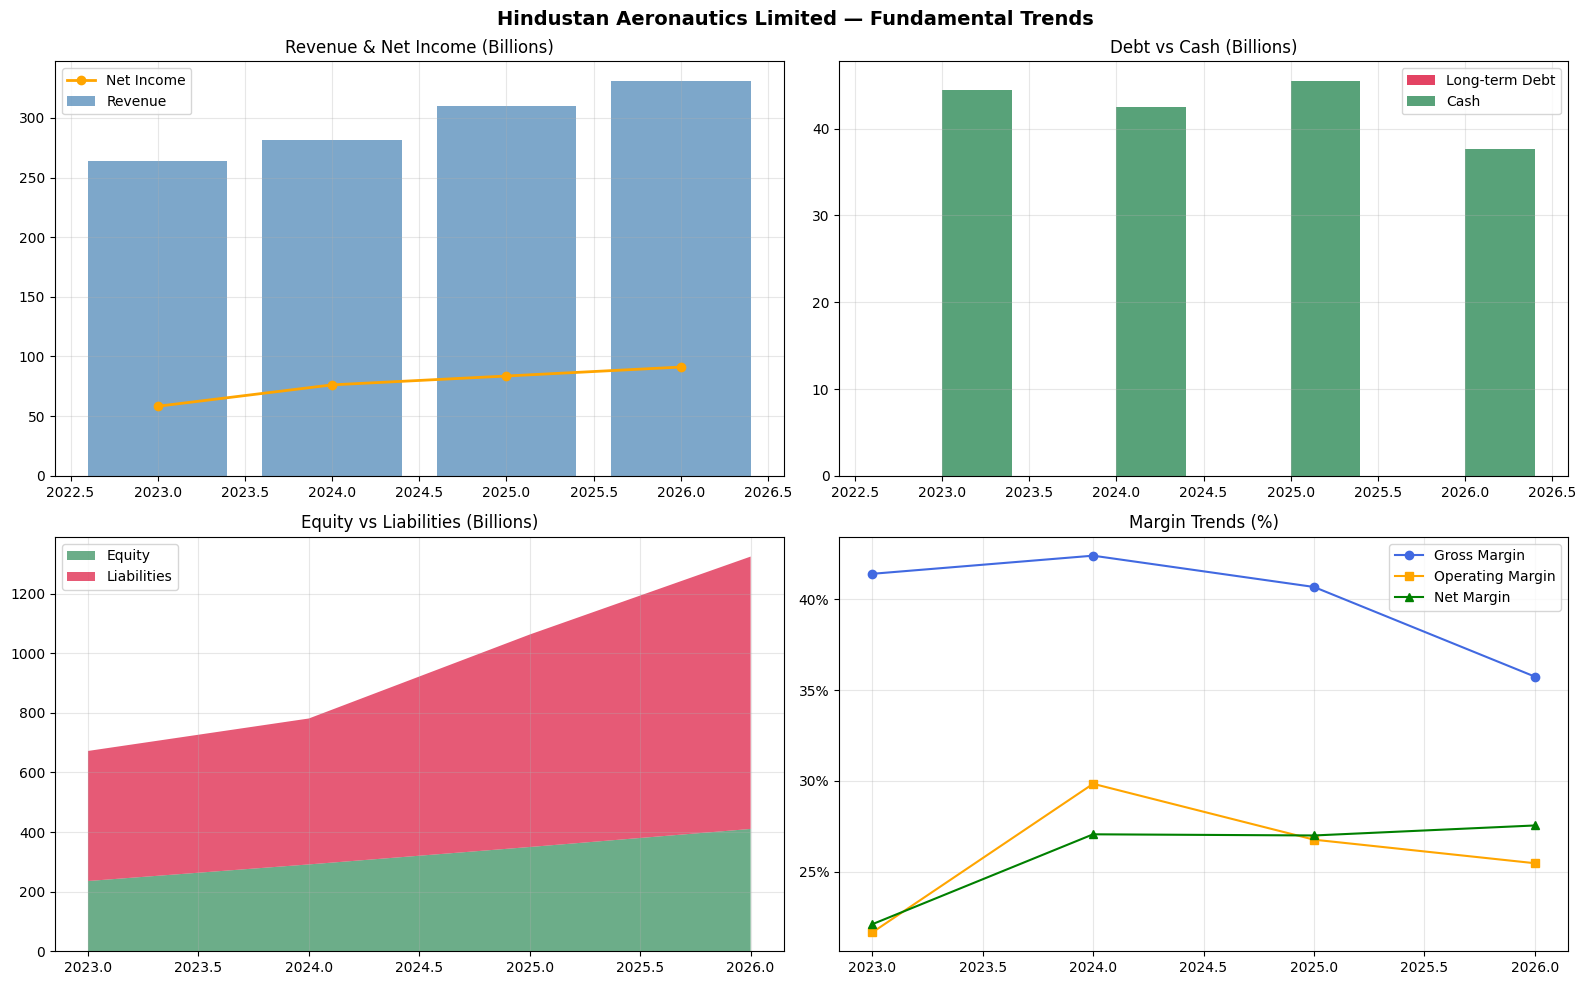

In [139]:
# ── Fundamental Visualizations ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"{company_name} — Fundamental Trends", fontsize=14, fontweight='bold')

# 1. Revenue & Net Income
try:
    ax = axes[0, 0]
    rev_s = financials.loc['Total Revenue'] / 1e9
    ni_s  = financials.loc['Net Income']    / 1e9
    ax.bar(rev_s.index.year, rev_s.values, label='Revenue', alpha=0.7, color='steelblue')
    ax.plot(rev_s.index.year, ni_s.values, 'o-', label='Net Income', color='orange', linewidth=2)
    ax.set_title("Revenue & Net Income (Billions)")
    ax.legend()
    ax.grid(True, alpha=0.3)
except Exception as e:
    axes[0, 0].text(0.5, 0.5, f"N/A: {e}", ha='center', va='center', transform=axes[0, 0].transAxes)

# 2. Debt vs Cash
try:
    ax = axes[0, 1]
    debt_s = balance_sheet.loc['Long Term Debt']       / 1e9
    cash_s = balance_sheet.loc['Cash And Cash Equivalents'] / 1e9
    ax.bar(debt_s.index.year - 0.2, debt_s.values, 0.4, label='Long-term Debt', color='crimson', alpha=0.8)
    ax.bar(cash_s.index.year + 0.2, cash_s.values, 0.4, label='Cash', color='seagreen', alpha=0.8)
    ax.set_title("Debt vs Cash (Billions)")
    ax.legend()
    ax.grid(True, alpha=0.3)
except Exception as e:
    axes[0, 1].text(0.5, 0.5, f"N/A: {e}", ha='center', va='center', transform=axes[0, 1].transAxes)

# 3. Equity vs Liabilities
try:
    ax = axes[1, 0]
    eq = bal['Stockholders Equity']                          / 1e9
    lb = bal['Total Liabilities Net Minority Interest']      / 1e9
    ax.stackplot(eq.index.year, [eq.values, lb.values],
                 labels=['Equity','Liabilities'], alpha=0.7, colors=['seagreen','crimson'])
    ax.set_title("Equity vs Liabilities (Billions)")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
except Exception as e:
    axes[1, 0].text(0.5, 0.5, f"N/A: {e}", ha='center', va='center', transform=axes[1, 0].transAxes)

# 4. Gross / Operating / Net Margin
try:
    ax = axes[1, 1]
    gm = (financials.loc['Gross Profit']      / financials.loc['Total Revenue']) * 100
    om = (financials.loc['Operating Income']  / financials.loc['Total Revenue']) * 100
    nm = (financials.loc['Net Income']        / financials.loc['Total Revenue']) * 100
    ax.plot(gm.index.year, gm.values, 'o-', label='Gross Margin', color='royalblue')
    ax.plot(om.index.year, om.values, 's-', label='Operating Margin', color='orange')
    ax.plot(nm.index.year, nm.values, '^-', label='Net Margin', color='green')
    ax.set_title("Margin Trends (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
except Exception as e:
    axes[1, 1].text(0.5, 0.5, f"N/A: {e}", ha='center', va='center', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()

## 3.5 — DCF (Discounted Cash Flow) Valuation
> 2-Stage DCF using Free Cash Flow.  
> Stage 1: high-growth phase (years 1–5) → Stage 2: fade phase (years 6–10) → Terminal Value (Gordon Growth).  
> WACC = 12% (India large/mid-cap benchmark).


  ℹ  FCF derived from CF statement (FY2026): ₹8357.2 Cr
════════════════════════════════════════════════════════════
  2-STAGE DCF VALUATION
════════════════════════════════════════════════════════════
  Base FCF          : ₹8357.23 Cr
  Stage 1 growth    : 3.0%  (years 1-5)
  Stage 2 growth    : 1.5%  (years 6-10)
  Terminal growth   : 6.0%
  WACC              : 12.0%

   Year      FCF (Cr)       PV (Cr)  Phase
  ─────  ────────────  ────────────  ────────
      1      8607.95      7685.67  Stage 1
      2      8866.19      7068.07  Stage 1
      3      9132.17      6500.10  Stage 1
      4      9406.14      5977.77  Stage 1
      5      9688.32      5497.41  Stage 1
      6      9833.64      4982.03  Stage 2
      7      9981.15      4514.97  Stage 2
      8     10130.87      4091.69  Stage 2
      9     10282.83      3708.09  Stage 2
     10     10437.07      3360.46  Stage 2

  Terminal Value PV : ₹59368.09 Cr  (52.7% of EV)
  Enterprise Value  : ₹112754.34 Cr
  Net Debt          :

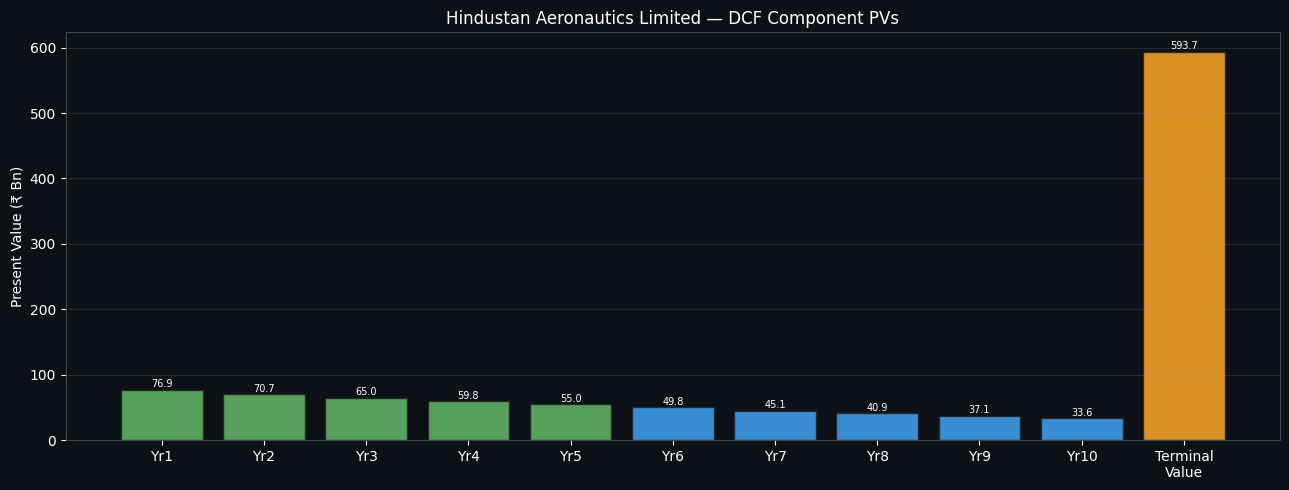

In [138]:
# ── 2-Stage DCF Valuation ────────────────────────────────────────────────────
# Inputs from yfinance fundamentals
def _dcf_get(key, fallback=None):
    v = info.get(key, fallback) or fallback
    try:
        return float(v) if v is not None else None
    except (TypeError, ValueError):
        return None

# ── FCF lookup: 4-level cascade ───────────────────────────────────────────────
# 1. yfinance info dict (TTM)
fcf_raw = _dcf_get('freeCashflow')

# 2. info dict: OCF - CapEx
if fcf_raw is None or fcf_raw <= 0:
    ocf = _dcf_get('operatingCashflow')
    cap = _dcf_get('capitalExpenditures')
    if ocf and cap:
        fcf_raw = ocf - abs(cap)

# 3. Cash flow statement DataFrame (cf)
# yfinance returns cf as TRANSPOSED: index=dates, columns=metric names
if fcf_raw is None or fcf_raw <= 0:
    try:
        _fcf_note = ""
        # Detect orientation: if index[0] is a Timestamp → transposed (dates as rows)
        _cf_transposed = len(cf.index) > 0 and isinstance(cf.index[0], pd.Timestamp)
        if _cf_transposed:
            _cf_cols_lower = {str(c).lower(): c for c in cf.columns}
            # Try direct FCF column
            for _k in ['free cash flow', 'freecashflow']:
                if _k in _cf_cols_lower:
                    _v = cf[_cf_cols_lower[_k]].iloc[0]
                    if pd.notna(_v) and float(_v) > 0:
                        fcf_raw   = float(_v)
                        _fcf_note = f"CF statement (FY{cf.index[0].year})"
                        break
            # Try OCF - CapEx
            if fcf_raw is None or fcf_raw <= 0:
                _ocf_v = _cap_v = None
                for _ok in ['operating cash flow', 'cash from operations']:
                    if _ok in _cf_cols_lower:
                        _ocf_v = float(cf[_cf_cols_lower[_ok]].iloc[0])
                        break
                for _ck in ['capital expenditure', 'capital expenditures']:
                    if _ck in _cf_cols_lower:
                        _cap_v = float(cf[_cf_cols_lower[_ck]].iloc[0])
                        break
                if _ocf_v and _cap_v:
                    fcf_raw   = _ocf_v - abs(_cap_v)
                    _fcf_note = "CF stmt OCF - CapEx"
        else:
            # Raw orientation: index=metric names, columns=dates
            _cf_idx_lower = {str(k).lower(): k for k in cf.index}
            for _k in ['free cash flow', 'freecashflow']:
                if _k in _cf_idx_lower:
                    _v = float(cf.loc[_cf_idx_lower[_k]].iloc[0])
                    if not np.isnan(_v) and _v > 0:
                        fcf_raw   = _v
                        _fcf_note = "CF statement"
                        break
        if fcf_raw and fcf_raw > 0 and _fcf_note:
            print(f"  ℹ  FCF derived from {_fcf_note}: {CURRENCY_SYM}{fcf_raw/1e7:.1f} Cr")
    except Exception:
        pass

# 4. Final fallback: Net Income
if fcf_raw is None or fcf_raw <= 0:
    fcf_raw = _dcf_get('netIncomeToCommon') or 1e9
    print("  ⚠  FCF unavailable from all sources — using Net Income as proxy")
    print("     (yfinance may not report FCF for Indian NSE/BSE stocks)")

shares_out     = _dcf_get('sharesOutstanding') or _dcf_get('impliedSharesOutstanding') or 1e8
current_price  = float(close.iloc[-1])
mkt_cap        = _dcf_get('marketCap') or (current_price * shares_out)

# Growth assumptions
rev_growth   = _dcf_get('revenueGrowth') or 0.12
stage1_g     = min(max(rev_growth, 0.03), 0.25)
stage2_g     = stage1_g * 0.5
terminal_g   = 0.06
WACC         = 0.12

print("═" * 60)
print("  2-STAGE DCF VALUATION")
print("═" * 60)
print(f"  Base FCF          : {CURRENCY_SYM}{fcf_raw/1e7:.2f} Cr")
print(f"  Stage 1 growth    : {stage1_g:.1%}  (years 1-5)")
print(f"  Stage 2 growth    : {stage2_g:.1%}  (years 6-10)")
print(f"  Terminal growth   : {terminal_g:.1%}")
print(f"  WACC              : {WACC:.1%}")
print()

# ── Project FCFs ─────────────────────────────────────────────────────────────
pv_fcfs   = []
fcf_t     = fcf_raw
for yr in range(1, 11):
    g     = stage1_g if yr <= 5 else stage2_g
    fcf_t = fcf_t * (1 + g)
    pv    = fcf_t / (1 + WACC) ** yr
    pv_fcfs.append({'Year': yr, 'FCF': fcf_t, 'PV': pv, 'Phase': 'Stage 1' if yr <= 5 else 'Stage 2'})

fcf_df   = pd.DataFrame(pv_fcfs)

# Terminal Value (Gordon Growth Model) at end of Year 10
tv_fcf10 = fcf_df.iloc[-1]['FCF']
tv       = tv_fcf10 * (1 + terminal_g) / (WACC - terminal_g)
pv_tv    = tv / (1 + WACC) ** 10

enterprise_value = fcf_df['PV'].sum() + pv_tv
net_debt         = (_dcf_get('totalDebt') or 0) - (_dcf_get('totalCash') or _dcf_get('cash') or 0)
equity_value     = enterprise_value - net_debt
intrinsic_price  = equity_value / shares_out

mos_pct          = (intrinsic_price - current_price) / current_price
if mos_pct >  0.20:
    verdict = '✅  UNDERVALUED   — Margin of Safety > 20%'
elif mos_pct > -0.15:
    verdict = '🟡  FAIRLY VALUED  — Within ±15% of fair value'
else:
    verdict = '🔴  OVERVALUED    — Premium > 15% above intrinsic'

print(f"  {'Year':>5}  {'FCF (Cr)':>12}  {'PV (Cr)':>12}  Phase")
print(f"  {'─'*5}  {'─'*12}  {'─'*12}  {'─'*8}")
for _, row in fcf_df.iterrows():
    print(f"  {int(row['Year']):>5}  {row['FCF']/1e7:>11.2f}  {row['PV']/1e7:>11.2f}  {row['Phase']}")
print()
print(f"  Terminal Value PV : {CURRENCY_SYM}{pv_tv/1e7:.2f} Cr  ({pv_tv/enterprise_value:.1%} of EV)")
print(f"  Enterprise Value  : {CURRENCY_SYM}{enterprise_value/1e7:.2f} Cr")
print(f"  Net Debt          : {CURRENCY_SYM}{net_debt/1e7:.2f} Cr")
print(f"  Equity Value      : {CURRENCY_SYM}{equity_value/1e7:.2f} Cr")
print()
print(f"  Intrinsic Price   : {CURRENCY_SYM}{intrinsic_price:.2f}")
print(f"  Market Price      : {CURRENCY_SYM}{current_price:.2f}")
print(f"  Margin of Safety  : {mos_pct:+.1%}")
print(f"\n  {verdict}")
print("═" * 60)
print("  ⚠  DCF is highly sensitive to WACC & growth assumptions.")
print("     Cross-check with EV/EBITDA and P/E relative valuation.")

# ── Waterfall chart ───────────────────────────────────────────────────────────
_dcf_labels = [f"Yr{int(r['Year'])}" for _, r in fcf_df.iterrows()] + ['Terminal\nValue']
_dcf_values = list(fcf_df['PV'].values) + [pv_tv]
_dcf_colors = ['#66bb6a'] * 5 + ['#42a5f5'] * 5 + ['#ffa726']

fig_dcf, ax_dcf = plt.subplots(figsize=(13, 5))
fig_dcf.patch.set_facecolor('#0d1117')
ax_dcf.set_facecolor('#0d1117')
bars = ax_dcf.bar(_dcf_labels, [v / 1e9 for v in _dcf_values], color=_dcf_colors, edgecolor='#222', alpha=0.85)
ax_dcf.axhline(0, color='white', linewidth=0.5, alpha=0.4)
ax_dcf.set_title(f"{company_name} — DCF Component PVs", color='white', fontsize=12)
ax_dcf.set_ylabel("Present Value (₹ Bn)", color='white')
ax_dcf.tick_params(colors='white')
for sp in ax_dcf.spines.values(): sp.set_color('#444')
ax_dcf.grid(True, alpha=0.15, axis='y')
for bar, val in zip(bars, _dcf_values):
    ax_dcf.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val/1e9:.1f}", ha='center', va='bottom', color='white', fontsize=7)
plt.tight_layout()
plt.show()


## 3.3 — Altman Z-Score (Bankruptcy Risk)
> **Z > 2.99** → Safe zone | **1.81–2.99** → Grey zone | **Z < 1.81** → Distress zone

In [140]:
def compute_altman_zscore(bal_t, fin_t, info_dict):
    """
    Altman Z-Score for manufacturing/public companies:
    Z = 1.2*X1 + 1.4*X2 + 3.3*X3 + 0.6*X4 + 1.0*X5
    Uses most-recent available fiscal year (iloc[0] after balance_sheet.T).
    """
    def _first_valid(df):
        """Return the most recent row that has at least 3 non-NaN values."""
        for i in range(len(df)):
            if df.iloc[i].notna().sum() >= 3:
                return df.iloc[i]
        return df.iloc[0]

    try:
        b = _first_valid(bal_t)
        f = _first_valid(fin_t)

        dte_b = b.name.date() if hasattr(b.name, 'date') else str(b.name)[:10]
        dte_f = f.name.date() if hasattr(f.name, 'date') else str(f.name)[:10]
        print(f"  Using balance sheet : {dte_b}")
        print(f"  Using income stmt   : {dte_f}")

        ta_col = next((c for c in ['Total Assets']
                       if c in b.index and pd.notna(b[c])), None)
        cl_col = next((c for c in ['Current Liabilities', 'Total Current Liabilities']
                       if c in b.index and pd.notna(b[c])), None)

        # Working capital — prefer pre-computed field, fall back to CA - CL
        if 'Working Capital' in b.index and pd.notna(b['Working Capital']):
            wc = b['Working Capital']
        else:
            ca_col = next((c for c in ['Current Assets', 'Total Current Assets']
                           if c in b.index and pd.notna(b[c])), None)
            wc = (b[ca_col] - b[cl_col]) if (ca_col and cl_col) else np.nan

        # Retained earnings — PSUs may not report separately; fall back to equity proxy
        re_col = next((c for c in ['Retained Earnings', 'Retained Earnings Deficit',
                                   'Retained Earnings And Surplus']
                       if c in b.index and pd.notna(b[c])), None)
        if re_col:
            re = b[re_col]
        else:
            eq_col = next((c for c in ['Stockholders Equity', 'Common Stock Equity']
                           if c in b.index and pd.notna(b[c])), None)
            cs_col = next((c for c in ['Capital Stock', 'Common Stock',
                                       'Additional Paid In Capital']
                           if c in b.index and pd.notna(b[c])), None)
            if eq_col and cs_col:
                re = b[eq_col] - b[cs_col]
                print("  ⚠  Retained Earnings not reported; estimated as Equity − Capital Stock")
            elif eq_col:
                re = b[eq_col] * 0.7
                print("  ⚠  Retained Earnings estimated as 70% of Stockholders Equity (fallback)")
            else:
                re = np.nan

        tl_col = next((c for c in ['Total Liabilities Net Minority Interest', 'Total Liabilities']
                       if c in b.index and pd.notna(b[c])), None)
        eb_col = next((c for c in ['EBIT', 'Ebit', 'Operating Income']
                       if c in f.index and pd.notna(f[c])), None)
        rv_col = next((c for c in ['Total Revenue', 'Revenue', 'Operating Revenue']
                       if c in f.index and pd.notna(f[c])), None)

        ta = b[ta_col] if ta_col else np.nan
        eb = f[eb_col] if eb_col else np.nan
        tl = b[tl_col] if tl_col else np.nan
        rv = f[rv_col] if rv_col else np.nan
        mc = info_dict.get('marketCap', np.nan)

        X1 = wc / ta
        X2 = re  / ta
        X3 = eb  / ta
        X4 = mc  / tl
        X5 = rv  / ta

        z = 1.2*X1 + 1.4*X2 + 3.3*X3 + 0.6*X4 + 1.0*X5

        print(f"\n  X1 (Working Capital / Total Assets)      = {X1:.4f}")
        print(f"  X2 (Retained Earnings / Total Assets)    = {X2:.4f}")
        print(f"  X3 (EBIT / Total Assets)                 = {X3:.4f}")
        print(f"  X4 (Market Cap / Total Liabilities)      = {X4:.4f}")
        print(f"  X5 (Revenue / Total Assets)              = {X5:.4f}")
        print(f"\n  \u2605 Altman Z-Score: {z:.2f}")
        if z > 2.99:
            print("  \u2192 SAFE ZONE (low bankruptcy risk)")
        elif z > 1.81:
            print("  \u2192 GREY ZONE (moderate caution)")
        else:
            print("  \u2192 DISTRESS ZONE (high bankruptcy risk)")
        return z
    except Exception as e:
        print(f"  Z-Score error: {e}")
        import traceback; traceback.print_exc()
        return np.nan

altman_z = compute_altman_zscore(bal, fin, info)


  Using balance sheet : 2026-03-31
  Using income stmt   : 2026-03-31
  ⚠  Retained Earnings not reported; estimated as Equity − Capital Stock

  X1 (Working Capital / Total Assets)      = 0.5402
  X2 (Retained Earnings / Total Assets)    = 0.3074
  X3 (EBIT / Total Assets)                 = 0.0918
  X4 (Market Cap / Total Liabilities)      = 3.1501
  X5 (Revenue / Total Assets)              = 0.2499

  ★ Altman Z-Score: 3.52
  → SAFE ZONE (low bankruptcy risk)


## 3.4 — Piotroski F-Score (Financial Strength 0–9)
> **8–9** → Very strong | **5–7** → Moderate | **0–4** → Weak

In [141]:
def compute_piotroski(bal_t, fin_t, cf_t):
    """Compute Piotroski F-Score (0-9).
    iloc[0] = most recent year, iloc[1] = prior year (after balance_sheet.T).
    """
    def ps(val):
        """Score 1 if val is True, 0 otherwise; NaN-safe."""
        return 1 if (pd.notna(val) and val) else 0

    sv = lambda d, col: d[col] if col in d.index and pd.notna(d[col]) else np.nan

    scores = {}

    try:
        # Most-recent year = iloc[0]; prior year = iloc[1]
        bl = bal_t.iloc[0]
        bp = bal_t.iloc[1] if len(bal_t) > 1 else bal_t.iloc[0]
        fl = fin_t.iloc[0]
        fp = fin_t.iloc[1] if len(fin_t) > 1 else fin_t.iloc[0]
        cl = cf_t.iloc[0]  if not cf_t.empty else pd.Series(dtype=float)

        dte = bl.name.date() if hasattr(bl.name, 'date') else str(bl.name)[:10]
        print(f"  Current fiscal year : {dte}")

        # ── Profitability ────────────────────────────────────────────────────
        ni  = sv(fl, 'Net Income')
        scores['F1_Positive_ROA']    = ps(ni > 0)

        ocf_col = next((c for c in ['Operating Cash Flow',
                                     'Cash Flow From Continuing Operating Activities',
                                     'Net Income From Continuing Operations']
                        if c in cl.index and pd.notna(cl[c])), None)
        ocf = cl[ocf_col] if ocf_col else np.nan
        scores['F2_Positive_OCF']    = ps(ocf > 0)

        ta_l = sv(bl, 'Total Assets');  ta_p = sv(bp, 'Total Assets')
        roa_l = sv(fl, 'Net Income') / ta_l  if pd.notna(ta_l) and ta_l else np.nan
        roa_p = sv(fp, 'Net Income') / ta_p  if pd.notna(ta_p) and ta_p else np.nan
        scores['F3_ROA_Increase']    = ps(pd.notna(roa_l) and pd.notna(roa_p) and roa_l > roa_p)
        scores['F4_Accruals_OCF>NI'] = ps(pd.notna(ocf) and pd.notna(ni) and ocf > ni)

        # ── Leverage / Liquidity ─────────────────────────────────────────────
        ltd_l = sv(bl, 'Long Term Debt');  ltd_p = sv(bp, 'Long Term Debt')
        scores['F5_Lower_Leverage']  = ps(pd.notna(ltd_l) and pd.notna(ltd_p) and ltd_l < ltd_p)

        ca_l   = sv(bl, 'Current Assets');    cl_v_l = sv(bl, 'Current Liabilities')
        ca_p   = sv(bp, 'Current Assets');    cl_v_p = sv(bp, 'Current Liabilities')
        curr_l = (ca_l / cl_v_l) if (pd.notna(ca_l) and pd.notna(cl_v_l) and cl_v_l) else np.nan
        curr_p = (ca_p / cl_v_p) if (pd.notna(ca_p) and pd.notna(cl_v_p) and cl_v_p) else np.nan
        scores['F6_Higher_Liquidity'] = ps(pd.notna(curr_l) and pd.notna(curr_p) and curr_l > curr_p)

        shn_l = sv(bl, 'Ordinary Shares Number')
        shn_p = sv(bp, 'Ordinary Shares Number')
        scores['F7_No_Dilution']     = ps(pd.notna(shn_l) and pd.notna(shn_p) and shn_l <= shn_p)

        # ── Operating efficiency ─────────────────────────────────────────────
        rv_l = sv(fl, 'Total Revenue');  rv_p = sv(fp, 'Total Revenue')
        gm_l = (sv(fl, 'Gross Profit') / rv_l) if (pd.notna(rv_l) and rv_l) else np.nan
        gm_p = (sv(fp, 'Gross Profit') / rv_p) if (pd.notna(rv_p) and rv_p) else np.nan
        scores['F8_Gross_Margin_Up'] = ps(pd.notna(gm_l) and pd.notna(gm_p) and gm_l > gm_p)

        at_l = (rv_l / ta_l) if (pd.notna(rv_l) and pd.notna(ta_l) and ta_l) else np.nan
        at_p = (rv_p / ta_p) if (pd.notna(rv_p) and pd.notna(ta_p) and ta_p) else np.nan
        scores['F9_Asset_Turnover_Up'] = ps(pd.notna(at_l) and pd.notna(at_p) and at_l > at_p)

        f_total = sum(v for v in scores.values() if pd.notna(v))

        print(f"\n  {'Criterion':<35} {'Score'}")
        print("  " + "-"*45)
        labels = {
            'F1_Positive_ROA'      : 'Positive Net Income (ROA)',
            'F2_Positive_OCF'      : 'Positive Operating Cash Flow',
            'F3_ROA_Increase'      : 'Increasing ROA',
            'F4_Accruals_OCF>NI'   : 'OCF > Net Income (Accruals)',
            'F5_Lower_Leverage'    : 'Lower Long-Term Debt',
            'F6_Higher_Liquidity'  : 'Improving Current Ratio',
            'F7_No_Dilution'       : 'No Share Dilution',
            'F8_Gross_Margin_Up'   : 'Increasing Gross Margin',
            'F9_Asset_Turnover_Up' : 'Improving Asset Turnover',
        }
        for k, v in scores.items():
            icon = "\u2705" if v == 1 else ("\u274c" if v == 0 else "\u26a0\ufe0f")
            print(f"  {icon}  {labels.get(k, k):<33} {v}")

        print(f"\n  \u2605 Piotroski F-Score: {f_total}/9")
        if f_total >= 8:
            print("  \u2192 STRONG financial position")
        elif f_total >= 5:
            print("  \u2192 MODERATE financial position")
        else:
            print("  \u2192 WEAK financial position \u2014 caution advised")

        return f_total, scores

    except Exception as e:
        print(f"  Piotroski error: {e}")
        import traceback; traceback.print_exc()
        return 0, {}

piotroski_score, piotroski_detail = compute_piotroski(bal, fin, cf)


  Current fiscal year : 2026-03-31

  Criterion                           Score
  ---------------------------------------------
  ✅  Positive Net Income (ROA)         1
  ✅  Positive Operating Cash Flow      1
  ❌  Increasing ROA                    0
  ✅  OCF > Net Income (Accruals)       1
  ❌  Lower Long-Term Debt              0
  ✅  Improving Current Ratio           1
  ✅  No Share Dilution                 1
  ❌  Increasing Gross Margin           0
  ❌  Improving Asset Turnover          0

  ★ Piotroski F-Score: 5/9
  → MODERATE financial position


# Section 4 — Technical Analysis
## 4.1 — Compute 18+ Indicators

In [142]:
# Work on a clean copy of 'data' (plain column names already ensured above)
df = data.copy()

close  = df['Close']
high   = df['High']
low    = df['Low']
volume = df['Volume']
open_  = df['Open']

# ── Trend indicators ─────────────────────────────────────────────────────────
df['SMA_20']  = ta.trend.sma_indicator(close, window=20)
df['SMA_50']  = ta.trend.sma_indicator(close, window=50)
df['SMA_200'] = ta.trend.sma_indicator(close, window=200)
df['EMA_20']  = ta.trend.ema_indicator(close, window=20)
df['EMA_50']  = ta.trend.ema_indicator(close, window=50)

macd_obj       = ta.trend.MACD(close, window_slow=26, window_fast=12, window_sign=9)
df['MACD']     = macd_obj.macd()
df['MACD_Sig'] = macd_obj.macd_signal()
df['MACD_Hist']= macd_obj.macd_diff()

adx_obj        = ta.trend.ADXIndicator(high, low, close, window=14)
df['ADX']      = adx_obj.adx()
df['DI_Plus']  = adx_obj.adx_pos()
df['DI_Minus'] = adx_obj.adx_neg()

df['AROON_Up'] = ta.trend.aroon_up(high, low, window=25)
df['AROON_Dn'] = ta.trend.aroon_down(high, low, window=25)

# ── Momentum indicators ──────────────────────────────────────────────────────
df['RSI']      = ta.momentum.RSIIndicator(close, window=14).rsi()

stoch_obj      = ta.momentum.StochasticOscillator(high, low, close, window=14, smooth_window=3)
df['STOCH_K']  = stoch_obj.stoch()
df['STOCH_D']  = stoch_obj.stoch_signal()

df['WILLR']    = ta.momentum.WilliamsRIndicator(high, low, close, lbp=14).williams_r()
df['ROC']      = ta.momentum.ROCIndicator(close, window=12).roc()
df['MFI']      = ta.volume.MFIIndicator(high, low, close, volume, window=14).money_flow_index()

# ── Volatility indicators ─────────────────────────────────────────────────────
bb_obj         = ta.volatility.BollingerBands(close, window=20, window_dev=2)
df['BB_Upper'] = bb_obj.bollinger_hband()
df['BB_Mid']   = bb_obj.bollinger_mavg()
df['BB_Lower'] = bb_obj.bollinger_lband()
df['BB_Width'] = bb_obj.bollinger_wband()
df['BB_Pct']   = bb_obj.bollinger_pband()

df['ATR']      = ta.volatility.AverageTrueRange(high, low, close, window=14).average_true_range()

kc_obj         = ta.volatility.KeltnerChannel(high, low, close, window=20)
df['KC_Upper'] = kc_obj.keltner_channel_hband()
df['KC_Lower'] = kc_obj.keltner_channel_lband()
df['KC_Mid']   = kc_obj.keltner_channel_mband()

# Ulcer Index (manual — rolling drawdown RMS)
rolling_max    = close.rolling(14, min_periods=1).max()
drawdown_pct   = ((close - rolling_max) / rolling_max) * 100
df['Ulcer']    = drawdown_pct.pow(2).rolling(14, min_periods=1).mean().pow(0.5)

# ── Volume indicators ─────────────────────────────────────────────────────────
df['OBV']      = ta.volume.OnBalanceVolumeIndicator(close, volume).on_balance_volume()
df['VWAP']     = (close * volume).cumsum() / volume.cumsum()   # session VWAP approximation
df['CMF']      = ta.volume.ChaikinMoneyFlowIndicator(high, low, close, volume, window=20).chaikin_money_flow()

# ── Buy/Sell signals ──────────────────────────────────────────────────────────
df['Signal_RSI']   = 0
df.loc[df['RSI'] < 30, 'Signal_RSI']  =  1   # Oversold → Buy
df.loc[df['RSI'] > 70, 'Signal_RSI']  = -1   # Overbought → Sell

df['Signal_MACD']  = 0
bull_cross = (df['MACD'] > df['MACD_Sig']) & (df['MACD'].shift(1) <= df['MACD_Sig'].shift(1))
bear_cross = (df['MACD'] < df['MACD_Sig']) & (df['MACD'].shift(1) >= df['MACD_Sig'].shift(1))
df.loc[bull_cross, 'Signal_MACD'] =  1
df.loc[bear_cross, 'Signal_MACD'] = -1

df['Signal_MA']    = 0
df.loc[df['EMA_20'] > df['EMA_50'], 'Signal_MA']  =  1   # Golden Cross
df.loc[df['EMA_20'] < df['EMA_50'], 'Signal_MA']  = -1   # Death Cross

print("✅ Technical indicators computed:")
indicator_cols = [c for c in df.columns if c not in list(data.columns)]
print(f"   {len(indicator_cols)} new columns: {', '.join(indicator_cols)}")
display(df[['Close','RSI','MACD','ATR','BB_Pct','MFI','ADX','OBV']].tail(5))

✅ Technical indicators computed:
   35 new columns: SMA_20, SMA_50, SMA_200, EMA_20, EMA_50, MACD, MACD_Sig, MACD_Hist, ADX, DI_Plus, DI_Minus, AROON_Up, AROON_Dn, RSI, STOCH_K, STOCH_D, WILLR, ROC, MFI, BB_Upper, BB_Mid, BB_Lower, BB_Width, BB_Pct, ATR, KC_Upper, KC_Lower, KC_Mid, Ulcer, OBV, VWAP, CMF, Signal_RSI, Signal_MACD, Signal_MA


,Close,RSI,MACD,ATR,BB_Pct,MFI,ADX,OBV
Date,,,,,,,,
2026-05-25,4425.899902,52.365818,37.705315,124.671726,0.399194,56.622639,21.968469,57914127
2026-05-26,4427.700195,52.478949,34.528883,119.738003,0.393416,56.956222,20.454066,58897807
2026-05-27,4413.000000,51.405361,30.474070,116.170989,0.363711,53.790970,19.155465,58395412
2026-05-28,4413.000000,51.405361,26.949939,107.873061,0.355094,49.348975,17.949621,58395412
2026-05-29,4303.799805,43.702853,15.170619,111.789285,0.185440,42.221303,17.839190,53798013


## 4.2 — Interactive Candlestick + Indicators (Plotly)

In [143]:
recent = df[df.index >= df.index[-1] - pd.DateOffset(years=1)] if len(df) > 252 else df

fig = make_subplots(
    rows=4, cols=1, shared_xaxes=True,
    row_heights=[0.50, 0.17, 0.17, 0.16],
    subplot_titles=[
        f"{TICKER} — Price, EMAs, Bollinger Bands",
        "MACD", "RSI (14)", "Volume + MFI"
    ],
    vertical_spacing=0.04
)

# ── Row 1: Candlestick + EMAs + Bollinger ────────────────────────────────────
fig.add_trace(go.Candlestick(
    x=recent.index, open=recent['Open'], high=recent['High'],
    low=recent['Low'], close=recent['Close'], name='OHLC',
    increasing_line_color='#26a69a', decreasing_line_color='#ef5350'
), row=1, col=1)

for col, color, dash, name in [
    ('EMA_20','royalblue','solid','EMA 20'),
    ('EMA_50','orange','solid','EMA 50'),
    ('SMA_200','gray','dot','SMA 200'),
    ('BB_Upper','rgba(100,100,255,0.5)','dash','BB Upper'),
    ('BB_Lower','rgba(100,100,255,0.5)','dash','BB Lower'),
]:
    if col in recent.columns:
        fig.add_trace(go.Scatter(x=recent.index, y=recent[col],
                                 line=dict(color=color, dash=dash, width=1.2),
                                 name=name), row=1, col=1)

# BB fill
if 'BB_Upper' in recent.columns and 'BB_Lower' in recent.columns:
    fig.add_trace(go.Scatter(
        x=pd.concat([recent.index.to_series(), recent.index.to_series()[::-1]]),
        y=pd.concat([recent['BB_Upper'], recent['BB_Lower'][::-1]]),
        fill='toself', fillcolor='rgba(100,100,255,0.05)',
        line=dict(color='rgba(255,255,255,0)'), showlegend=False, name='BB Band'
    ), row=1, col=1)

# Buy / Sell signals on price chart
buy_sig  = recent[recent['Signal_RSI'] == 1]
sell_sig = recent[recent['Signal_RSI'] == -1]
fig.add_trace(go.Scatter(x=buy_sig.index, y=buy_sig['Low']*0.99,
    mode='markers', marker=dict(symbol='triangle-up', color='green', size=8),
    name='RSI Buy'), row=1, col=1)
fig.add_trace(go.Scatter(x=sell_sig.index, y=sell_sig['High']*1.01,
    mode='markers', marker=dict(symbol='triangle-down', color='red', size=8),
    name='RSI Sell'), row=1, col=1)

# ── Row 2: MACD ──────────────────────────────────────────────────────────────
colors_hist = ['#26a69a' if v >= 0 else '#ef5350' for v in recent['MACD_Hist'].fillna(0)]
fig.add_trace(go.Bar(x=recent.index, y=recent['MACD_Hist'], marker_color=colors_hist,
                     name='MACD Hist', showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=recent.index, y=recent['MACD'],
                         line=dict(color='blue', width=1), name='MACD'), row=2, col=1)
fig.add_trace(go.Scatter(x=recent.index, y=recent['MACD_Sig'],
                         line=dict(color='red', width=1), name='Signal'), row=2, col=1)

# ── Row 3: RSI ───────────────────────────────────────────────────────────────
fig.add_trace(go.Scatter(x=recent.index, y=recent['RSI'],
                         line=dict(color='purple', width=1.5), name='RSI'), row=3, col=1)
fig.add_hline(y=70, line_color='red',   line_dash='dash', row=3, col=1)
fig.add_hline(y=30, line_color='green', line_dash='dash', row=3, col=1)

# ── Row 4: Volume + MFI ──────────────────────────────────────────────────────
vol_colors = ['#26a69a' if c >= o else '#ef5350'
              for c, o in zip(recent['Close'].fillna(0), recent['Open'].fillna(0))]
fig.add_trace(go.Bar(x=recent.index, y=recent['Volume'], marker_color=vol_colors,
                     name='Volume', showlegend=False), row=4, col=1)

fig.update_layout(
    title=dict(text=f"<b>{company_name}</b> — Full Technical Dashboard", font=dict(size=14)),
    height=900,
    template='plotly_dark',
    xaxis_rangeslider_visible=False,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

## 4.3 — Candlestick Pattern Recognition
> 9 classic candlestick patterns detected manually from OHLC data (no TA-Lib dependency).  
> Signals are **directional** (Bullish / Bearish / Neutral) and listed with their most recent occurrence.


═════════════════════════════════════════════════════════════════
  CANDLESTICK PATTERNS — HAL.NS  (last 252 trading days)
═════════════════════════════════════════════════════════════════
  Pattern                 Signal    Count  Last Occurrence
  ──────────────────────  ────────  ─────  ─────────────────
  Doji                    Neutral      25  2026-05-26  —
  Hammer                  Bullish       0  —  ▲
  Shooting Star           Bearish       0  —  ▼
  Bullish Engulfing       Bullish      24  2026-05-26  ▲
  Bearish Engulfing       Bearish      15  2026-05-27  ▼
  Morning Star            Bullish      11  2026-05-04  ▲
  Evening Star            Bearish      12  2026-05-28  ▼
  Piercing Line           Bullish       2  2025-12-15  ▲
  Dark Cloud Cover        Bearish       3  2026-01-23  ▼

  ★ Most recent pattern: Evening Star  (Bearish)  on 2026-05-28
═════════════════════════════════════════════════════════════════


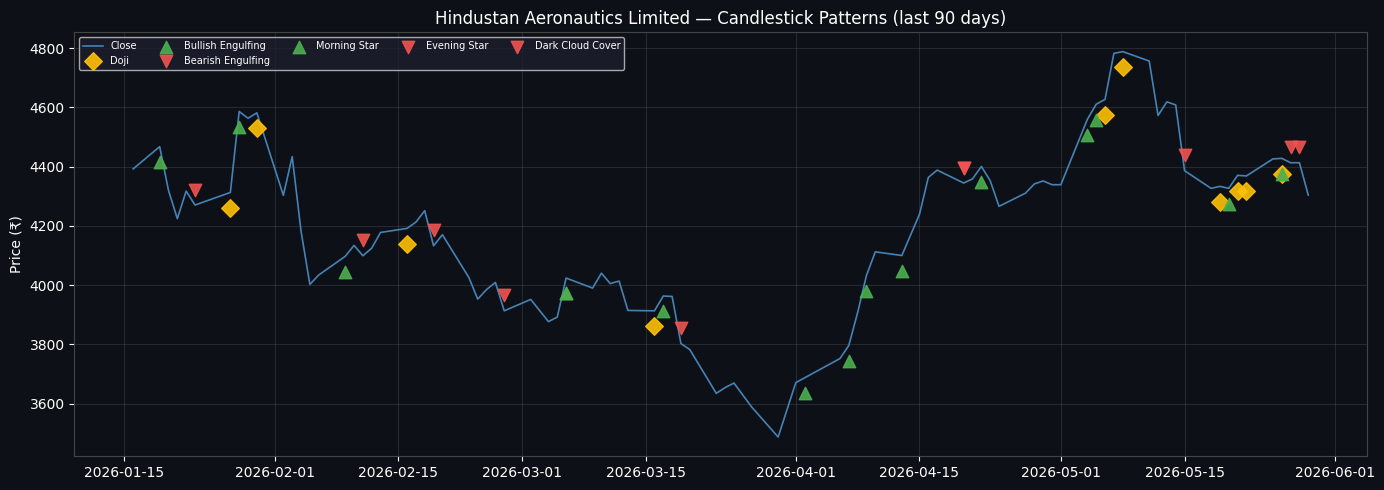

In [144]:
# ── Candlestick Pattern Recognition (manual OHLC — no TA-Lib needed) ─────────
_cs = df[['Open', 'High', 'Low', 'Close']].dropna().tail(252).copy()

_O, _H, _L, _C = _cs['Open'], _cs['High'], _cs['Low'], _cs['Close']
_body  = (_C - _O).abs()                                  # candle body size
_range = _H - _L                                           # total range
_wick_up  = _H - _C.where(_C > _O, _O)                   # upper wick
_wick_dn  = _C.where(_C < _O, _O) - _L                   # lower wick
_is_bull  = _C > _O                                        # bullish candle?

# ── Pattern definitions (vectorised) ─────────────────────────────────────────
# 1. Doji — body is very small vs range (indecision)
_doji = (_body <= 0.1 * _range) & (_range > 0)

# 2. Hammer — small body at top, long lower wick, in downtrend proxy (near 20-SMA from below)
_hammer = (
    (_wick_dn >= 2 * _body)
    & (_wick_up <= 0.3 * _body.clip(lower=1e-6))
    & (_is_bull)
    & (_range > 0)
)

# 3. Shooting Star — small body at bottom, long upper wick (bearish after rally)
_shooting_star = (
    (_wick_up >= 2 * _body)
    & (_wick_dn <= 0.3 * _body.clip(lower=1e-6))
    & (~_is_bull)
    & (_range > 0)
)

# 4. Bullish Engulfing — current bull candle body completely engulfs prior bear candle
_bull_eng = (
    _is_bull
    & (~_is_bull.shift(1).fillna(True))
    & (_O < _C.shift(1).fillna(_O))
    & (_C > _O.shift(1).fillna(_C))
)

# 5. Bearish Engulfing — current bear candle body completely engulfs prior bull candle
_bear_eng = (
    (~_is_bull)
    & (_is_bull.shift(1).fillna(False))
    & (_O > _C.shift(1).fillna(_O))
    & (_C < _O.shift(1).fillna(_C))
)

# 6. Morning Star — 3-bar: bear candle, small middle, bull candle (bullish reversal)
_morning_star = (
    (~_is_bull.shift(2).fillna(True))
    & (_body.shift(1) <= 0.3 * _range.shift(1).clip(lower=1e-6))
    & _is_bull
    & (_body >= 0.5 * _range)
)

# 7. Evening Star — 3-bar: bull candle, small middle, bear candle (bearish reversal)
_evening_star = (
    (_is_bull.shift(2).fillna(False))
    & (_body.shift(1) <= 0.3 * _range.shift(1).clip(lower=1e-6))
    & (~_is_bull)
    & (_body >= 0.5 * _range)
)

# 8. Piercing Line — bearish gap open, then bull candle closes above 50% of prior bear body
_piercing = (
    (~_is_bull.shift(1).fillna(True))
    & _is_bull
    & (_O < _L.shift(1).fillna(_O))    # gapped down
    & (_C > (_O.shift(1).fillna(_C) + _C.shift(1).fillna(_C)) / 2)
    & (_C < _O.shift(1).fillna(_C + 1))
)

# 9. Dark Cloud Cover — bullish gap open, then bear candle closes below 50% of prior bull body
_dark_cloud = (
    (_is_bull.shift(1).fillna(False))
    & (~_is_bull)
    & (_O > _H.shift(1).fillna(_O))    # gapped up
    & (_C < (_O.shift(1).fillna(_C) + _C.shift(1).fillna(_C)) / 2)
    & (_C > _O.shift(1).fillna(_C - 1))
)

patterns = {
    'Doji'               : (_doji,          'Neutral'),
    'Hammer'             : (_hammer,        'Bullish'),
    'Shooting Star'      : (_shooting_star, 'Bearish'),
    'Bullish Engulfing'  : (_bull_eng,      'Bullish'),
    'Bearish Engulfing'  : (_bear_eng,      'Bearish'),
    'Morning Star'       : (_morning_star,  'Bullish'),
    'Evening Star'       : (_evening_star,  'Bearish'),
    'Piercing Line'      : (_piercing,      'Bullish'),
    'Dark Cloud Cover'   : (_dark_cloud,    'Bearish'),
}

print("═" * 65)
print(f"  CANDLESTICK PATTERNS — {TICKER}  (last 252 trading days)")
print("═" * 65)
print(f"  {'Pattern':<22}  {'Signal':<8}  {'Count':>5}  {'Last Occurrence'}")
print(f"  {'─'*22}  {'─'*8}  {'─'*5}  {'─'*17}")

_all_recent = []  # (date, pattern, signal)
for name, (sig, direction) in patterns.items():
    dates = _cs.index[sig.fillna(False)]
    count = len(dates)
    last  = dates[-1].strftime('%Y-%m-%d') if count > 0 else '—'
    icon  = '▲' if direction == 'Bullish' else ('▼' if direction == 'Bearish' else '—')
    print(f"  {name:<22}  {direction:<8}  {count:>5}  {last}  {icon}")
    if count > 0:
        _all_recent.append((dates[-1], name, direction))

if _all_recent:
    _most_recent = sorted(_all_recent, reverse=True)[0]
    print()
    print(f"  ★ Most recent pattern: {_most_recent[1]}  ({_most_recent[2]})  on {_most_recent[0].strftime('%Y-%m-%d')}")

print("═" * 65)

# ── Visual: annotate candlestick chart with pattern markers ──────────────────
_last_90 = _cs.tail(90)
fig_cs, ax_cs = plt.subplots(figsize=(14, 5))
fig_cs.patch.set_facecolor('#0d1117')
ax_cs.set_facecolor('#0d1117')

# Simple OHLC price line
ax_cs.plot(_last_90.index, _last_90['Close'], color='steelblue', linewidth=1.2, label='Close')

# Overlay markers for each pattern in last 90 days
_marker_map = {'Bullish': ('^', '#4caf50'), 'Bearish': ('v', '#ef5350'), 'Neutral': ('D', '#ffc107')}
for name, (sig, direction) in patterns.items():
    _dates_90 = _last_90.index[sig.reindex(_last_90.index).fillna(False)]
    if len(_dates_90) == 0:
        continue
    mk, col = _marker_map[direction]
    y_offset = (_last_90['Close'].max() - _last_90['Close'].min()) * 0.04
    _y_pos = (_last_90.loc[_dates_90, 'Close'] + (y_offset if direction == 'Bearish' else -y_offset))
    ax_cs.scatter(_dates_90, _y_pos, marker=mk, color=col, s=80, zorder=5, alpha=0.9, label=name)

ax_cs.set_title(f"{company_name} — Candlestick Patterns (last 90 days)", color='white', fontsize=12)
ax_cs.set_ylabel(f"Price ({CURRENCY_SYM})", color='white')
ax_cs.tick_params(colors='white')
for sp in ax_cs.spines.values(): sp.set_color('#444')
ax_cs.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=7, ncol=5, loc='upper left')
ax_cs.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()


## 4.3 — Volatility & Risk Metrics

,Value
Metric,
Annualized Volatility,35.49%
Max Drawdown,-44.52%
Sharpe Ratio,-0.018
Sortino Ratio,-0.024
Calmar Ratio,-0.015
1-day VaR (95%),-3.60%
1-day CVaR (95%),-5.17%


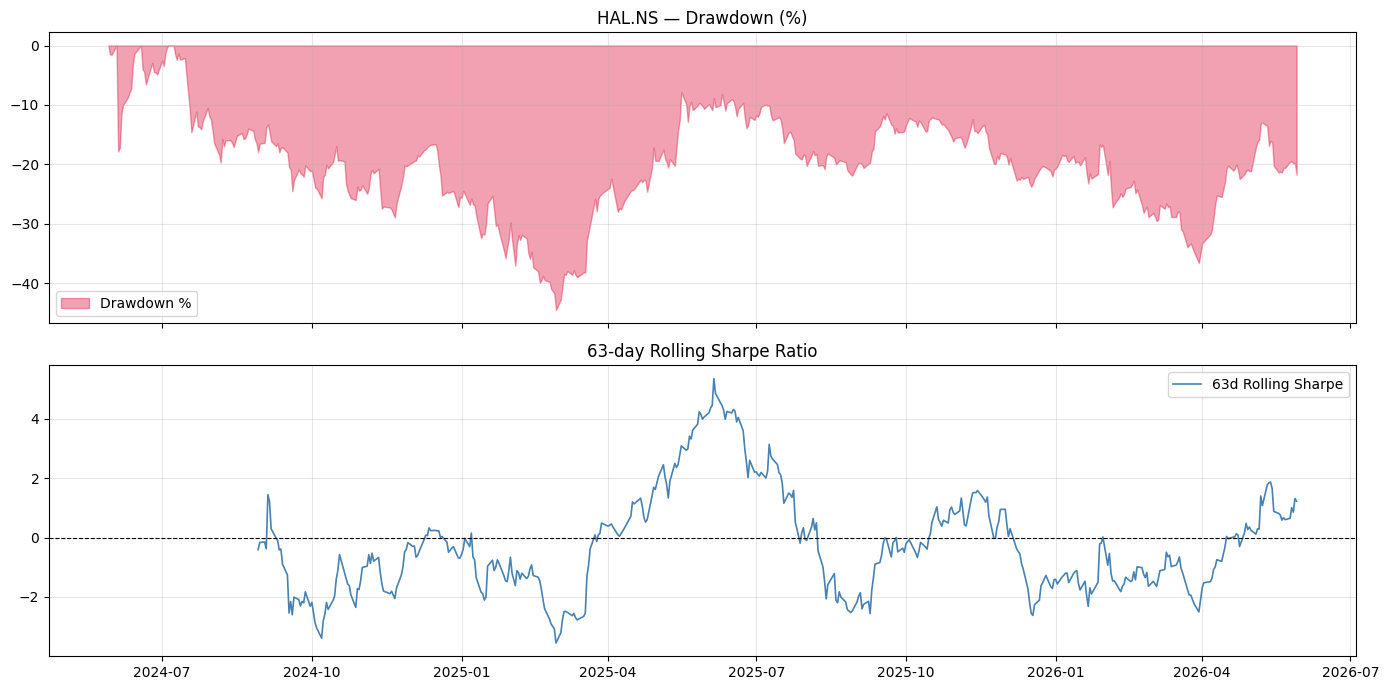

In [145]:
returns = close.pct_change().dropna()

ann_vol      = returns.std() * np.sqrt(252)
max_drawdown = (close / close.cummax() - 1).min()
sharpe       = (returns.mean() / returns.std()) * np.sqrt(252)
sortino_neg  = returns[returns < 0].std()
sortino      = (returns.mean() / sortino_neg) * np.sqrt(252) if sortino_neg else np.nan
calmar       = (returns.mean() * 252) / abs(max_drawdown) if max_drawdown else np.nan
var_95       = np.percentile(returns, 5)   # 1-day 95% VaR
cvar_95      = returns[returns <= var_95].mean()

risk_df = pd.DataFrame({
    "Metric" : ["Annualized Volatility", "Max Drawdown", "Sharpe Ratio",
                "Sortino Ratio", "Calmar Ratio", "1-day VaR (95%)", "1-day CVaR (95%)"],
    "Value"  : [f"{ann_vol:.2%}", f"{max_drawdown:.2%}", f"{sharpe:.3f}",
                f"{sortino:.3f}", f"{calmar:.3f}", f"{var_95:.2%}", f"{cvar_95:.2%}"]
})
display(risk_df.set_index("Metric"))

# Rolling Sharpe (63-day)
roll_mean = returns.rolling(63).mean()
roll_std  = returns.rolling(63).std()
roll_sharpe = (roll_mean / roll_std) * np.sqrt(252)

fig2, axes2 = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes2[0].fill_between(close.index, (close / close.cummax() - 1) * 100,
                       color='crimson', alpha=0.4, label='Drawdown %')
axes2[0].set_title(f"{TICKER} — Drawdown (%)")
axes2[0].legend(); axes2[0].grid(True, alpha=0.3)

axes2[1].plot(roll_sharpe.index, roll_sharpe, color='steelblue', linewidth=1.2, label='63d Rolling Sharpe')
axes2[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes2[1].set_title("63-day Rolling Sharpe Ratio")
axes2[1].legend(); axes2[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.4 — Seasonality & Calendar Effect Analysis
> Historical return patterns by **month-of-year** and **day-of-week**.  
> Helps identify recurring seasonal edges — use in conjunction with broader trend signals.


05/31/2026 12:07:23 AM - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
05/31/2026 12:07:23 AM - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


05/31/2026 12:07:23 AM - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
05/31/2026 12:07:23 AM - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


════════════════════════════════════════════════════════════
  SEASONALITY ANALYSIS — HAL.NS
════════════════════════════════════════════════════════════

  Month    Avg Daily Ret    Median  % Positive  N Days
  ──────  ──────────────  ────────  ──────────  ──────
  Jan            +0.009%   -0.072%       47.7%      44
  Feb            -0.943%   -0.845%       45.0%      40 ◀ WORST
  Mar            +0.525%   +0.392%       55.3%      38
  Apr            +0.769%   +0.566%       69.2%      39 ◀ BEST
  May            +0.202%   -0.023%       45.5%      44
  Jun            +0.162%   +0.588%       55.0%      40
  Jul            -0.290%   -0.201%       44.4%      45
  Aug            -0.212%   -0.387%       42.5%      40
  Sep            +0.093%   +0.082%       53.5%      43
  Oct            -0.113%   -0.227%       44.2%      43
  Nov            +0.080%   +0.138%       52.6%      38
  Dec            -0.230%   +0.143%       55.8%      43

  ★ Best Month  : Apr  (+0.769% avg/day)
  ★ Worst Month : 

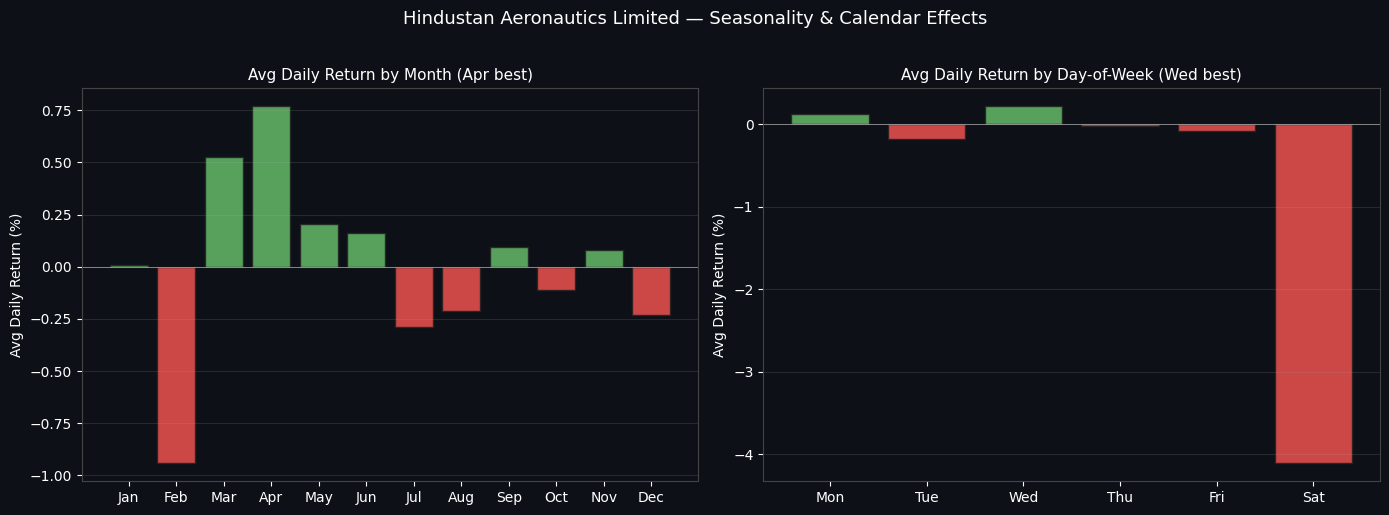

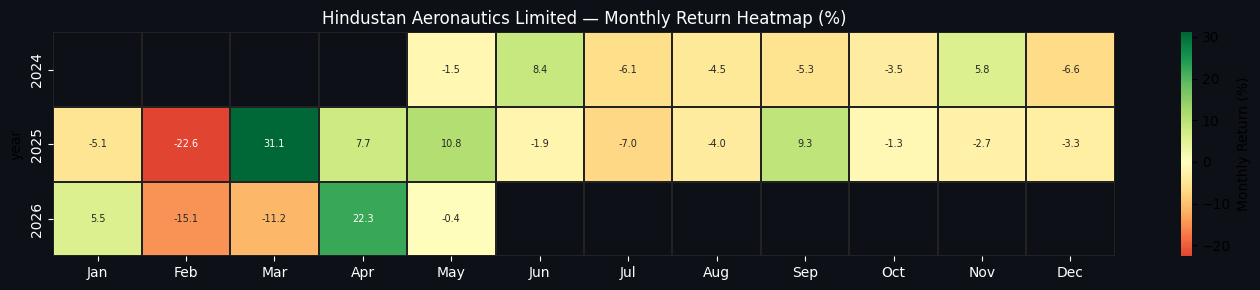

In [146]:
# ── Seasonality & Calendar Effect Analysis ───────────────────────────────────
_sr = data['Close'].pct_change().dropna()

# Month-of-year analysis
_month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
_monthly     = _sr.groupby(_sr.index.month)
_mon_mean    = _monthly.mean() * 100
_mon_median  = _monthly.median() * 100
_mon_pos_pct = _monthly.apply(lambda x: (x > 0).mean() * 100)
_mon_count   = _monthly.count()

# Day-of-week analysis
# Use a dict (not a list) so Saturday/Sunday indices from Indian market data don't crash
_dow_names  = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
_daily      = _sr.groupby(_sr.index.dayofweek)
_dow_mean   = _daily.mean() * 100
_dow_pos    = _daily.apply(lambda x: (x > 0).mean() * 100)

best_month  = int(_mon_mean.idxmax())
worst_month = int(_mon_mean.idxmin())
best_day    = int(_dow_mean.idxmax())
worst_day   = int(_dow_mean.idxmin())

print("═" * 60)
print(f"  SEASONALITY ANALYSIS — {TICKER}")
print("═" * 60)
print(f"\n  {'Month':<6}  {'Avg Daily Ret':>14}  {'Median':>8}  {'% Positive':>10}  {'N Days':>6}")
print(f"  {'─'*6}  {'─'*14}  {'─'*8}  {'─'*10}  {'─'*6}")
for m in range(1, 13):
    if m not in _mon_mean.index:
        continue
    flag = ' ◀ BEST' if m == best_month else (' ◀ WORST' if m == worst_month else '')
    print(f"  {_month_names[m-1]:<6}  {_mon_mean[m]:>+13.3f}%  "
          f"{_mon_median[m]:>+7.3f}%  {_mon_pos_pct[m]:>9.1f}%  "
          f"{_mon_count[m]:>6}{flag}")

print(f"\n  ★ Best Month  : {_month_names[best_month-1]}  ({_mon_mean[best_month]:+.3f}% avg/day)")
print(f"  ★ Worst Month : {_month_names[worst_month-1]}  ({_mon_mean[worst_month]:+.3f}% avg/day)")

# Show all trading days found in data (includes Sat for Indian markets)
_valid_days = sorted(_dow_mean.index.tolist())
print(f"\n  {'Day':<5}  {'Avg Daily Ret':>14}  {'% Positive':>10}")
print(f"  {'─'*5}  {'─'*14}  {'─'*10}")
for d in _valid_days:
    flag = ' ◀ BEST' if d == best_day else (' ◀ WORST' if d == worst_day else '')
    dname = _dow_names.get(int(d), f'Day{d}')
    print(f"  {dname:<5}  {_dow_mean[d]:>+13.3f}%  {_dow_pos[d]:>9.1f}%{flag}")

print(f"\n  ★ Best Day    : {_dow_names.get(best_day, f'Day{best_day}')}  ({_dow_mean[best_day]:+.3f}% avg/day)")
print(f"  ★ Worst Day   : {_dow_names.get(worst_day, f'Day{worst_day}')}  ({_dow_mean[worst_day]:+.3f}% avg/day)")
print("═" * 60)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig_seas, (ax_m, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
fig_seas.patch.set_facecolor('#0d1117')

_valid_months = [m for m in range(1, 13) if m in _mon_mean.index]
_mv = _mon_mean[_valid_months].values
_mc = ['#66bb6a' if v >= 0 else '#ef5350' for v in _mv]

ax_m.set_facecolor('#0d1117')
ax_m.bar([_month_names[m-1] for m in _valid_months], _mv, color=_mc, edgecolor='#222', alpha=0.85)
ax_m.axhline(0, color='white', linewidth=0.6, alpha=0.5)
ax_m.set_title(f"Avg Daily Return by Month ({_month_names[best_month-1]} best)", color='white', fontsize=11)
ax_m.set_ylabel("Avg Daily Return (%)", color='white')
ax_m.tick_params(colors='white')
for sp in ax_m.spines.values(): sp.set_color('#444')
ax_m.grid(True, alpha=0.15, axis='y')

_dv = [_dow_mean[d] for d in _valid_days]
_dc = ['#66bb6a' if v >= 0 else '#ef5350' for v in _dv]
_dl = [_dow_names.get(int(d), f'Day{d}') for d in _valid_days]

ax_d.set_facecolor('#0d1117')
ax_d.bar(_dl, _dv, color=_dc, edgecolor='#222', alpha=0.85)
ax_d.axhline(0, color='white', linewidth=0.6, alpha=0.5)
best_day_name = _dow_names.get(best_day, f'Day{best_day}')
ax_d.set_title(f"Avg Daily Return by Day-of-Week ({best_day_name} best)", color='white', fontsize=11)
ax_d.set_ylabel("Avg Daily Return (%)", color='white')
ax_d.tick_params(colors='white')
for sp in ax_d.spines.values(): sp.set_color('#444')
ax_d.grid(True, alpha=0.15, axis='y')

plt.suptitle(f"{company_name} — Seasonality & Calendar Effects", color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Monthly heatmap (avg return by year × month)
_sr_df = _sr.copy().to_frame('ret')
_sr_df['year']  = _sr_df.index.year
_sr_df['month'] = _sr_df.index.month
_pivot = _sr_df.pivot_table(index='year', columns='month', values='ret', aggfunc='sum') * 100
_pivot.columns = [_month_names[m-1] for m in _pivot.columns]

if len(_pivot) > 1:
    fig_hm, ax_hm = plt.subplots(figsize=(14, max(3, len(_pivot) * 0.4 + 1)))
    fig_hm.patch.set_facecolor('#0d1117')
    ax_hm.set_facecolor('#0d1117')
    try:
        import seaborn as sns
        sns.heatmap(_pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                    linewidths=0.3, linecolor='#222', ax=ax_hm,
                    cbar_kws={'label': 'Monthly Return (%)'}, annot_kws={'size': 7})
        ax_hm.set_title(f"{company_name} — Monthly Return Heatmap (%)", color='white', fontsize=12)
        ax_hm.tick_params(colors='white')
        plt.tight_layout()
        plt.show()
    except ImportError:
        plt.close(fig_hm)
        print("  (seaborn not installed — pip install seaborn for the heatmap)")


# Section 5 — Peer Comparison
## 5.1 — Define Sector Peers

In [147]:
# ── Automatic peer detection by sector / industry ────────────────────────────
SECTOR_PEERS = {
    # Indian Defence & Aerospace
    'Aerospace & Defence'    : ['HAL.NS','BEL.NS','BEML.NS','DPWL.NS','MTAR.NS'],
    'Aerospace & Defense'    : ['HAL.NS','BEL.NS','BEML.NS','DPWL.NS','MTAR.NS'],
    # yfinance returns 'Industrials' for HAL.NS sector
    'Industrials'            : ['HAL.NS','BEL.NS','BEML.NS','MTAR.NS','BHEL.NS'],
    # Indian IT
    'Information Technology' : ['TCS.NS','INFY.NS','WIPRO.NS','HCLTECH.NS','TECHM.NS'],
    # Indian Banks / Financials
    'Financial Services'     : ['HDFCBANK.NS','ICICIBANK.NS','SBIN.NS','AXISBANK.NS','KOTAKBANK.NS'],
    # US Tech
    'Technology'             : ['AAPL','MSFT','GOOGL','META','NVDA'],
    # US Financials
    'Financial Services_US'  : ['JPM','BAC','GS','MS','WFC'],
    # Indian Pharma
    'Pharmaceuticals'        : ['SUNPHARMA.NS','DRREDDY.NS','CIPLA.NS','DIVISLAB.NS','BIOCON.NS'],
    # Indian Auto
    'Consumer Cyclical'      : ['MARUTI.NS','TATAMOTORS.NS','M&M.NS','BAJAJ-AUTO.NS','HEROMOTOCO.NS'],
    # Oil & Gas
    'Energy'                 : ['RELIANCE.NS','ONGC.NS','IOC.NS','BPCL.NS','GAIL.NS'],
    # Indian Metals
    'Basic Materials'        : ['TATASTEEL.NS','JSWSTEEL.NS','HINDALCO.NS','SAIL.NS','NATIONALUM.NS'],
    # Indian Real Estate
    'Real Estate'            : ['DLF.NS','OBEROIRLTY.NS','GODREJPROP.NS','PRESTIGE.NS','BRIGADE.NS'],
    # Telecom
    'Communication Services' : ['BHARTIARTL.NS','IDEA.NS','TATACOMM.NS','RCOM.NS','RELIANCE.NS'],
}

# Industry-level fallback map (yfinance industry string → peers)
INDUSTRY_PEERS = {
    'Aerospace & Defense'    : ['HAL.NS','BEL.NS','BEML.NS','DPWL.NS','MTAR.NS'],
    'Defense'                : ['HAL.NS','BEL.NS','BEML.NS','DPWL.NS','MTAR.NS'],
    'Software—Application'   : ['TCS.NS','INFY.NS','WIPRO.NS','HCLTECH.NS','TECHM.NS'],
    'Banks—Regional'         : ['HDFCBANK.NS','ICICIBANK.NS','SBIN.NS','AXISBANK.NS','KOTAKBANK.NS'],
    'Drug Manufacturers'     : ['SUNPHARMA.NS','DRREDDY.NS','CIPLA.NS','DIVISLAB.NS','BIOCON.NS'],
    'Auto Manufacturers'     : ['MARUTI.NS','TATAMOTORS.NS','M&M.NS','BAJAJ-AUTO.NS','HEROMOTOCO.NS'],
    'Oil & Gas Integrated'   : ['RELIANCE.NS','ONGC.NS','IOC.NS','BPCL.NS','GAIL.NS'],
    'Steel'                  : ['TATASTEEL.NS','JSWSTEEL.NS','HINDALCO.NS','SAIL.NS','NATIONALUM.NS'],
}

# Auto-detect: try sector, then industry, then fall back to ticker alone
auto_peers = (SECTOR_PEERS.get(sector)
              or SECTOR_PEERS.get(industry)
              or INDUSTRY_PEERS.get(industry)
              or [TICKER])

if TICKER not in auto_peers:
    auto_peers = [TICKER] + auto_peers[:4]
else:
    auto_peers = auto_peers[:5]

# ── OVERRIDE: manually set peers if auto-detection is wrong ──────────────────
# auto_peers = ['HAL.NS', 'BEL.NS', 'BEML.NS', 'MTAR.NS', 'DPWL.NS']

print(f"Peers for {TICKER}  (sector: {sector} | industry: {industry}):")
print(auto_peers)


Peers for HAL.NS  (sector: Industrials | industry: Aerospace & Defense):
['HAL.NS', 'BEL.NS', 'BEML.NS', 'MTAR.NS', 'BHEL.NS']


In [148]:
# ── Peer fundamental comparison ───────────────────────────────────────────────
peer_rows = []
for p in auto_peers:
    try:
        pi = yf.Ticker(p).info
        peer_rows.append({
            "Ticker"       : p,
            "Company"      : pi.get("shortName", p),
            "P/E"          : round(pi.get("trailingPE", np.nan), 2),
            "Fwd P/E"      : round(pi.get("forwardPE", np.nan), 2),
            "P/B"          : round(pi.get("priceToBook", np.nan), 2),
            "EV/EBITDA"    : round(pi.get("enterpriseToEbitda", np.nan), 2),
            "ROE %"        : round(pi.get("returnOnEquity", 0)*100, 2),
            "Net Margin %" : round(pi.get("profitMargins", 0)*100, 2),
            "Debt/Equity"  : round(pi.get("debtToEquity", np.nan), 2),
            "Div Yield %"  : round(pi.get("dividendYield", 0)*100, 2),
            "52w High"     : pi.get("fiftyTwoWeekHigh"),
            "52w Low"      : pi.get("fiftyTwoWeekLow"),
            "Market Cap B" : round(pi.get("marketCap", 0)/1e9, 2),
        })
    except Exception as e:
        print(f"  {p}: {e}")

df_peers = pd.DataFrame(peer_rows).set_index("Ticker")

# Highlight target ticker
def highlight_target(row):
    return ['background-color: #1a3a5c; color: white' if row.name == TICKER else '' for _ in row]

print("=== Peer Comparison Table ===")
display(df_peers.style.apply(highlight_target, axis=1).format(na_rep="—"))

05/31/2026 12:07:37 AM - HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: MTAR.NS"}}}


=== Peer Comparison Table ===


,Company,P/E,Fwd P/E,P/B,EV/EBITDA,ROE %,Net Margin %,Debt/Equity,Div Yield %,52w High,52w Low,Market Cap B
Ticker,,,,,,,,,,,,
HAL.NS,HINDUSTAN AERONAUTICS LTD,31.550000,25.780000,7.010000,29.730000,23.980000,27.550000,0.030000,116.000000,5147.000000,3479.100000,2878.270000
BEL.NS,BHARAT ELECTRONICS LTD,49.490000,36.150000,12.520000,36.250000,27.560000,21.960000,0.270000,106.000000,473.450000,361.200000,3002.490000
BEML.NS,BEML LIMITED,101.020000,30.160000,5.120000,34.130000,0.000000,5.920000,23.790000,76.000000,2437.400000,1355.000000,143.460000
MTAR.NS,MTAR.NS,—,—,—,—,0.000000,0.000000,—,0.000000,—,—,0.000000
BHEL.NS,BHEL,90.990000,32.570000,5.540000,60.320000,6.290000,4.740000,31.310000,12.000000,424.900000,205.120000,1451.150000


In [149]:
# ── Relative price performance chart ─────────────────────────────────────────
peer_price_data = {}
for p in auto_peers:
    try:
        tmp = yf.download(p, period=PERIOD, auto_adjust=True, progress=False)
        if isinstance(tmp.columns, pd.MultiIndex):
            tmp.columns = [col[0] for col in tmp.columns]
        if len(tmp) > 20:
            peer_price_data[p] = tmp['Close']
    except Exception:
        pass

if peer_price_data:
    price_df = pd.DataFrame(peer_price_data).dropna(how='all')
    norm_df  = price_df.div(price_df.iloc[0]) * 100

    fig_peer = go.Figure()
    for col in norm_df.columns:
        width  = 3 if col == TICKER else 1.5
        fig_peer.add_trace(go.Scatter(
            x=norm_df.index, y=norm_df[col],
            name=col, line=dict(width=width)
        ))
    fig_peer.update_layout(
        title=f"Peer Relative Performance (Base = 100, {PERIOD})",
        yaxis_title="Indexed Price",
        template='plotly_dark', height=450
    )
    fig_peer.show()

    # Bar chart: P/E comparison
    if 'P/E' in df_peers.columns:
        fig_bar = px.bar(
            df_peers.reset_index(),
            x='Ticker', y='P/E', color='Ticker',
            title='Peer P/E Comparison',
            template='plotly_dark'
        )
        fig_bar.show()

05/31/2026 12:07:43 AM - $MTAR.NS: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")
05/31/2026 12:07:43 AM - 
1 Failed download:
05/31/2026 12:07:43 AM - ['MTAR.NS']: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


# Section 6 — News Collection (7 APIs)
> All API keys are loaded from `.env`. Change the `TICKER` in Section 1 — news queries adapt automatically.

In [150]:
# ── Helper to derive search-friendly company name & symbol ───────────────────
search_name = info.get('longName', TICKER.replace('.NS','').replace('.BO',''))
# US API symbol (strip exchange suffix for US-style APIs)
us_symbol   = TICKER.replace('.NS','').replace('.BO','')

# Master news corpus — all articles from all sources land here
all_news_items = []

def add_news(source, items):
    for item in items:
        item['source_api'] = source
        all_news_items.append(item)
    print(f"  [{source:18s}] {len(items)} articles collected")

print(f"Collecting news for: {search_name} / {us_symbol}\n")

In [151]:
# ── 1. Alpha Vantage News Sentiment ──────────────────────────────────────────
from datetime import datetime, timedelta

def fetch_alphavantage(symbol, api_key, n=MAX_NEWS):
    if not api_key:
        return []
    try:
        url = (f"https://www.alphavantage.co/query?function=NEWS_SENTIMENT"
               f"&tickers={symbol}&apikey={api_key}&limit={n}")
        resp = requests.get(url, timeout=15)
        feed = resp.json().get('feed', [])
        return [{
            'title'    : x.get('title',''),
            'summary'  : x.get('summary',''),
            'url'      : x.get('url',''),
            'published': x.get('time_published',''),
            'sentiment_score': x.get('overall_sentiment_score'),
            'sentiment_label': x.get('overall_sentiment_label'),
        } for x in feed[:n]]
    except Exception as e:
        print(f"  AlphaVantage error: {e}"); return []

av_news = fetch_alphavantage(us_symbol, ALPHA_VANTAGE_KEY)
add_news("AlphaVantage", av_news)

# ── 2. Finnhub Company News ───────────────────────────────────────────────────
def fetch_finnhub(symbol, api_key, n=MAX_NEWS):
    if not api_key:
        return []
    try:
        end   = datetime.now()
        start = end - timedelta(days=30)
        url   = (f"https://finnhub.io/api/v1/company-news?symbol={symbol}"
                 f"&from={start.date()}&to={end.date()}&token={api_key}")
        items = requests.get(url, timeout=15).json()
        if isinstance(items, list):
            return [{
                'title'    : x.get('headline',''),
                'summary'  : x.get('summary',''),
                'url'      : x.get('url',''),
                'published': datetime.fromtimestamp(x['datetime']).isoformat() if x.get('datetime') else '',
            } for x in items[:n]]
        return []
    except Exception as e:
        print(f"  Finnhub error: {e}"); return []

fh_news = fetch_finnhub(us_symbol, FINNHUB_KEY)
add_news("Finnhub", fh_news)

  [AlphaVantage      ] 15 articles collected
  [Finnhub           ] 15 articles collected


In [152]:
# ── 3. Tavily AI Web Search ───────────────────────────────────────────────────
def fetch_tavily(query, api_key, n=MAX_NEWS):
    if not api_key:
        return []
    try:
        from tavily import TavilyClient
        client = TavilyClient(api_key=api_key)
        resp = client.search(query=query, max_results=n, topic="news", time_range="month")
        return [{
            'title'    : x.get('title',''),
            'summary'  : x.get('content',''),
            'url'      : x.get('url',''),
            'published': '',
            'relevance': x.get('score', 0)
        } for x in resp.get('results', [])[:n]]
    except Exception as e:
        print(f"  Tavily error: {e}"); return []

tv_news = fetch_tavily(f"{search_name} stock news", TAVILY_KEY)
add_news("Tavily", tv_news)

# ── 4. NewsAPI ────────────────────────────────────────────────────────────────
def fetch_newsapi(query, api_key, n=MAX_NEWS):
    if not api_key:
        return []
    try:
        from newsapi import NewsApiClient
        client   = NewsApiClient(api_key=api_key)
        articles = client.get_everything(q=query, language='en', sort_by='publishedAt',
                                          page_size=n).get('articles', [])
        return [{
            'title'    : a.get('title',''),
            'summary'  : a.get('description','') or a.get('content',''),
            'url'      : a.get('url',''),
            'published': a.get('publishedAt',''),
        } for a in articles[:n]]
    except Exception as e:
        print(f"  NewsAPI error: {e}"); return []

na_news = fetch_newsapi(search_name, NEWSAPI_KEY)
add_news("NewsAPI", na_news)

  [Tavily            ] 15 articles collected
  [NewsAPI           ] 15 articles collected


In [153]:
# ── 5. EODHD Financial News ───────────────────────────────────────────────────
def fetch_eodhd(symbol, api_key, n=MAX_NEWS):
    if not api_key:
        return []
    try:
        # EODHD uses TICKER.EXCHANGE format; try US fallback
        sym = f"{symbol}.US" if '.' not in symbol else symbol.replace('.NS', '.NSE').replace('.BO', '.BSE')
        url = f"https://eodhd.com/api/news?s={sym}&api_token={api_key}&limit={n}"
        items = requests.get(url, timeout=15).json()
        if isinstance(items, list):
            return [{
                'title'    : x.get('title',''),
                'summary'  : x.get('content','')[:500],
                'url'      : x.get('link',''),
                'published': x.get('date',''),
                'sentiment_score': x.get('sentiment', {}).get('polarity'),
            } for x in items[:n]]
        return []
    except Exception as e:
        print(f"  EODHD error: {e}"); return []

eo_news = fetch_eodhd(us_symbol, EODHD_KEY)
add_news("EODHD", eo_news)

# ── 6. Marketaux ──────────────────────────────────────────────────────────────
def fetch_marketaux(symbol, api_key, n=MAX_NEWS):
    if not api_key:
        return []
    try:
        url  = (f"https://api.marketaux.com/v1/news/all?symbols={symbol}"
                f"&language=en&filter_entities=true&api_token={api_key}&limit={n}")
        data = requests.get(url, timeout=15).json().get('data', [])
        return [{
            'title'    : x.get('title',''),
            'summary'  : x.get('description',''),
            'url'      : x.get('url',''),
            'published': x.get('published_at',''),
        } for x in data[:n]]
    except Exception as e:
        print(f"  Marketaux error: {e}"); return []

mx_news = fetch_marketaux(us_symbol, MARKETAUX_KEY)
add_news("Marketaux", mx_news)

# ── 7. APILayer Finance News ──────────────────────────────────────────────────
def fetch_apilayer(symbol, api_key, n=MAX_NEWS):
    if not api_key:
        return []
    try:
        url  = f"https://api.apilayer.com/financelayer/news?symbols={symbol}&apikey={api_key}"
        data = requests.get(url, timeout=15).json().get('data', [])
        return [{
            'title'    : x.get('title',''),
            'summary'  : x.get('description',''),
            'url'      : x.get('url',''),
            'published': x.get('published_at',''),
        } for x in data[:n]]
    except Exception as e:
        print(f"  APILayer error: {e}"); return []

al_news = fetch_apilayer(us_symbol, APILAYER_KEY)
add_news("APILayer", al_news)

print(f"\n✅ Total news collected across all APIs: {len(all_news_items)}")

  [EODHD             ] 15 articles collected
  [Marketaux         ] 3 articles collected
  [APILayer          ] 15 articles collected

✅ Total news collected across all APIs: 93


# Section 7 — Web Scraping
Scrapes Yahoo Finance, MoneyControl, Economic Times, Reuters using BeautifulSoup + GNews RSS feeds.

In [154]:
HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                   "AppleWebKit/537.36 (KHTML, like Gecko) "
                   "Chrome/120.0.0.0 Safari/537.36"),
    "Accept-Language": "en-US,en;q=0.9",
}

def scrape_bs4(url, title_sel, link_sel=None, base_url="", source_label="", n=10):
    """Generic BeautifulSoup scraper."""
    results = []
    try:
        resp = requests.get(url, headers=HEADERS, timeout=20)
        soup = BeautifulSoup(resp.text, 'lxml')
        tags = soup.select(title_sel)[:n]
        for tag in tags:
            title = tag.get_text(strip=True)
            href  = tag.get('href','') if tag.name == 'a' else (
                    tag.find('a').get('href','') if tag.find('a') else '')
            if href and not href.startswith('http'):
                href = base_url + href
            if title:
                results.append({'title': title, 'url': href, 'summary': '',
                                 'published': '', 'source_api': source_label})
    except Exception as e:
        print(f"  [{source_label}] scrape error: {e}")
    return results

# ── Yahoo Finance RSS ─────────────────────────────────────────────────────────
def scrape_yahoo_rss(symbol, n=MAX_NEWS):
    url = f"https://feeds.finance.yahoo.com/rss/2.0/headline?s={symbol}&region=US&lang=en-US"
    try:
        feed  = feedparser.parse(url)
        items = []
        for entry in feed.entries[:n]:
            items.append({
                'title'    : entry.get('title',''),
                'summary'  : entry.get('summary',''),
                'url'      : entry.get('link',''),
                'published': entry.get('published',''),
                'source_api': 'Yahoo RSS'
            })
        return items
    except Exception as e:
        print(f"  Yahoo RSS error: {e}"); return []

yahoo_scraped = scrape_yahoo_rss(us_symbol)
all_news_items.extend(yahoo_scraped)
print(f"  [{'Yahoo RSS':18s}] {len(yahoo_scraped)} articles")

# ── GNews (Google News RSS via gnews library) ─────────────────────────────────
def fetch_gnews(query, n=MAX_NEWS):
    try:
        from gnews import GNews
        gn = GNews(language='en', country='IN', max_results=n)
        results = gn.get_news(query)
        return [{
            'title'    : r.get('title',''),
            'summary'  : r.get('description',''),
            'url'      : r.get('url',''),
            'published': str(r.get('published date','')),
            'source_api': 'GNews'
        } for r in results]
    except Exception as e:
        print(f"  GNews error: {e}"); return []

gn_news = fetch_gnews(search_name)
all_news_items.extend(gn_news)
print(f"  [{'GNews':18s}] {len(gn_news)} articles")

  [Yahoo RSS         ] 15 articles
  [GNews             ] 15 articles


In [155]:
# ── MoneyControl News Scraper (Indian Stocks) ─────────────────────────────────
def scrape_moneycontrol(company_name, n=MAX_NEWS):
    """Scrape MoneyControl news search results."""
    query = company_name.replace(' ', '+')
    url   = f"https://www.moneycontrol.com/news/tags/{query}.html"
    results = scrape_bs4(url,
        title_sel='li.clearfix h2 a, .newslist li a, .article_list h2 a',
        base_url='https://www.moneycontrol.com',
        source_label='MoneyControl', n=n)
    # Fallback: use their search
    if not results:
        url2 = f"https://www.moneycontrol.com/news/news-all.html"
        results = scrape_bs4(url2,
            title_sel='h2 a, .article_list a',
            base_url='https://www.moneycontrol.com',
            source_label='MoneyControl', n=n)
    return results

mc_scraped = scrape_moneycontrol(search_name)
all_news_items.extend(mc_scraped)
print(f"  [{'MoneyControl':18s}] {len(mc_scraped)} articles")

# ── Economic Times RSS ────────────────────────────────────────────────────────
def scrape_et_rss(company_name, n=MAX_NEWS):
    query = company_name.replace(' ', '%20')
    url   = f"https://economictimes.indiatimes.com/rssfeedstopstories.cms"
    try:
        feed  = feedparser.parse(url)
        items = []
        for entry in feed.entries[:n*3]:
            title = entry.get('title','')
            if any(kw.lower() in title.lower() for kw in company_name.split()[:2]):
                items.append({
                    'title'    : title,
                    'summary'  : entry.get('summary',''),
                    'url'      : entry.get('link',''),
                    'published': entry.get('published',''),
                    'source_api': 'EconomicTimes'
                })
            if len(items) >= n:
                break
        # If no matching, take top n
        if not items:
            for entry in feed.entries[:n]:
                items.append({
                    'title'    : entry.get('title',''),
                    'summary'  : entry.get('summary',''),
                    'url'      : entry.get('link',''),
                    'published': entry.get('published',''),
                    'source_api': 'EconomicTimes'
                })
        return items
    except Exception as e:
        print(f"  ET RSS error: {e}"); return []

et_scraped = scrape_et_rss(search_name)
all_news_items.extend(et_scraped)
print(f"  [{'EconomicTimes':18s}] {len(et_scraped)} articles")

  [MoneyControl      ] 0 articles
  [EconomicTimes     ] 15 articles


In [156]:
# ── Multi-source RSS scraper (India + Global Business News) ──────────────────
# NOTE: feeds.reuters.com was shut down in 2024 (DNS no longer resolves).
#       Replaced with working India-specific and global RSS feeds.
def scrape_multi_rss(n=MAX_NEWS):
    """Fetch articles from multiple RSS feeds, filtered for company relevance."""
    rss_sources = [
        # India financial news feeds
        ("ET_Markets",    "https://economictimes.indiatimes.com/markets/rss.cms"),
        ("ET_Industries", "https://economictimes.indiatimes.com/industry/rss.cms"),
        ("BS_Markets",    "https://www.business-standard.com/rss/markets-106.rss"),
        ("Livemint",      "https://www.livemint.com/rss/markets"),
        ("NDTV_Profit",   "https://feeds.feedburner.com/ndtvprofit-latest"),
        # Ticker-specific Yahoo Finance RSS (no API key needed)
        ("Yahoo_Finance", f"https://finance.yahoo.com/rss/headline?s={us_symbol}"),
    ]
    all_items = []
    # Keywords to match for relevance filtering
    kws = [kw.lower() for kw in
           [search_name, TICKER.replace('.NS','').replace('.BO',''),
            company_name.split()[0] if company_name else '']]

    for label, url in rss_sources:
        count = 0
        try:
            feed = feedparser.parse(url)
            for entry in feed.entries:
                title   = entry.get('title', '')
                summary = entry.get('summary', '')
                text    = (title + ' ' + summary).lower()
                # Accept if any keyword matches, or it is the ticker-specific feed
                if any(kw in text for kw in kws if kw) or 'yahoo_finance' in label.lower():
                    all_items.append({
                        'title'     : title,
                        'summary'   : summary,
                        'url'       : entry.get('link', ''),
                        'published' : entry.get('published', ''),
                        'source_api': label,
                    })
                    count += 1
                    if count >= n:
                        break
        except Exception as e:
            print(f"  [{label:18s}] error: {e}")
            continue
        print(f"  [{label:18s}] {count} articles")

    return all_items

rss_scraped = scrape_multi_rss()
all_news_items.extend(rss_scraped)
print(f"\n  [RSS Total         ] {len(rss_scraped)} articles from multi-source RSS")

# ── Selenium — Actual JS-page scraper (MoneyControl, Economic Times, BS) ─────
def scrape_selenium_live(url, css_selectors, source_label, n=8, headless=True, wait_sec=4):
    """
    Full headless Chrome browser scrape for JavaScript-rendered pages.
    Falls back gracefully if Chrome / ChromeDriver is not available.
    """
    results = []
    try:
        from selenium import webdriver
        from selenium.webdriver.chrome.options import Options
        from selenium.webdriver.chrome.service  import Service
        from selenium.webdriver.common.by        import By
        from webdriver_manager.chrome            import ChromeDriverManager

        opts = Options()
        if headless:
            opts.add_argument("--headless=new")
        opts.add_argument("--no-sandbox")
        opts.add_argument("--disable-dev-shm-usage")
        opts.add_argument("--disable-gpu")
        opts.add_argument("--log-level=3")
        opts.add_argument(f"user-agent={HEADERS['User-Agent']}")
        opts.add_experimental_option("excludeSwitches", ["enable-logging"])

        driver = webdriver.Chrome(
            service=Service(ChromeDriverManager().install()),
            options=opts
        )
        driver.set_page_load_timeout(30)
        try:
            driver.get(url)
            time.sleep(wait_sec)

            for sel in css_selectors:
                try:
                    elements = driver.find_elements(By.CSS_SELECTOR, sel)
                    for el in elements[:n]:
                        title = el.text.strip()
                        href  = (el.get_attribute('href') or
                                 el.find_element(By.XPATH, './ancestor::a').get_attribute('href')
                                 if el.tag_name != 'a' else '')
                        if not href:
                            href = el.get_attribute('href') or ''
                        if title and len(title) > 10:
                            results.append({'title': title, 'url': href, 'summary': '',
                                            'published': '', 'source_api': source_label})
                except Exception:
                    pass
        finally:
            driver.quit()
    except Exception as e:
        print(f"  Selenium [{source_label}] skipped: {e}")
    return results

# MoneyControl — company-specific news page (updated CSS selectors 2024)
mc_query  = search_name.lower().replace(' ', '-')
se_mc = scrape_selenium_live(
    url=f"https://www.moneycontrol.com/news/tags/{mc_query}.html",
    css_selectors=[
        'li.clearfix h2 a',          # older layout
        '.article_list h2 a',        # mid layout
        'h2 a',                      # generic
        '.news_title a',             # alternate
        '[data-section] h3 a',       # 2024 redesign
    ],
    source_label='MC_Selenium', n=10
)
all_news_items.extend(se_mc)
print(f"  [{'MC_Selenium':18s}] {len(se_mc)} articles")

# Economic Times — company news search
et_query = search_name.lower().replace(' ', '-')
se_et = scrape_selenium_live(
    url=f"https://economictimes.indiatimes.com/topic/{et_query}",
    css_selectors=['article h3 a', '.eachStory h3 a', '.story-box h3 a', 'h3.clr a'],
    source_label='ET_Selenium', n=10
)
all_news_items.extend(se_et)
print(f"  [{'ET_Selenium':18s}] {len(se_et)} articles")

# Business Standard
bs_query = search_name.lower().replace(' ', '+')
se_bs = scrape_selenium_live(
    url=f"https://www.business-standard.com/search?q={bs_query}",
    css_selectors=['h2 a', '.listing-txt h2 a', '.article-head a'],
    source_label='BusinessStandard', n=8
)
all_news_items.extend(se_bs)
print(f"  [{'BusinessStandard':18s}] {len(se_bs)} articles")


  [ET_Markets        ] 0 articles
  [ET_Industries     ] 0 articles
  [BS_Markets        ] 0 articles
  [Livemint          ] 4 articles
  [NDTV_Profit       ] 0 articles


05/31/2026 12:08:34 AM - ====== WebDriver manager ======


  [Yahoo_Finance     ] 15 articles

  [RSS Total         ] 19 articles from multi-source RSS


05/31/2026 12:08:35 AM - Get LATEST chromedriver version for google-chrome
05/31/2026 12:08:36 AM - Get LATEST chromedriver version for google-chrome
05/31/2026 12:08:36 AM - WebDriver version 148.0.7778.178 selected
05/31/2026 12:08:36 AM - Modern chrome version https://storage.googleapis.com/chrome-for-testing-public/148.0.7778.178/win64/chromedriver-win64.zip
05/31/2026 12:08:36 AM - About to download new driver from https://storage.googleapis.com/chrome-for-testing-public/148.0.7778.178/win64/chromedriver-win64.zip
05/31/2026 12:08:37 AM - Driver downloading response is 200
05/31/2026 12:08:38 AM - Driver has been saved in cache [C:\Users\Shubhro Dev\.wdm\drivers\chromedriver\win64\148.0.7778.178]
05/31/2026 12:08:49 AM - ====== WebDriver manager ======


  [MC_Selenium       ] 0 articles


05/31/2026 12:08:49 AM - Driver [C:\Users\Shubhro Dev\.wdm\drivers\chromedriver\win64\148.0.7778.178\chromedriver-win64/chromedriver.exe] found in cache by browser version
05/31/2026 12:08:58 AM - ====== WebDriver manager ======


  [ET_Selenium       ] 0 articles


05/31/2026 12:08:58 AM - Driver [C:\Users\Shubhro Dev\.wdm\drivers\chromedriver\win64\148.0.7778.178\chromedriver-win64/chromedriver.exe] found in cache by browser version


  [BusinessStandard  ] 4 articles


In [157]:
# ── Reddit — RSS API (no auth needed) ─────────────────────────────────────────
# Reddit's public JSON search API now requires OAuth (blocked since mid-2023).
# The RSS search endpoint still works without authentication.
def scrape_reddit(query, subreddits=None, n=MAX_NEWS):
    """Fetch Reddit posts using the subreddit RSS search endpoint (no auth required)."""
    if subreddits is None:
        subreddits = ['stocks', 'investing', 'IndiaInvestments', 'wallstreetbets',
                      'SecurityAnalysis', 'StockMarket']
    results    = []
    _hdr       = {'User-Agent': 'Mozilla/5.0 (SENTRAL-research/1.0; stock analysis)'}
    for sub in subreddits:
        try:
            url  = (f"https://www.reddit.com/r/{sub}/search.rss"
                    f"?q={requests.utils.quote(query)}&restrict_sr=1&sort=new")
            resp = requests.get(url, headers=_hdr, timeout=20)
            if resp.status_code != 200:
                continue
            feed = feedparser.parse(resp.content)
            for entry in feed.entries[:n]:
                title = entry.get('title', '').strip()
                # RSS search returns noisy boilerplate entries; filter them
                if not title or title.lower() in ('[link]', '[comments]', 'reddit'):
                    continue
                results.append({
                    'title'    : title,
                    'summary'  : entry.get('summary', '')[:400],
                    'url'      : entry.get('link', ''),
                    'published': entry.get('published', ''),
                    'source_api': f"Reddit_r/{sub}",
                })
            if len(results) >= n * 2:
                break
        except Exception:
            pass
    print(f"  [{'Reddit':18s}] {len(results)} posts from {len(subreddits)} subreddits")
    return results[:n * 2]

reddit_posts = scrape_reddit(search_name)
all_news_items.extend(reddit_posts)

# ── StockTwits — Public stream API ────────────────────────────────────────────
# StockTwits public stream works for US tickers.
# Indian stocks (HAL.NS / .BO) are not listed on StockTwits — skip gracefully.
def scrape_stocktwits(symbol, n=MAX_NEWS):
    """Fetch latest messages from StockTwits public symbol stream (US tickers only)."""
    results = []
    # Indian stocks are not on StockTwits
    if symbol.endswith('.NS') or symbol.endswith('.BO'):
        print(f"  [{'StockTwits':18s}] Skipped — Indian stock ({symbol}) not listed on StockTwits")
        return results
    clean_sym = symbol.replace('.NS', '').replace('.BO', '')
    try:
        url  = f"https://api.stocktwits.com/api/2/streams/symbol/{clean_sym}.json?limit={n}"
        resp = requests.get(url, timeout=15)
        if resp.status_code == 200:
            messages = resp.json().get('messages', [])
            for m in messages[:n]:
                body      = m.get('body', '')
                sentiment = m.get('entities', {}).get('sentiment', {})
                results.append({
                    'title'       : body[:120].replace('\n', ' '),
                    'summary'     : body[:300],
                    'url'         : f"https://stocktwits.com/message/{m.get('id','')}",
                    'published'   : m.get('created_at', ''),
                    'source_api'  : 'StockTwits',
                    'st_sentiment': sentiment.get('basic', 'Neutral') if sentiment else 'Neutral',
                })
        else:
            print(f"  StockTwits API returned {resp.status_code} — auth may be required")
    except Exception as e:
        print(f"  StockTwits error: {e}")
    print(f"  [{'StockTwits':18s}] {len(results)} messages")
    return results

st_posts = scrape_stocktwits(TICKER)
all_news_items.extend(st_posts)

print(f"\n✅ Grand total news (APIs + scraping + social media): {len(all_news_items)}")


  [Reddit            ] 16 posts from 6 subreddits
  [StockTwits        ] Skipped — Indian stock (HAL.NS) not listed on StockTwits

✅ Grand total news (APIs + scraping + social media): 177


In [158]:
# ── Step 1: Deduplicate ───────────────────────────────────────────────────────
seen_titles = set()
clean_corpus = []
for item in all_news_items:
    t = item.get('title', '').strip()
    s = item.get('summary', '') or ''
    if not t or t.lower() in seen_titles:
        continue
    seen_titles.add(t.lower())
    item['text_for_sentiment'] = (s if len(s) > 20 else t)[:512]
    clean_corpus.append(item)

print(f"✅ After deduplication: {len(clean_corpus)} unique articles")

# ── Step 2: Full article body extraction via newspaper3k ──────────────────────
# Fetches full text for articles that only have a title/short summary.
# Skips Reddit/StockTwits (they are already full-text).
from newspaper import Article as NpArticle
import logging
logging.getLogger('newspaper').setLevel(logging.ERROR)  # suppress noisy logs

SCRAPE_FULL_TEXT = True   # set False to skip (faster)
MAX_FULLTEXT     = 30     # limit full fetches to keep runtime reasonable

def fetch_full_text(url):
    try:
        art = NpArticle(url)
        art.download()
        art.parse()
        return art.text.strip()[:1000] if art.text else ''
    except Exception:
        return ''

if SCRAPE_FULL_TEXT:
    fetched = 0
    print("Extracting full article text (newspaper3k)…")
    for item in clean_corpus:
        src = item.get('source_api', '')
        if src in ('Reddit_r/stocks', 'Reddit_r/investing', 'Reddit_r/IndiaInvestments',
                   'Reddit_r/wallstreetbets', 'StockTwits') or not item.get('url'):
            continue
        if len(item.get('text_for_sentiment', '')) > 200:
            continue  # already has good summary
        if fetched >= MAX_FULLTEXT:
            break
        full = fetch_full_text(item['url'])
        if full and len(full) > 100:
            item['text_for_sentiment'] = full[:512]
            item['full_text_fetched']  = True
            fetched += 1
    print(f"  Full text fetched for {fetched} articles")

# ── Step 3: Relevance scoring ─────────────────────────────────────────────────
# Score each article 0–1 based on keyword overlap with the company name/ticker.
company_keywords = (
    [search_name.lower()]
    + search_name.lower().split()
    + [us_symbol.lower(), TICKER.lower()]
    + [info.get('sector','').lower(), info.get('industry','').lower()]
)
company_keywords = [k for k in company_keywords if len(k) > 2]

def relevance_score(item):
    text = (item.get('title','') + ' ' + item.get('summary','')).lower()
    if not text.strip():
        return 0.0
    hits  = sum(1 for kw in company_keywords if kw in text)
    score = min(hits / max(len(company_keywords), 1), 1.0)
    # Boost if company name appears in title
    if search_name.lower() in item.get('title','').lower():
        score = min(score + 0.4, 1.0)
    if us_symbol.lower() in item.get('title','').lower():
        score = min(score + 0.3, 1.0)
    return round(score, 3)

for item in clean_corpus:
    item['relevance_score'] = relevance_score(item)

# ── Step 4: Build df_news sorted by relevance ─────────────────────────────────
df_news = pd.DataFrame(clean_corpus).sort_values('relevance_score', ascending=False)
# Keep articles with relevance > 0, but always keep at least 20
threshold = 0.0
high_rel   = df_news[df_news['relevance_score'] > threshold]
df_news    = high_rel if len(high_rel) >= 20 else df_news.head(max(len(high_rel), 20))
df_news    = df_news.reset_index(drop=True)

print(f"\n✅ Final corpus: {len(df_news)} articles (sorted by relevance)")
print(f"   Sources: {df_news['source_api'].value_counts().to_dict()}")
print(f"   Avg relevance score: {df_news['relevance_score'].mean():.3f}")
print("\nTop 5 most relevant headlines:")
for _, row in df_news.head(5).iterrows():
    print(f"  [{row['relevance_score']:.2f}] {row['title'][:90]}")

✅ After deduplication: 129 unique articles
Extracting full article text (newspaper3k)…
  Full text fetched for 30 articles

✅ Final corpus: 57 articles (sorted by relevance)
   Sources: {'GNews': 13, 'AlphaVantage': 10, 'Tavily': 8, 'BusinessStandard': 4, 'NewsAPI': 4, 'Livemint': 4, 'Finnhub': 3, 'Reddit_r/IndiaInvestments': 3, 'Yahoo RSS': 2, 'Reddit_r/StockMarket': 2, 'Marketaux': 1, 'Reddit_r/wallstreetbets': 1, 'Reddit_r/investing': 1, 'Reddit_r/stocks': 1}
   Avg relevance score: 0.316

Top 5 most relevant headlines:
  [0.90] Hindustan Aeronautics Limited Stock 12‑Month Price Target Cut to INR 5184.58, Implies 18% 
  [0.90] Hindustan Aeronautics Limited SC - Detailed squad 24/25 (Gallery) - Transfermarkt
  [0.68] Tejas veteran steps into to job at HAL - FlightGlobal
  [0.55] Jinkushal Industries Limited Announces Audited Financial Results for the Quarter and Finan
  [0.50] Aitech Awarded $63M Contract for Avionics Computing Solutions to Power India's Light Comba


# Section 8 — Multi-Model Sentiment Analysis
Running 10 models: NLTK VADER, FinBERT, DistilRoBERTa, RoBERTa-large, StockTwits RoBERTa, Llama-3 (Groq), Gemma-2 (Groq), Mixtral (HF), Gemini 1.5 Flash, Gemini 1.5 Pro

In [159]:
# ── Prepare texts: use first MAX_NEWS items for heavy models ─────────────────
TEXTS_FOR_LLM = df_news['text_for_sentiment'].dropna().head(MAX_NEWS).tolist()
TEXTS_FOR_HF  = TEXTS_FOR_LLM[:10]   # local transformers — limit to avoid OOM

def normalize_label(label_str):
    """Convert various label formats to: positive / negative / neutral"""
    if not label_str:
        return 'neutral'
    s = str(label_str).lower()
    if any(w in s for w in ['positive','bullish','bull','very_positive','strong_positive','pos']):
        return 'positive'
    if any(w in s for w in ['negative','bearish','bear','very_negative','strong_negative','neg']):
        return 'negative'
    return 'neutral'

sentiment_results = {}   # model_name -> list of (label, score) per article

print("Starting sentiment analysis pipeline…\n")

Starting sentiment analysis pipeline…



In [160]:
# ── Model 1: NLTK VADER ──────────────────────────────────────────────────────
print("─" * 50)
print("Model 1/10 — NLTK VADER")
sia = SentimentIntensityAnalyzer()
vader_results = []
for text in TEXTS_FOR_LLM:
    sc = sia.polarity_scores(text)
    compound = sc['compound']
    label = 'positive' if compound >= 0.05 else ('negative' if compound <= -0.05 else 'neutral')
    vader_results.append((label, abs(compound)))

sentiment_results['NLTK_VADER'] = vader_results
counts = pd.Series([r[0] for r in vader_results]).value_counts()
print(f"  Positive: {counts.get('positive',0)} | Neutral: {counts.get('neutral',0)} | Negative: {counts.get('negative',0)}")

──────────────────────────────────────────────────
Model 1/10 — NLTK VADER
  Positive: 9 | Neutral: 1 | Negative: 5


In [162]:
# ── HuggingFace Inference helper ─────────────────────────────────────────────
from huggingface_hub import InferenceClient

hf_client = InferenceClient(provider="auto", api_key=HF_TOKEN)

def hf_classify_batch(texts, model_id, model_label, n=None):
    """Run HF Inference API text classification on a batch of texts."""
    if not HF_TOKEN:
        print(f"  ⚠  No HF_TOKEN — skipping {model_label}")
        return []
    texts   = (texts[:n] if n else texts)
    results = []
    errors  = 0
    try:
        for text in texts:
            try:
                res = hf_client.text_classification(text[:512], model=model_id)
                if isinstance(res, list) and res:
                    top = sorted(res, key=lambda x: x.score, reverse=True)[0]
                    results.append((normalize_label(top.label), round(top.score, 4)))
                else:
                    results.append(('neutral', 0.5))
                    errors += 1
            except Exception:
                results.append(('neutral', 0.5))
                errors += 1
    except Exception as e:
        print(f"  {model_label} batch error: {e}")
    if errors == len(texts) and errors > 0:
        print(f"  ⚠  {model_label}: All {errors} requests failed (model may be unavailable on HF API)")
    counts = pd.Series([r[0] for r in results]).value_counts()
    print(f"  Positive: {counts.get('positive',0)} | Neutral: {counts.get('neutral',0)} | Negative: {counts.get('negative',0)}")
    return results

# ── Model 2: FinBERT (ProsusAI) ───────────────────────────────────────────────
print("─" * 50)
print("Model 2/10 — FinBERT (ProsusAI/finbert)")
finbert_res = hf_classify_batch(TEXTS_FOR_HF, "ProsusAI/finbert", "FinBERT")
sentiment_results['FinBERT'] = finbert_res

# ── Model 3: FinBERT-Tone ─────────────────────────────────────────────────────
# Try yiyanghkust/finbert-tone with :fastest routing; fall back to
# cardiffnlp/twitter-roberta-base-sentiment-latest if the primary is unavailable
print("─" * 50)
print("Model 3/10 — FinBERT-Tone / fallback RoBERTa-Sentiment")
finbert_tone_res = hf_classify_batch(
    TEXTS_FOR_HF, "yiyanghkust/finbert-tone:fastest", "FinBERT-Tone:fastest"
)
# Check if all results defaulted to neutral (i.e., model unavailable)
_all_neutral = finbert_tone_res and all(r[0] == 'neutral' and r[1] == 0.5 for r in finbert_tone_res)
if not finbert_tone_res or _all_neutral:
    print("  → finbert-tone unavailable; trying cardiffnlp/twitter-roberta-base-sentiment-latest")
    finbert_tone_res = hf_classify_batch(
        TEXTS_FOR_HF,
        "cardiffnlp/twitter-roberta-base-sentiment-latest",
        "RoBERTa-Sentiment (fallback)"
    )
sentiment_results['FinBERT_Tone'] = finbert_tone_res


──────────────────────────────────────────────────
Model 2/10 — FinBERT (ProsusAI/finbert)


05/31/2026 12:11:49 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/ProsusAI/finbert "HTTP/1.1 200 OK"
05/31/2026 12:11:49 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/ProsusAI/finbert "HTTP/1.1 200 OK"
05/31/2026 12:11:49 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/ProsusAI/finbert "HTTP/1.1 200 OK"
05/31/2026 12:11:49 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/ProsusAI/finbert "HTTP/1.1 200 OK"
05/31/2026 12:11:50 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/ProsusAI/finbert "HTTP/1.1 200 OK"
05/31/2026 12:11:50 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/ProsusAI/finbert "HTTP/1.1 200 OK"
05/31/2026 12:11:50 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/ProsusAI/finbert "HTTP/1.1 200 OK"
05/31/2026 12:11:51 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/Pro

  Positive: 1 | Neutral: 5 | Negative: 4
──────────────────────────────────────────────────
Model 3/10 — FinBERT-Tone / fallback RoBERTa-Sentiment
  ⚠  FinBERT-Tone:fastest: All 10 requests failed (model may be unavailable on HF API)
  Positive: 0 | Neutral: 10 | Negative: 0
  → finbert-tone unavailable; trying cardiffnlp/twitter-roberta-base-sentiment-latest


05/31/2026 12:11:51 AM - HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment-latest?expand=inferenceProviderMapping "HTTP/1.1 200 OK"
05/31/2026 12:11:52 AM - HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment-latest "HTTP/1.1 200 OK"
05/31/2026 12:11:52 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/cardiffnlp/twitter-roberta-base-sentiment-latest "HTTP/1.1 200 OK"
05/31/2026 12:11:52 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/cardiffnlp/twitter-roberta-base-sentiment-latest "HTTP/1.1 200 OK"
05/31/2026 12:11:53 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/cardiffnlp/twitter-roberta-base-sentiment-latest "HTTP/1.1 200 OK"
05/31/2026 12:11:53 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/cardiffnlp/twitter-roberta-base-sentiment-latest "HTTP/1.1 200 OK"
05/31/2026 12:11:53 AM - HTTP Reques

  Positive: 1 | Neutral: 7 | Negative: 2


In [163]:
# ── Model 4: DistilRoBERTa Financial ─────────────────────────────────────────
print("─" * 50)
print("Model 4/10 — DistilRoBERTa Financial (mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis)")
dr_res = hf_classify_batch(
    TEXTS_FOR_HF,
    "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
    "DistilRoBERTa"
)
sentiment_results['DistilRoBERTa'] = dr_res

# ── Model 5: RoBERTa-large Financial Sentiment ────────────────────────────────
print("─" * 50)
print("Model 5/10 — RoBERTa-large Financial (soleimanian/financial-roberta-large-sentiment)")
rbl_res = hf_classify_batch(
    TEXTS_FOR_HF,
    "soleimanian/financial-roberta-large-sentiment",
    "RoBERTa-large"
)
sentiment_results['RoBERTa_large'] = rbl_res

# ── Model 6: StockTwits RoBERTa ───────────────────────────────────────────────
print("─" * 50)
print("Model 6/10 — StockTwits RoBERTa (zhayunduo/roberta-base-stocktwits-finetuned)")
st_res = hf_classify_batch(
    TEXTS_FOR_HF,
    "zhayunduo/roberta-base-stocktwits-finetuned",
    "StockTwits-RoBERTa"
)
sentiment_results['StockTwits_RoBERTa'] = st_res

──────────────────────────────────────────────────
Model 4/10 — DistilRoBERTa Financial (mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis)


05/31/2026 12:12:05 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis "HTTP/1.1 200 OK"
05/31/2026 12:12:05 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis "HTTP/1.1 200 OK"
05/31/2026 12:12:05 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis "HTTP/1.1 200 OK"
05/31/2026 12:12:06 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis "HTTP/1.1 200 OK"
05/31/2026 12:12:06 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis "HTTP/1.1 200 OK"
05/31/2026 12:12:06 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/mrm8488/distilro

  Positive: 2 | Neutral: 4 | Negative: 4
──────────────────────────────────────────────────
Model 5/10 — RoBERTa-large Financial (soleimanian/financial-roberta-large-sentiment)


05/31/2026 12:12:11 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/soleimanian/financial-roberta-large-sentiment "HTTP/1.1 200 OK"
05/31/2026 12:12:12 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/soleimanian/financial-roberta-large-sentiment "HTTP/1.1 200 OK"
05/31/2026 12:12:12 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/soleimanian/financial-roberta-large-sentiment "HTTP/1.1 200 OK"
05/31/2026 12:12:12 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/soleimanian/financial-roberta-large-sentiment "HTTP/1.1 200 OK"
05/31/2026 12:12:13 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/soleimanian/financial-roberta-large-sentiment "HTTP/1.1 200 OK"
05/31/2026 12:12:13 AM - HTTP Request: POST https://router.huggingface.co/hf-inference/models/soleimanian/financial-roberta-large-sentiment "HTTP/1.1 200 OK"
05/31/2026 12:12:13 AM - HTTP Request: POST https://

  Positive: 4 | Neutral: 3 | Negative: 3
──────────────────────────────────────────────────
Model 6/10 — StockTwits RoBERTa (zhayunduo/roberta-base-stocktwits-finetuned)
  ⚠  StockTwits-RoBERTa: All 10 requests failed (model may be unavailable on HF API)
  Positive: 0 | Neutral: 10 | Negative: 0


In [164]:
# ── Groq LLM helper ─────────────────────────────────────────────────────────
from groq import Groq as GroqClient

groq_client = GroqClient(api_key=GROQ_KEY) if GROQ_KEY else None

SYSTEM_PROMPT = (
    "You are a financial sentiment analyst. Given a news headline or article snippet, "
    "respond with ONLY ONE WORD: 'positive', 'negative', or 'neutral'. "
    "Do not add any explanation."
)

def groq_sentiment_batch(texts, model_id, model_label, n=8, max_tok=10):
    if not groq_client:
        print(f"  ⚠  No GROQ_KEY — skipping {model_label}")
        return []
    results = []
    errors  = 0
    for text in texts[:n]:
        try:
            resp = groq_client.chat.completions.create(
                model=model_id,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": text[:400]}
                ],
                temperature=0.0, max_tokens=max_tok
            )
            raw   = resp.choices[0].message.content.strip().lower()
            if '</think>' in raw:
                raw = raw.split('</think>')[-1].strip()
            label = normalize_label(raw)
            results.append((label, 1.0))
        except Exception:
            errors += 1
            results.append(('neutral', 0.5))
    if errors > len(results) * 0.6:
        print(f"  ⚠  {model_label}: {errors}/{len(results)} requests failed — model unavailable")
        return []
    counts = pd.Series([r[0] for r in results]).value_counts()
    print(f"  Positive: {counts.get('positive',0)} | Neutral: {counts.get('neutral',0)} | Negative: {counts.get('negative',0)}")
    return results

# ── Current production Groq models (May 2026) ─────────────────────────────────
# REMOVED (deprecated/deleted): llama-3.1-70b-versatile, llama3-70b-8192, llama3-8b-8192
GROQ_MODELS_PRIORITY = [
    "llama-3.3-70b-versatile",                      # Production — 280 tok/s
    "openai/gpt-oss-120b",                          # Production — 500 tok/s
    "openai/gpt-oss-20b",                           # Production — 1000 tok/s
    "meta-llama/llama-4-scout-17b-16e-instruct",    # Preview — 750 tok/s
    "qwen/qwen3-32b",                               # Preview — 400 tok/s
    "llama-3.1-8b-instant",                         # Production — 560 tok/s (fast fallback)
]

def groq_best_model(texts, label):
    """Try each model in priority order; return results from first that works."""
    for m in GROQ_MODELS_PRIORITY:
        res = groq_sentiment_batch(texts, m, f"{label} ({m})")
        if res:
            return res, m
    return [], None

# ── Model 7: Best available Groq model ───────────────────────────────────────
print("─" * 50)
print("Model 7/10 — Llama 3.3 70B (Groq)")
llama_res, llama_model_used = groq_best_model(TEXTS_FOR_LLM, "Groq-Model7")
sentiment_results['Llama3_Groq'] = llama_res
print(f"  → Used: {llama_model_used}")

# ── Model 8: Second best available Groq model (different from Model 7) ────────
print("─" * 50)
print("Model 8/10 — Groq LLM (second model)")
for m in GROQ_MODELS_PRIORITY:
    if m != llama_model_used:
        gemma_res = groq_sentiment_batch(TEXTS_FOR_LLM, m, f"Groq-Model8 ({m})")
        if gemma_res:
            sentiment_results['Gemma2_Groq'] = gemma_res
            print(f"  → Used: {m}")
            break
else:
    sentiment_results['Gemma2_Groq'] = []
    print("  ⚠  No second Groq model available")


05/31/2026 12:12:20 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


──────────────────────────────────────────────────
Model 7/10 — Llama 3.3 70B (Groq)


05/31/2026 12:12:20 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:21 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:21 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:21 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:21 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:21 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:21 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


  Positive: 4 | Neutral: 3 | Negative: 1
  → Used: llama-3.3-70b-versatile
──────────────────────────────────────────────────
Model 8/10 — Groq LLM (second model)


05/31/2026 12:12:21 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:22 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:23 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:23 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:25 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:25 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:26 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
05/31/2026 12:12:26 AM - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


  Positive: 0 | Neutral: 8 | Negative: 0
  → Used: openai/gpt-oss-120b


In [165]:
# ── Model 9 & 10: Google Gemini ───────────────────────────────────────────────
# Supports both the new google-genai SDK and the legacy google-generativeai SDK
try:
    from google import genai as google_genai
    from google.genai import types as genai_types
    _GENAI_SDK = 'new'
except ImportError:
    import google.generativeai as google_genai
    _GENAI_SDK = 'old'

# Current stable Gemini text models (May 2026)
# REMOVED (deprecated): gemini-2.0-flash, gemini-1.5-flash, gemini-1.5-flash-8b
GEMINI_MODELS_LIST = [
    "gemini-2.5-flash",       # Stable — best price/performance
    "gemini-2.5-flash-lite",  # Stable — fastest & most budget-friendly
    "gemini-2.5-pro",         # Stable — most capable (stricter rate limits)
]

def gemini_sentiment_batch_v2(texts, model_id, model_label, n=8):
    if not GEMINI_KEY:
        print(f"  ⚠  No GEMINI_KEY — skipping {model_label}")
        return []
    results = []
    quota_hit = False
    try:
        if _GENAI_SDK == 'new':
            client = google_genai.Client(api_key=GEMINI_KEY)
        else:
            google_genai.configure(api_key=GEMINI_KEY)

        for text in texts[:n]:
            try:
                prompt = f"{SYSTEM_PROMPT}\n\nText: {text[:400]}"
                if _GENAI_SDK == 'new':
                    resp = client.models.generate_content(model=model_id, contents=prompt)
                    raw  = resp.text.strip() if resp.text else ''
                else:
                    model_obj = google_genai.GenerativeModel(model_id)
                    resp = model_obj.generate_content(prompt)
                    raw  = resp.text.strip() if resp.text else ''
                label = normalize_label(raw)
                results.append((label, 1.0))
            except Exception as inner_e:
                err_str = str(inner_e).lower()
                if '429' in err_str or 'quota' in err_str or 'exhausted' in err_str or 'rate' in err_str:
                    quota_hit = True
                    break
                results.append(('neutral', 0.5))

        if quota_hit:
            print(f"  ⚠  {model_label}: API quota/rate limit — skipping")
            return []
        if not results:
            return []

        counts = pd.Series([r[0] for r in results]).value_counts()
        print(f"  Positive: {counts.get('positive',0)} | Neutral: {counts.get('neutral',0)} | Negative: {counts.get('negative',0)}")
        return results
    except Exception as e:
        err_str = str(e).lower()
        if '429' in err_str or 'quota' in err_str or 'exhausted' in err_str:
            print(f"  ⚠  {model_label}: Gemini quota exhausted — skipping")
        else:
            print(f"  Gemini [{model_label}] error: {e}")
        return []

print("─" * 50)
print("Model 9/10 — Gemini (best available stable model)")
gem_flash_res = []
_used_gemini_9 = None
for gm in GEMINI_MODELS_LIST:
    gem_flash_res = gemini_sentiment_batch_v2(TEXTS_FOR_LLM, gm, f"Gemini-9/{gm}")
    if gem_flash_res:
        _used_gemini_9 = gm
        print(f"  → Used model: {gm}")
        break
sentiment_results['Gemini_Flash'] = gem_flash_res

print("─" * 50)
print("Model 10/10 — Gemini (second slot)")
gem_pro_res = []
for gm in GEMINI_MODELS_LIST:
    if gm == _used_gemini_9:
        continue
    gem_pro_res = gemini_sentiment_batch_v2(TEXTS_FOR_LLM, gm, f"Gemini-10/{gm}")
    if gem_pro_res:
        print(f"  → Used model: {gm}")
        break
sentiment_results['Gemini_2Flash'] = gem_pro_res

active = [k for k, v in sentiment_results.items() if v]
print(f"\n✅ All sentiment models run. Active: {len(active)}/10 — {active}")


──────────────────────────────────────────────────
Model 9/10 — Gemini (best available stable model)
  ⚠  Gemini-9/gemini-2.5-flash: API quota/rate limit — skipping
  Positive: 4 | Neutral: 2 | Negative: 2
  → Used model: gemini-2.5-flash-lite
──────────────────────────────────────────────────
Model 10/10 — Gemini (second slot)
  ⚠  Gemini-10/gemini-2.5-flash: API quota/rate limit — skipping
  ⚠  Gemini-10/gemini-2.5-pro: API quota/rate limit — skipping

✅ All sentiment models run. Active: 9/10 — ['NLTK_VADER', 'FinBERT', 'FinBERT_Tone', 'DistilRoBERTa', 'RoBERTa_large', 'StockTwits_RoBERTa', 'Llama3_Groq', 'Gemma2_Groq', 'Gemini_Flash']


In [166]:
# ── Aggregate sentiment across all models ────────────────────────────────────
def score_label(label):
    return {'positive': 1, 'neutral': 0, 'negative': -1}.get(label, 0)

model_summaries = {}
for model, results in sentiment_results.items():
    if not results:
        continue
    labels  = [r[0] for r in results]
    scores  = [score_label(l) for l in labels]
    avg     = np.mean(scores)
    pos_pct = labels.count('positive') / len(labels) * 100
    neg_pct = labels.count('negative') / len(labels) * 100
    neu_pct = labels.count('neutral')  / len(labels) * 100
    model_summaries[model] = {
        'avg_score' : round(avg, 3),
        'positive%' : round(pos_pct, 1),
        'neutral%'  : round(neu_pct, 1),
        'negative%' : round(neg_pct, 1),
        'n_articles': len(results)
    }

df_sentiment_summary = pd.DataFrame(model_summaries).T
print("=== Sentiment Summary Across All Models ===")
display(df_sentiment_summary.sort_values('avg_score', ascending=False))

# Overall ensemble score (mean of model avg_scores)
ensemble_score = df_sentiment_summary['avg_score'].mean()
print(f"\n★ Ensemble Sentiment Score: {ensemble_score:.3f}")
if ensemble_score > 0.1:
    overall_sentiment = "POSITIVE"
elif ensemble_score < -0.1:
    overall_sentiment = "NEGATIVE"
else:
    overall_sentiment = "NEUTRAL"
print(f"★ Overall Market Sentiment: {overall_sentiment}")

=== Sentiment Summary Across All Models ===


,avg_score,positive%,neutral%,negative%,n_articles
Llama3_Groq,0.375,50.0,37.5,12.5,8.0
NLTK_VADER,0.267,60.0,6.7,33.3,15.0
Gemini_Flash,0.250,50.0,25.0,25.0,8.0
RoBERTa_large,0.100,40.0,30.0,30.0,10.0
StockTwits_RoBERTa,0.000,0.0,100.0,0.0,10.0
Gemma2_Groq,0.000,0.0,100.0,0.0,8.0
FinBERT_Tone,-0.100,10.0,70.0,20.0,10.0
DistilRoBERTa,-0.200,20.0,40.0,40.0,10.0
FinBERT,-0.300,10.0,50.0,40.0,10.0



★ Ensemble Sentiment Score: 0.044
★ Overall Market Sentiment: NEUTRAL


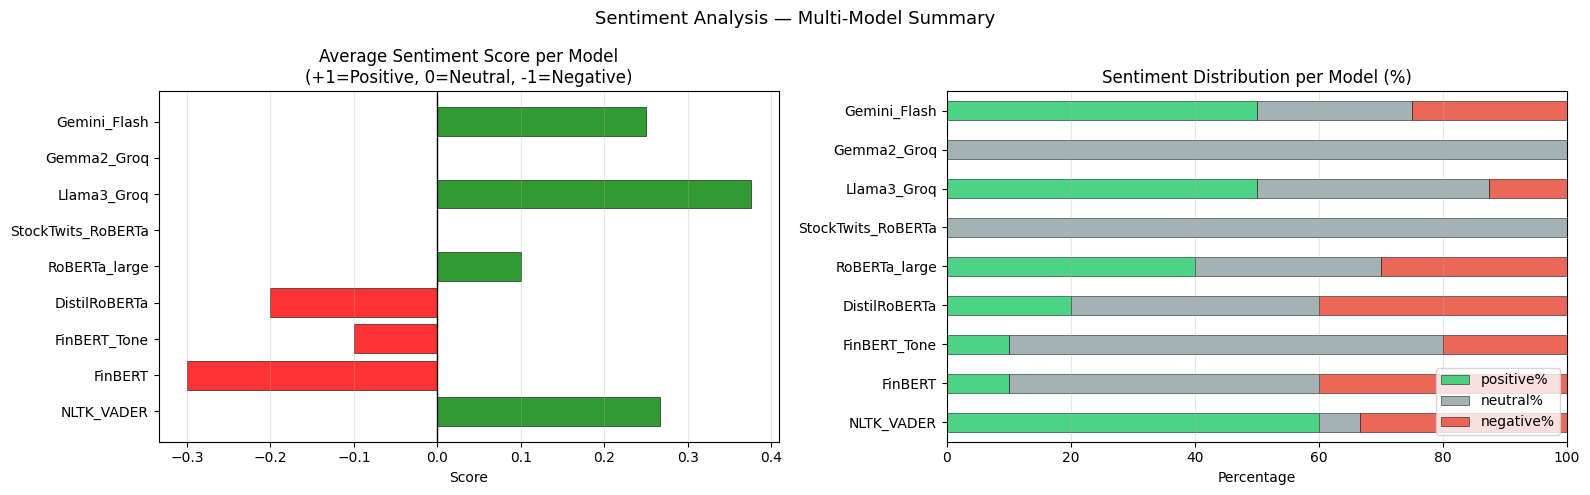

In [167]:
# ── Sentiment Visualizations ─────────────────────────────────────────────────
if not df_sentiment_summary.empty:
    fig_s, axes_s = plt.subplots(1, 2, figsize=(16, 5))
    fig_s.suptitle("Sentiment Analysis — Multi-Model Summary", fontsize=13)

    # Bar: avg score per model
    colors = ['green' if s > 0 else ('red' if s < 0 else 'gray')
              for s in df_sentiment_summary['avg_score']]
    axes_s[0].barh(df_sentiment_summary.index, df_sentiment_summary['avg_score'],
                   color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    axes_s[0].axvline(0, color='black', linewidth=1)
    axes_s[0].set_title("Average Sentiment Score per Model\n(+1=Positive, 0=Neutral, -1=Negative)")
    axes_s[0].set_xlabel("Score")
    axes_s[0].grid(True, axis='x', alpha=0.3)

    # Stacked bar: pos / neu / neg %
    df_sentiment_summary[['positive%','neutral%','negative%']].plot(
        kind='barh', stacked=True, ax=axes_s[1],
        color=['#2ecc71','#95a5a6','#e74c3c'], alpha=0.85, edgecolor='black', linewidth=0.4
    )
    axes_s[1].set_title("Sentiment Distribution per Model (%)")
    axes_s[1].set_xlabel("Percentage")
    axes_s[1].legend(loc='lower right')
    axes_s[1].grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [169]:
# ── Gemini — Deep Investment Thesis ──────────────────────────────────────────
# Uses best available Gemini model from GEMINI_MODELS_LIST (2.5-flash/lite/pro)
def generate_investment_thesis(headlines, sentiment_df, ticker, company):
    if not GEMINI_KEY:
        return "⚠ No GEMINI_KEY set — thesis skipped."

    top_headlines_text = "\n".join(f"- {h}" for h in headlines[:15])
    avg_scores = {}
    if not sentiment_df.empty and 'avg_score' in sentiment_df.columns:
        avg_scores = sentiment_df['avg_score'].to_dict()
    scores_text = "\n".join(f"  {m}: {s:+.3f}" for m, s in avg_scores.items())

    prompt = f"""You are a senior equity research analyst. Based on the following information,
write a concise 200-word investment thesis for {company} ({ticker}).

RECENT NEWS HEADLINES:
{top_headlines_text}

SENTIMENT SCORES FROM AI MODELS (scale -1 to +1):
{scores_text}

ENSEMBLE SENTIMENT: {ensemble_score:.3f}

Instructions:
- Identify the dominant market narrative (positive/negative/mixed)
- Highlight key risks and catalysts
- State whether sentiment supports a BUY, HOLD, or SELL stance
- Keep it factual, concise, and professional
- Do NOT give explicit financial advice disclaimers in the body (add at end only)
"""
    # Try each Gemini model in priority order
    for model_id in GEMINI_MODELS_LIST:
        try:
            if _GENAI_SDK == 'new':
                client = google_genai.Client(api_key=GEMINI_KEY)
                resp   = client.models.generate_content(model=model_id, contents=prompt)
                text   = resp.text.strip() if resp.text else ''
            else:
                google_genai.configure(api_key=GEMINI_KEY)
                model_obj = google_genai.GenerativeModel(model_id)
                resp  = model_obj.generate_content(prompt)
                text  = resp.text.strip() if resp.text else ''
            if text:
                print(f"  → Model used: {model_id}")
                return text
        except Exception as e:
            err = str(e).lower()
            if '429' in err or 'quota' in err or 'exhausted' in err:
                continue
            return f"Thesis generation failed ({model_id}): {e}"
    return "⚠ All Gemini models quota-exhausted — thesis skipped. (Gemini free tier: 50 req/day)"

top_news_titles  = df_news['title'].dropna().head(15).tolist()
print("Generating investment thesis (Gemini)…")
investment_thesis = generate_investment_thesis(
    top_news_titles, df_sentiment_summary, TICKER, company_name
)

print("\n" + "═" * 70)
print(f"  INVESTMENT THESIS — {company_name} ({TICKER})")
print("═" * 70)
print(investment_thesis)
print("═" * 70)


Generating investment thesis (Gemini)…
  → Model used: gemini-2.5-flash

══════════════════════════════════════════════════════════════════════
  INVESTMENT THESIS — Hindustan Aeronautics Limited (HAL.NS)
══════════════════════════════════════════════════════════════════════
**Investment Thesis: Hindustan Aeronautics Limited (HAL.NS)**

Hindustan Aeronautics Limited (HAL) presents a mixed market narrative, balancing strategic strengths with emerging competitive pressures. Recent headlines indicate continued analyst interest, with a 12-month price target cut, yet still implying an 18% upside, suggesting underlying value. Catalysts include strong demand for indigenous defense platforms like the Tejas fighter and Light Combat Helicopter (LCH), further solidified by experienced leadership appointments and ongoing program investments, such as the $63M avionics contract for the LCH program.

However, key risks temper this optimism. The price target cut itself signals some re-evaluation by an

# Section 9 — Price Forecasting (LSTM + Transformer)
Two models are trained on the last 2 years of close prices:
- **LSTM** — sequential memory network, good at capturing local patterns
- **Temporal Transformer** — self-attention based, better for long-range dependencies

Both use CPU-friendly architectures that run without a GPU.

In [170]:
# ── Prepare sequences for deep learning ──────────────────────────────────────
FORECAST_DAYS = 30    # How many days to predict ahead
SEQ_LEN       = 60    # Look-back window
EPOCHS        = 50
BATCH_SIZE    = 32
HIDDEN_SIZE   = 64
N_LAYERS      = 2

# Use close price only (+ RSI + MACD_Hist as additional features)
feature_cols = ['Close', 'RSI', 'MACD_Hist', 'ATR', 'BB_Pct']
feat_df = df[feature_cols].dropna()

# Scale
scaler_close = MinMaxScaler()
scaler_feat  = MinMaxScaler()
feat_scaled  = scaler_feat.fit_transform(feat_df.values)
close_scaled = scaler_close.fit_transform(feat_df[['Close']].values)

def make_sequences(features, targets, seq_len):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i-seq_len:i])
        y.append(targets[i, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = make_sequences(feat_scaled, close_scaled, SEQ_LEN)

# Train / test split (80/20, no shuffle for time-series)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_t = torch.tensor(X_train)
X_test_t  = torch.tensor(X_test)
y_train_t = torch.tensor(y_train).unsqueeze(1)
y_test_t  = torch.tensor(y_test).unsqueeze(1)

N_FEATURES = X_train.shape[2]
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)} | Features: {N_FEATURES}")

Train samples: 324 | Test samples: 81 | Features: 5


In [171]:
# ── LSTM Model ────────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden_size, n_layers, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, n_layers,
                            batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.fc   = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def train_model(model, X_tr, y_tr, epochs=EPOCHS, lr=1e-3, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    losses = []
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        pred = model(X_tr)
        loss = criterion(pred, y_tr)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())
        if verbose and epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{epochs} | Loss: {loss.item():.6f}")
    return losses

print("Training LSTM…")
lstm_model = LSTMModel(N_FEATURES, HIDDEN_SIZE, N_LAYERS)
lstm_losses = train_model(lstm_model, X_train_t, y_train_t, EPOCHS, verbose=True)
print("LSTM training complete.")

Training LSTM…
  Epoch  10/50 | Loss: 0.184788
  Epoch  20/50 | Loss: 0.068267
  Epoch  30/50 | Loss: 0.042747
  Epoch  40/50 | Loss: 0.042904
  Epoch  50/50 | Loss: 0.037696
LSTM training complete.


In [172]:
# ── Temporal Transformer Model ────────────────────────────────────────────────
class TemporalTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        enc_layer       = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=128,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x   = self.input_proj(x)           # (B, T, d_model)
        x   = self.transformer(x)          # (B, T, d_model)
        out = self.fc(x[:, -1, :])         # take last timestep
        return out

print("Training Transformer…")
trans_model  = TemporalTransformer(N_FEATURES, d_model=64, nhead=4, n_layers=2)
trans_losses = train_model(trans_model, X_train_t, y_train_t, EPOCHS, lr=5e-4, verbose=True)
print("Transformer training complete.")

Training Transformer…
  Epoch  10/50 | Loss: 0.045083
  Epoch  20/50 | Loss: 0.031805
  Epoch  30/50 | Loss: 0.014393
  Epoch  40/50 | Loss: 0.012830
  Epoch  50/50 | Loss: 0.011564
Transformer training complete.


In [173]:
# ── Evaluate on test set ─────────────────────────────────────────────────────
def evaluate_model(model, X_test_t, y_test_t, scaler):
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).numpy()
    preds_inv = scaler.inverse_transform(preds)
    actuals   = scaler.inverse_transform(y_test_t.numpy())
    mae  = mean_absolute_error(actuals, preds_inv)
    rmse = np.sqrt(mean_squared_error(actuals, preds_inv))
    mape = np.mean(np.abs((actuals - preds_inv) / actuals)) * 100
    return preds_inv.flatten(), actuals.flatten(), mae, rmse, mape

lstm_preds, actuals, lstm_mae, lstm_rmse, lstm_mape = evaluate_model(
    lstm_model, X_test_t, y_test_t, scaler_close)
trans_preds, _, trans_mae, trans_rmse, trans_mape = evaluate_model(
    trans_model, X_test_t, y_test_t, scaler_close)

print("=== Model Evaluation on Test Set ===")
eval_df = pd.DataFrame({
    "Model"  : ["LSTM", "Transformer"],
    "MAE"    : [f"{lstm_mae:.2f}", f"{trans_mae:.2f}"],
    "RMSE"   : [f"{lstm_rmse:.2f}", f"{trans_rmse:.2f}"],
    "MAPE %" : [f"{lstm_mape:.2f}%", f"{trans_mape:.2f}%"],
})
display(eval_df.set_index("Model"))

=== Model Evaluation on Test Set ===


,MAE,RMSE,MAPE %
Model,,,
LSTM,218.16,273.90,5.48%
Transformer,78.39,97.46,1.89%


In [174]:
# ── Future forecasting (next FORECAST_DAYS days) ─────────────────────────────
def forecast_future(model, feat_scaled, seq_len, n_future, scaler):
    model.eval()
    last_seq = feat_scaled[-seq_len:].copy()
    preds = []
    with torch.no_grad():
        for _ in range(n_future):
            inp  = torch.tensor(last_seq[np.newaxis, :, :], dtype=torch.float32)
            pred = model(inp).item()
            preds.append(pred)
            # Roll forward: shift and append (only close=col0 changes)
            new_row     = last_seq[-1].copy()
            new_row[0]  = pred   # update normalised close
            last_seq    = np.vstack([last_seq[1:], new_row])
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

import pandas.tseries.offsets as offsets
last_date     = feat_df.index[-1]
future_dates  = pd.bdate_range(start=last_date + offsets.BDay(1), periods=FORECAST_DAYS)

lstm_future  = forecast_future(lstm_model,  feat_scaled, SEQ_LEN, FORECAST_DAYS, scaler_close)
trans_future = forecast_future(trans_model, feat_scaled, SEQ_LEN, FORECAST_DAYS, scaler_close)

# Ensemble forecast (simple average)
ensemble_future = (lstm_future + trans_future) / 2

print(f"Current price     : {CURRENCY_SYM}{close.iloc[-1]:.2f}")
print(f"LSTM 30d forecast : {CURRENCY_SYM}{lstm_future[-1]:.2f}  ({(lstm_future[-1]/close.iloc[-1]-1)*100:+.1f}%)")
print(f"Transformer 30d   : {CURRENCY_SYM}{trans_future[-1]:.2f}  ({(trans_future[-1]/close.iloc[-1]-1)*100:+.1f}%)")
print(f"Ensemble 30d      : {CURRENCY_SYM}{ensemble_future[-1]:.2f}  ({(ensemble_future[-1]/close.iloc[-1]-1)*100:+.1f}%)")

Current price     : ₹4303.80
LSTM 30d forecast : ₹4277.02  (-0.6%)
Transformer 30d   : ₹4403.68  (+2.3%)
Ensemble 30d      : ₹4340.35  (+0.8%)


In [175]:
# ── Forecast Visualization ────────────────────────────────────────────────────
historical_window = close[close.index >= close.index[-1] - pd.DateOffset(months=6)]

fig_fc = go.Figure()

# Historical price
fig_fc.add_trace(go.Scatter(
    x=historical_window.index, y=historical_window.values,
    name='Historical Close', line=dict(color='white', width=2)
))

# Test predictions (overlay on historical)
test_idx = feat_df.index[SEQ_LEN + split:]
if len(test_idx) == len(lstm_preds):
    fig_fc.add_trace(go.Scatter(
        x=test_idx, y=lstm_preds, name='LSTM (test)',
        line=dict(color='cyan', width=1.5, dash='dot')
    ))
    fig_fc.add_trace(go.Scatter(
        x=test_idx, y=trans_preds, name='Transformer (test)',
        line=dict(color='yellow', width=1.5, dash='dot')
    ))

# Future forecasts
fig_fc.add_trace(go.Scatter(
    x=future_dates, y=lstm_future, name=f'LSTM Forecast ({FORECAST_DAYS}d)',
    line=dict(color='#00bcd4', width=2, dash='dash')
))
fig_fc.add_trace(go.Scatter(
    x=future_dates, y=trans_future, name=f'Transformer Forecast ({FORECAST_DAYS}d)',
    line=dict(color='#ffeb3b', width=2, dash='dash')
))
fig_fc.add_trace(go.Scatter(
    x=future_dates, y=ensemble_future, name='Ensemble Forecast',
    line=dict(color='#ff9800', width=3)
))

# Shaded forecast region
fig_fc.add_vrect(
    x0=str(future_dates[0].date()), x1=str(future_dates[-1].date()),
    fillcolor="rgba(100,100,255,0.06)", line_width=0
)

fig_fc.update_layout(
    title=f"<b>{company_name}</b> — Price Forecast (LSTM + Transformer)",
    yaxis_title=f"Price ({currency})",
    template='plotly_dark', height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig_fc.show()


## 9.5 — Monte Carlo Price Simulation (GBM — 1 000 paths)
> Geometric Brownian Motion parameterised by historical μ and σ.  
> Provides **probabilistic** price ranges — complementing the LSTM/Transformer point-forecasts.


=== Monte Carlo Simulation  (1,000 paths · 30-day horizon) ===
  Starting Price     : ₹4303.80
  Annualised Drift   : -7.03%
  Annualised Volatility: 35.92%

  ── Terminal Price Distribution (30 days) ──
      5th pct : ₹  3443.36   ▼19.99%  █████████
     10th pct : ₹  3593.55   ▼16.50%  ████████
     25th pct : ₹  3912.12   ▼9.10%  ████
     50th pct : ₹  4238.75   ▼1.51%  
     75th pct : ₹  4620.82   ▲7.37%  ███
     90th pct : ₹  4974.42   ▲15.58%  ███████
     95th pct : ₹  5191.61   ▲20.63%  ██████████

  P(profit in 30d)       : 44.9%
  P(gain  > +5%)        : 30.4%
  P(gain  > +10%)       : 18.6%
  P(loss  < -5%)        : 38.0%
  P(loss  < -10%)       : 23.0%

  Ensemble DL forecast  : ₹4340.35  (+0.85%)
  MC Median (50th pct)  : ₹4238.75  (-1.51%)


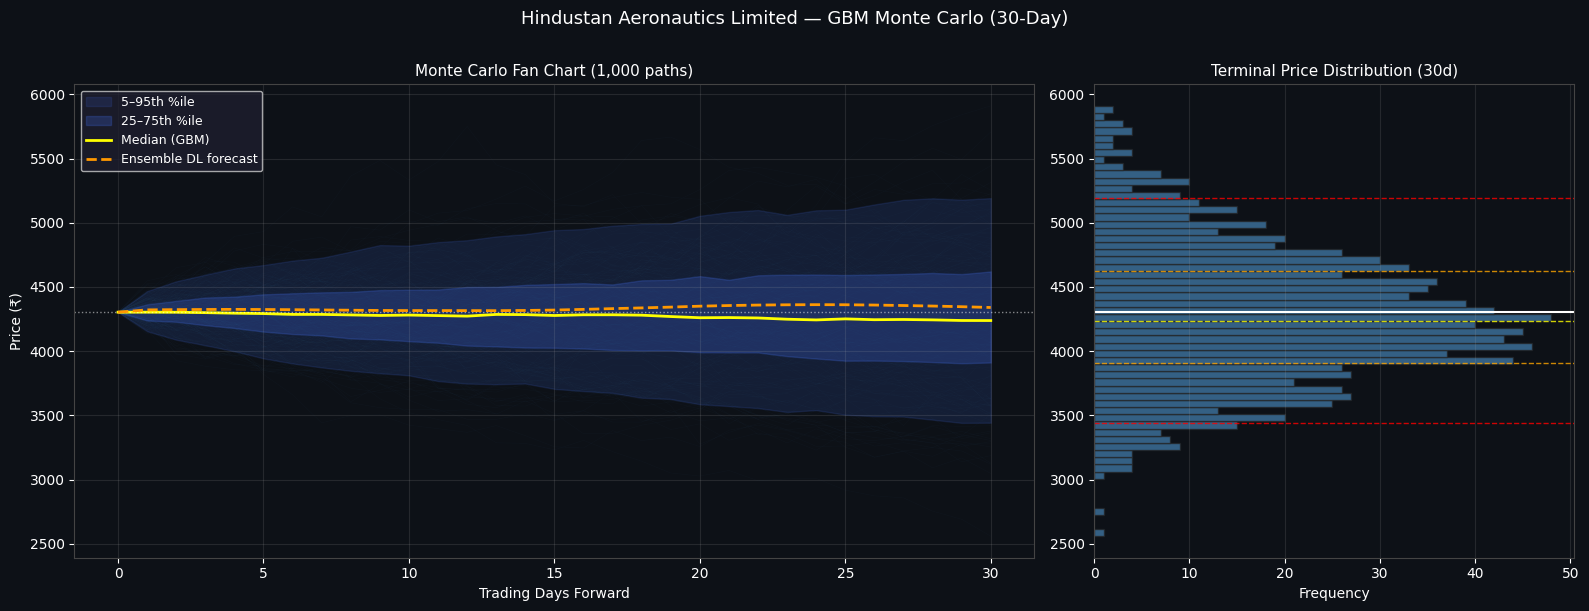

In [177]:
# ── Monte Carlo Price Simulation (Geometric Brownian Motion) ─────────────────
np.random.seed(42)
MC_SIMS = 1000
MC_DAYS = FORECAST_DAYS    # matches existing 30-day forecast horizon

# Calibrate GBM parameters from historical log returns
log_rets   = np.log(close / close.shift(1)).dropna()
mu_daily   = log_rets.mean()
sig_daily  = log_rets.std()
S0         = float(close.iloc[-1])

# Simulate MC_SIMS paths
mc_paths = np.zeros((MC_SIMS, MC_DAYS + 1))
mc_paths[:, 0] = S0
for t in range(1, MC_DAYS + 1):
    Z = np.random.standard_normal(MC_SIMS)
    mc_paths[:, t] = mc_paths[:, t - 1] * np.exp(
        (mu_daily - 0.5 * sig_daily ** 2) + sig_daily * Z
    )

terminal = mc_paths[:, -1]
pctiles   = [5, 10, 25, 50, 75, 90, 95]
pct_vals  = {p: np.percentile(terminal, p) for p in pctiles}

print(f"=== Monte Carlo Simulation  ({MC_SIMS:,} paths · {MC_DAYS}-day horizon) ===")
print(f"  Starting Price     : {CURRENCY_SYM}{S0:.2f}")
print(f"  Annualised Drift   : {mu_daily * 252:.2%}")
print(f"  Annualised Volatility: {sig_daily * 252**0.5:.2%}")
print()
print(f"  ── Terminal Price Distribution ({'30 days' if MC_DAYS == 30 else f'{MC_DAYS}d'}) ──")
for p in pctiles:
    ret_pct = (pct_vals[p] / S0 - 1) * 100
    bar     = '█' * max(0, int(abs(ret_pct) / 2))
    sign    = '▲' if ret_pct >= 0 else '▼'
    print(f"    {p:3d}th pct : {CURRENCY_SYM}{pct_vals[p]:9.2f}   {sign}{abs(ret_pct):.2f}%  {bar}")

print()
print(f"  P(profit in {MC_DAYS}d)       : {(terminal > S0).mean():.1%}")
print(f"  P(gain  > +5%)        : {(terminal > S0 * 1.05).mean():.1%}")
print(f"  P(gain  > +10%)       : {(terminal > S0 * 1.10).mean():.1%}")
print(f"  P(loss  < -5%)        : {(terminal < S0 * 0.95).mean():.1%}")
print(f"  P(loss  < -10%)       : {(terminal < S0 * 0.90).mean():.1%}")
print(f"\n  Ensemble DL forecast  : {CURRENCY_SYM}{ensemble_future[-1]:.2f}  "
      f"({(ensemble_future[-1]/S0 - 1)*100:+.2f}%)")
print(f"  MC Median (50th pct)  : {CURRENCY_SYM}{pct_vals[50]:.2f}  "
      f"({(pct_vals[50]/S0 - 1)*100:+.2f}%)")

# ── Plot ───────────────────────────────────────────────────────────────────────
_mc_x = np.arange(MC_DAYS + 1)    # 0, 1, …, MC_DAYS  (31 points)

# Ensemble forecast: prepend S0 (day 0) so it aligns with _mc_x (31 points)
_ens_full = np.concatenate([[S0], ensemble_future])[:MC_DAYS + 1]

fig_mc, (ax_mc, ax_dist) = plt.subplots(1, 2, figsize=(16, 6),
                                         gridspec_kw={'width_ratios': [2, 1]})
fig_mc.patch.set_facecolor('#0d1117')

# Left panel: fan chart
ax_mc.set_facecolor('#0d1117')
for i in np.random.choice(MC_SIMS, 150, replace=False):
    ax_mc.plot(_mc_x, mc_paths[i], color='steelblue', alpha=0.03, linewidth=0.5)

pct_arr = {p: np.percentile(mc_paths, p, axis=0) for p in [5, 25, 50, 75, 95]}
ax_mc.fill_between(_mc_x, pct_arr[5],  pct_arr[95], alpha=0.15, color='royalblue', label='5–95th %ile')
ax_mc.fill_between(_mc_x, pct_arr[25], pct_arr[75], alpha=0.25, color='royalblue', label='25–75th %ile')
ax_mc.plot(_mc_x, pct_arr[50], color='yellow', linewidth=2.0, label='Median (GBM)')
ax_mc.plot(_mc_x, _ens_full, color='#ff9800', linewidth=2.0, linestyle='--',
           label='Ensemble DL forecast', zorder=5)
ax_mc.axhline(S0, color='white', linestyle=':', linewidth=1, alpha=0.5)
ax_mc.set_title(f"Monte Carlo Fan Chart ({MC_SIMS:,} paths)", color='white', fontsize=11)
ax_mc.set_xlabel("Trading Days Forward", color='white')
ax_mc.set_ylabel(f"Price ({CURRENCY_SYM})", color='white')
ax_mc.tick_params(colors='white')
for sp in ax_mc.spines.values(): sp.set_color('#444')
ax_mc.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=9)
ax_mc.grid(True, alpha=0.15)

# Right panel: terminal price distribution histogram
ax_dist.set_facecolor('#0d1117')
ax_dist.hist(terminal, bins=60, color='steelblue', alpha=0.7, edgecolor='#222', orientation='horizontal')
for p, col in [(5, 'red'), (25, 'orange'), (50, 'yellow'), (75, 'orange'), (95, 'red')]:
    ax_dist.axhline(pct_vals[p], color=col, linewidth=1, linestyle='--', alpha=0.8)
ax_dist.axhline(S0, color='white', linewidth=1.5, linestyle='-', label='Entry price')
ax_dist.set_title(f"Terminal Price Distribution ({MC_DAYS}d)", color='white', fontsize=11)
ax_dist.set_xlabel("Frequency", color='white')
ax_dist.tick_params(colors='white')
for sp in ax_dist.spines.values(): sp.set_color('#444')
ax_dist.grid(True, alpha=0.15, axis='x')

plt.suptitle(f"{company_name} — GBM Monte Carlo ({MC_DAYS}-Day)", color='white',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# Section 10 — Correlation, Feature Importance & Final Buy/Hold/Sell Signal
## 10.1 — Technical Indicator Correlation Heatmap

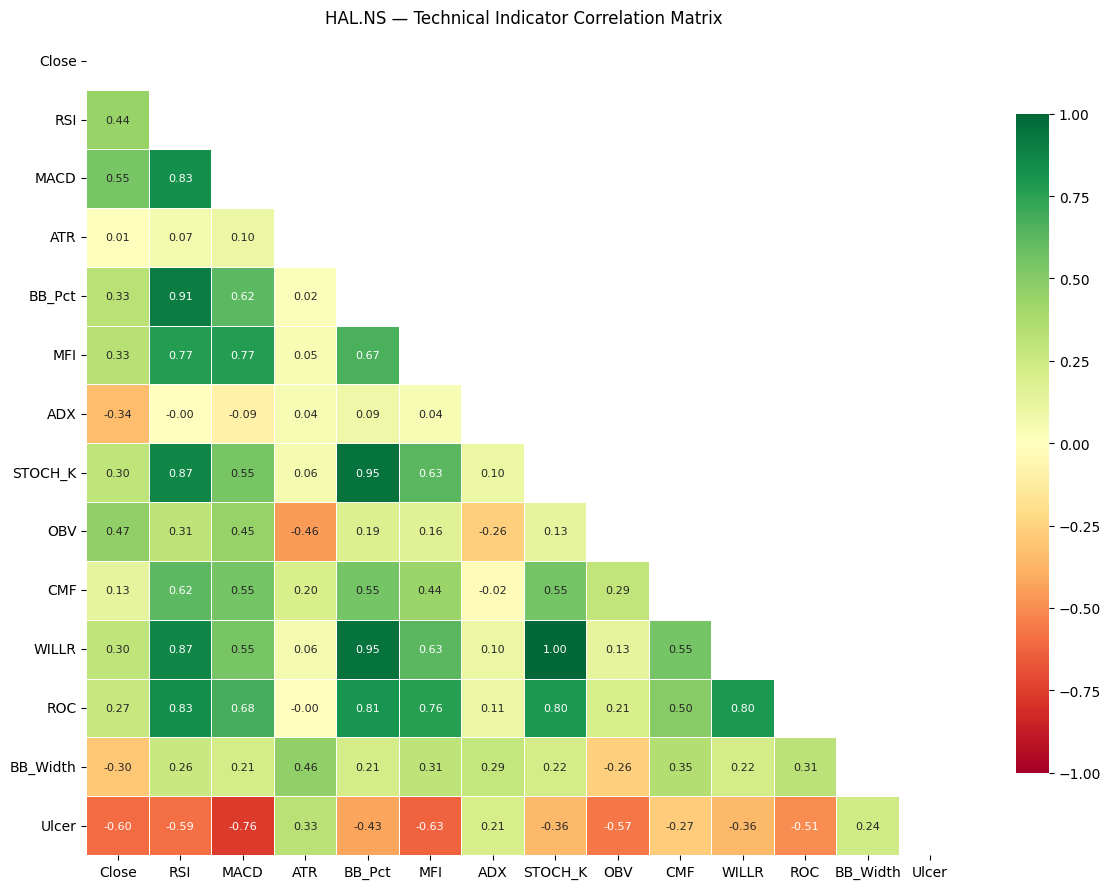

In [178]:
# ── Correlation heatmap of technical indicators ───────────────────────────────
corr_cols = ['Close', 'RSI', 'MACD', 'ATR', 'BB_Pct', 'MFI', 'ADX',
             'STOCH_K', 'OBV', 'CMF', 'WILLR', 'ROC', 'BB_Width', 'Ulcer']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_df = df[corr_cols].dropna().corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
plt.title(f"{TICKER} — Technical Indicator Correlation Matrix", fontsize=12)
plt.tight_layout()
plt.show()

## 10.2 — Feature Importance (Random Forest → next-day returns)

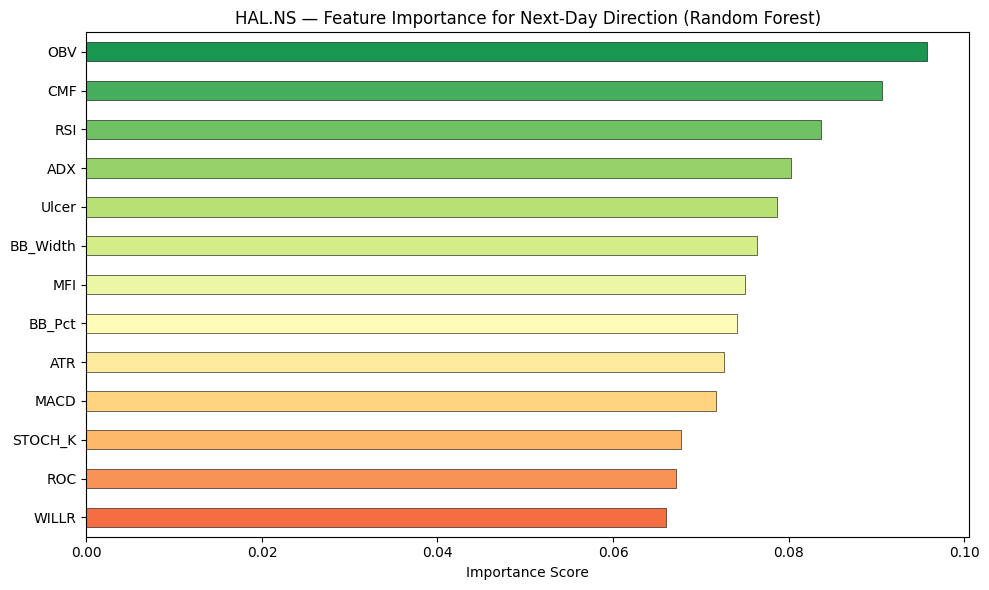

Top 5 predictive features:
  OBV                  0.0958
  CMF                  0.0907
  RSI                  0.0837
  ADX                  0.0803
  Ulcer                0.0786


In [179]:
from sklearn.ensemble import RandomForestClassifier

feat_imp_cols = [c for c in corr_cols if c != 'Close']
ml_df = df[feat_imp_cols + ['Close']].dropna().copy()

# Target: next day return sign (+1 / 0 / -1)
ml_df['next_return'] = ml_df['Close'].pct_change().shift(-1)
ml_df['target']      = (ml_df['next_return'] > 0).astype(int)
ml_df.dropna(inplace=True)

X_ml = ml_df[feat_imp_cols].values
y_ml = ml_df['target'].values

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_ml, y_ml)

feat_imp = pd.Series(rf.feature_importances_, index=feat_imp_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.4)
plt.title(f"{TICKER} — Feature Importance for Next-Day Direction (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 5 predictive features:")
for f, v in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {f:<20} {v:.4f}")

## 10.3 — Final BUY / HOLD / SELL Signal Engine
Each pillar (Fundamental, Technical, Sentiment, Forecast) contributes a sub-score from -1 to +1.
Final score is a weighted ensemble → mapped to BUY / HOLD / SELL.

In [180]:
# ════════════════════════════════════════════════════════════════════════════
#  PILLAR 1: FUNDAMENTAL SCORE  (−1 to +1)
# ════════════════════════════════════════════════════════════════════════════
def fundamental_score(info_d, piotroski, z_score):
    scores = []
    # Valuation
    pe = info_d.get('trailingPE')
    if pe:
        scores.append(0.5 if pe < 15 else (-0.5 if pe > 40 else 0))
    pb = info_d.get('priceToBook')
    if pb:
        scores.append(0.5 if pb < 1.5 else (-0.5 if pb > 5 else 0))
    # Profitability
    roe = info_d.get('returnOnEquity', 0)
    if roe:
        scores.append(1 if roe > 0.20 else (0.5 if roe > 0.10 else (-0.5 if roe < 0 else 0)))
    npm = info_d.get('profitMargins', 0)
    if npm:
        scores.append(1 if npm > 0.20 else (0.5 if npm > 0.05 else (-0.5 if npm < 0 else 0)))
    # Piotroski (0-9 → -1 to +1)
    pf_norm = (piotroski / 9) * 2 - 1
    scores.append(pf_norm)
    # Altman Z
    if not np.isnan(z_score):
        scores.append(1 if z_score > 2.99 else (-1 if z_score < 1.81 else 0))
    # Debt
    de = info_d.get('debtToEquity')
    if de is not None:
        scores.append(0.5 if de < 0.5 else (-0.5 if de > 2 else 0))
    # Growth
    rg = info_d.get('revenueGrowth', 0)
    if rg:
        scores.append(1 if rg > 0.20 else (0.5 if rg > 0.05 else (-0.5 if rg < 0 else 0)))

    return np.mean(scores) if scores else 0

fund_score = fundamental_score(info, piotroski_score, altman_z)
print(f"  Fundamental Score : {fund_score:+.3f}")

# ════════════════════════════════════════════════════════════════════════════
#  PILLAR 2: TECHNICAL SCORE  (−1 to +1)
# ════════════════════════════════════════════════════════════════════════════
def technical_score(df_tech):
    latest = df_tech.iloc[-1]
    scores = []
    # RSI
    rsi = latest.get('RSI')
    if rsi and not np.isnan(rsi):
        scores.append(-1 if rsi > 70 else (1 if rsi < 30 else (0.5 if rsi < 50 else -0.5)))
    # MACD
    macd = latest.get('MACD'); sig = latest.get('MACD_Sig')
    if macd is not None and sig is not None and not np.isnan(macd):
        scores.append(1 if macd > sig else -1)
    # EMA trend
    e20 = latest.get('EMA_20'); e50 = latest.get('EMA_50')
    if e20 and e50:
        scores.append(1 if e20 > e50 else -1)
    # Price vs SMA200
    sma200 = latest.get('SMA_200'); price = latest.get('Close')
    if sma200 and price:
        scores.append(1 if price > sma200 else -1)
    # ADX (trend strength — not direction)
    adx = latest.get('ADX')
    if adx and not np.isnan(adx):
        scores.append(0.5 if adx > 25 else 0)   # Strong trend is a mild positive
    # BB position
    bb_pct = latest.get('BB_Pct')
    if bb_pct is not None and not np.isnan(bb_pct):
        scores.append(-1 if bb_pct > 0.95 else (1 if bb_pct < 0.05 else 0))
    # MFI
    mfi = latest.get('MFI')
    if mfi and not np.isnan(mfi):
        scores.append(-1 if mfi > 80 else (1 if mfi < 20 else 0))
    # Williams %R
    willr = latest.get('WILLR')
    if willr and not np.isnan(willr):
        scores.append(1 if willr < -80 else (-1 if willr > -20 else 0))

    return np.mean(scores) if scores else 0

tech_score = technical_score(df)
print(f"  Technical Score   : {tech_score:+.3f}")

# ════════════════════════════════════════════════════════════════════════════
#  PILLAR 3: SENTIMENT SCORE  (from ensemble_score, already −1 to +1)
# ════════════════════════════════════════════════════════════════════════════
sent_score = ensemble_score if not np.isnan(ensemble_score) else 0
print(f"  Sentiment Score   : {sent_score:+.3f}")

# ════════════════════════════════════════════════════════════════════════════
#  PILLAR 4: FORECAST SCORE  (30d predicted change → normalised)
# ════════════════════════════════════════════════════════════════════════════
forecast_return = (ensemble_future[-1] / close.iloc[-1]) - 1
forecast_score  = np.clip(forecast_return * 5, -1, 1)   # 20% up → +1; 20% down → -1
print(f"  Forecast Score    : {forecast_score:+.3f}  (30d expected: {forecast_return:+.1%})")

  Fundamental Score : +0.389
  Technical Score   : -0.062
  Sentiment Score   : +0.044
  Forecast Score    : +0.042  (30d expected: +0.8%)


In [181]:
# ── Weighted Ensemble → Final Signal ─────────────────────────────────────────
WEIGHTS = {
    'Fundamental' : 0.30,
    'Technical'   : 0.30,
    'Sentiment'   : 0.20,
    'Forecast'    : 0.20,
}

pillar_scores = {
    'Fundamental' : fund_score,
    'Technical'   : tech_score,
    'Sentiment'   : sent_score,
    'Forecast'    : forecast_score,
}

final_score = sum(pillar_scores[k] * WEIGHTS[k] for k in WEIGHTS)

# Map score to signal
if   final_score >=  0.20:
    signal = "BUY 🟢";  signal_color = "green"
elif final_score <= -0.20:
    signal = "SELL 🔴"; signal_color = "red"
else:
    signal = "HOLD 🟡"; signal_color = "goldenrod"

# Confidence (distance from nearest threshold)
confidence = min(abs(final_score - 0.20), abs(final_score + 0.20))
confidence_pct = round(min((abs(final_score) / 1.0) * 100, 100), 1)

print("\n" + "═" * 60)
print(f"  FINAL SIGNAL:  {signal}")
print(f"  Composite Score: {final_score:+.4f}  |  Confidence: {confidence_pct:.1f}%")
print("═" * 60)
for k, v in pillar_scores.items():
    bar = "█" * int(abs(v) * 10) + "░" * (10 - int(abs(v) * 10))
    dir_sym = "▲" if v > 0 else ("▼" if v < 0 else "─")
    print(f"  {k:<16} {dir_sym} {v:+.3f}  [{bar}]  (weight {WEIGHTS[k]:.0%})")
print("═" * 60)


════════════════════════════════════════════════════════════
  FINAL SIGNAL:  HOLD 🟡
  Composite Score: +0.1151  |  Confidence: 11.5%
════════════════════════════════════════════════════════════
  Fundamental      ▲ +0.389  [███░░░░░░░]  (weight 30%)
  Technical        ▼ -0.062  [░░░░░░░░░░]  (weight 30%)
  Sentiment        ▲ +0.044  [░░░░░░░░░░]  (weight 20%)
  Forecast         ▲ +0.042  [░░░░░░░░░░]  (weight 20%)
════════════════════════════════════════════════════════════


In [190]:
# ── Signal Engine — Plotly Gauge + Pillar Bar ─────────────────────────────────
fig_sig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'indicator'}, {'type': 'bar'}]],
    subplot_titles=['Composite Score Gauge', 'Pillar Breakdown'],
    column_widths=[0.42, 0.58]
)

# ── Gauge ─────────────────────────────────────────────────────────────────────
fig_sig.add_trace(go.Indicator(
    mode  = "gauge+number+delta",
    value = round(final_score * 100, 1),
    title = {'text': f"<b>{signal}</b>", 'font': {'size': 22}},
    delta = {'reference': 0},
    domain= {'row': 0, 'column': 0},
    gauge = {
        'axis'  : {'range': [-100, 100], 'tickwidth': 1},
        'bar'   : {'color': signal_color},
        'steps' : [
            {'range': [-100, -20], 'color': '#c62828'},
            {'range': [-20,   20], 'color': '#f9a825'},
            {'range': [ 20,  100], 'color': '#2e7d32'},
        ],
        'threshold': {
            'line' : {'color': "white", 'width': 3},
            'thickness': 0.75,
            'value': final_score * 100
        }
    }
), row=1, col=1)

# ── Pillar Bars ───────────────────────────────────────────────────────────────
_pillar_names = list(pillar_scores.keys())
_pillar_vals  = [v * 100 for v in pillar_scores.values()]
_bar_colors   = ['#4caf50' if v >= 0 else '#f44336' for v in _pillar_vals]

fig_sig.add_trace(go.Bar(
    x            = _pillar_names,
    y            = _pillar_vals,
    marker_color = _bar_colors,
    marker_line  = dict(color='white', width=0.5),
    text         = [f"{v:+.1f}" for v in _pillar_vals],
    textposition = 'outside',
    textfont     = dict(size=14, color='white', family='Arial Black'),
    showlegend   = False,
), row=1, col=2)

fig_sig.update_yaxes(range=[-130, 130], title_text="Score (−100 to +100)",
                     title_font=dict(size=11), row=1, col=2)
fig_sig.update_xaxes(tickfont=dict(size=12), row=1, col=2)

# ── Threshold lines: exclude_empty_subplots=False avoids Plotly Indicator bug ─
for _y, _col, _dash in [(20, '#4caf50', 'dot'), (-20, '#f44336', 'dot'), (0, 'white', 'solid')]:
    fig_sig.add_hline(y=_y, line_color=_col, line_dash=_dash, line_width=1.5,
                      opacity=0.6, row=1, col=2, exclude_empty_subplots=False)

# ── Weight annotations below each bar ─────────────────────────────────────────
for _k, _w in WEIGHTS.items():
    fig_sig.add_annotation(
        x=_k, y=-118,
        text=f"w={_w:.0%}",
        showarrow=False,
        font=dict(size=10, color='#aaaaaa'),
        xref='x2', yref='y2'
    )

fig_sig.update_layout(
    title_text    = f"<b>SENTRAL Signal Engine — {TICKER}</b>",
    title_font    = dict(size=14),
    template      = 'plotly_dark',
    height        = 460,
    showlegend    = False,
    paper_bgcolor = '#0d1117',
)
fig_sig.show()


## 10.4 — Key Risks & Watchlist

In [183]:
# ── Risk flags ───────────────────────────────────────────────────────────────
risks = []
latest = df.iloc[-1]

rsi_v   = latest.get('RSI', np.nan)
macd_v  = latest.get('MACD', np.nan)
macd_s  = latest.get('MACD_Sig', np.nan)
bb_pct  = latest.get('BB_Pct', np.nan)
adx_v   = latest.get('ADX', np.nan)

if not np.isnan(rsi_v):
    if rsi_v > 70: risks.append(("⚠️  RSI Overbought",  f"RSI = {rsi_v:.1f} (>70)"))
    if rsi_v < 30: risks.append(("⚠️  RSI Oversold",    f"RSI = {rsi_v:.1f} (<30)"))

if not np.isnan(macd_v) and not np.isnan(macd_s):
    if macd_v < macd_s: risks.append(("⚠️  MACD Bearish Cross", f"MACD {macd_v:.2f} < Signal {macd_s:.2f}"))

if not np.isnan(bb_pct):
    if bb_pct > 0.95: risks.append(("⚠️  Price at Upper BB", f"BB_Pct = {bb_pct:.2f}"))
    if bb_pct < 0.05: risks.append(("⚠️  Price at Lower BB", f"BB_Pct = {bb_pct:.2f}"))

if piotroski_score < 3: risks.append(("⚠️  Weak Fundamentals", f"Piotroski = {piotroski_score}/9"))
if altman_z < 1.81:     risks.append(("🚨  Distress Zone",     f"Altman Z = {altman_z:.2f}"))

de = info.get('debtToEquity')
if de and de > 2: risks.append(("⚠️  High Leverage", f"D/E = {de:.2f}"))

if sent_score < -0.3: risks.append(("⚠️  Negative Sentiment", f"Ensemble = {sent_score:.3f}"))
if forecast_return < -0.10: risks.append(("⚠️  Bearish Forecast", f"30d expected = {forecast_return:+.1%}"))

if risks:
    print("🚩  RISK FLAGS")
    for title, detail in risks:
        print(f"   {title}: {detail}")
else:
    print("✅  No major risk flags detected.")

🚩  RISK FLAGS
   ⚠️  MACD Bearish Cross: MACD 15.17 < Signal 47.74


## 10.5 — Strategy Backtesting
Backtests the technical signal rules on historical data to verify edge before trusting the live signal.

=== HAL.NS — 20-Strategy Backtest (sorted by Sharpe Ratio) ===



,Total Return,CAGR,Sharpe,Max Drawdown,Win Rate,Time in Mkt%
Strategy,,,,,,
ADX Trend Following,+39.9%,+32.7%,1.274,-9.6%,+56.3%,+34.8%
Donchian 20-Day Breakout,+20.4%,+16.9%,1.011,-3.8%,+60.0%,+8.4%
MFI Healthy Zone,+30.5%,+25.2%,0.721,-29.8%,+53.8%,+90.6%
★ Buy & Hold,+28.2%,+23.3%,0.647,-31.2%,+53.1%,+100.0%
RSI Momentum (>50),+22.2%,+18.4%,0.599,-18.9%,+54.1%,+50.5%
Keltner Breakout,+19.9%,+16.6%,0.592,-13.6%,+53.8%,+31.4%
CMF Positive Flow,+19.5%,+16.2%,0.542,-19.2%,+56.4%,+39.8%
Aroon Trend Strength,+18.6%,+15.4%,0.532,-14.5%,+53.8%,+35.5%
EMA+MACD+RSI Composite,+18.7%,+15.5%,0.450,-32.9%,+51.6%,+75.6%



  ★ Best strategy by Sharpe: ADX Trend Following


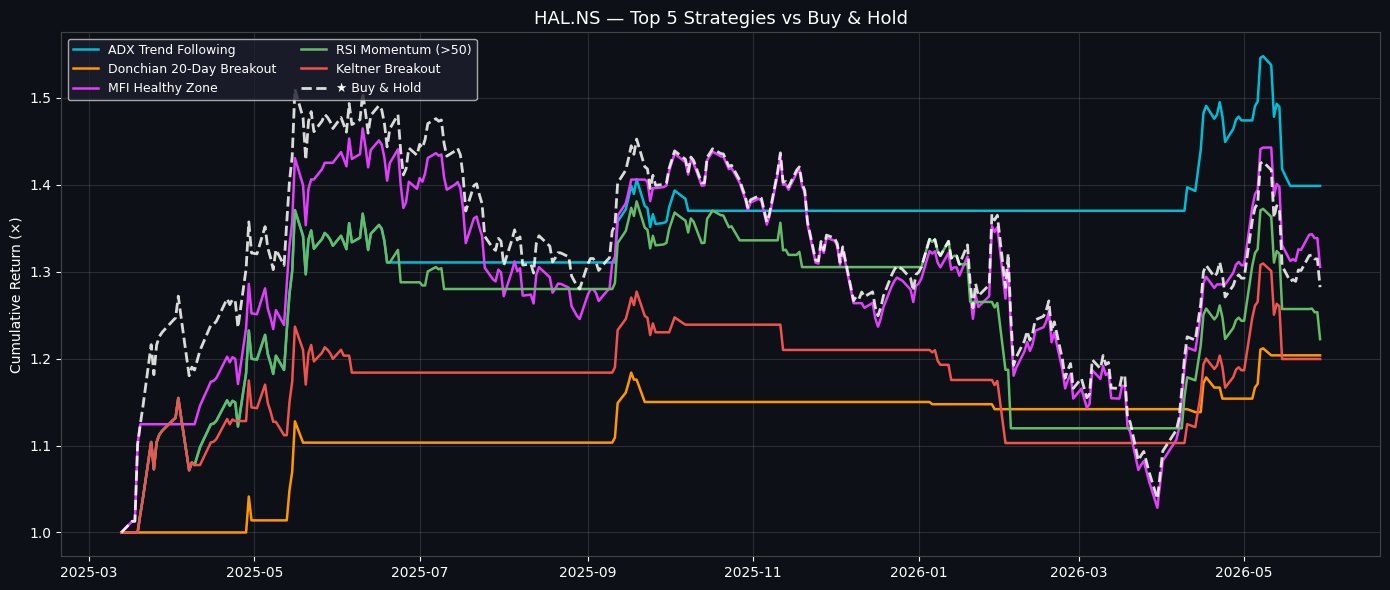

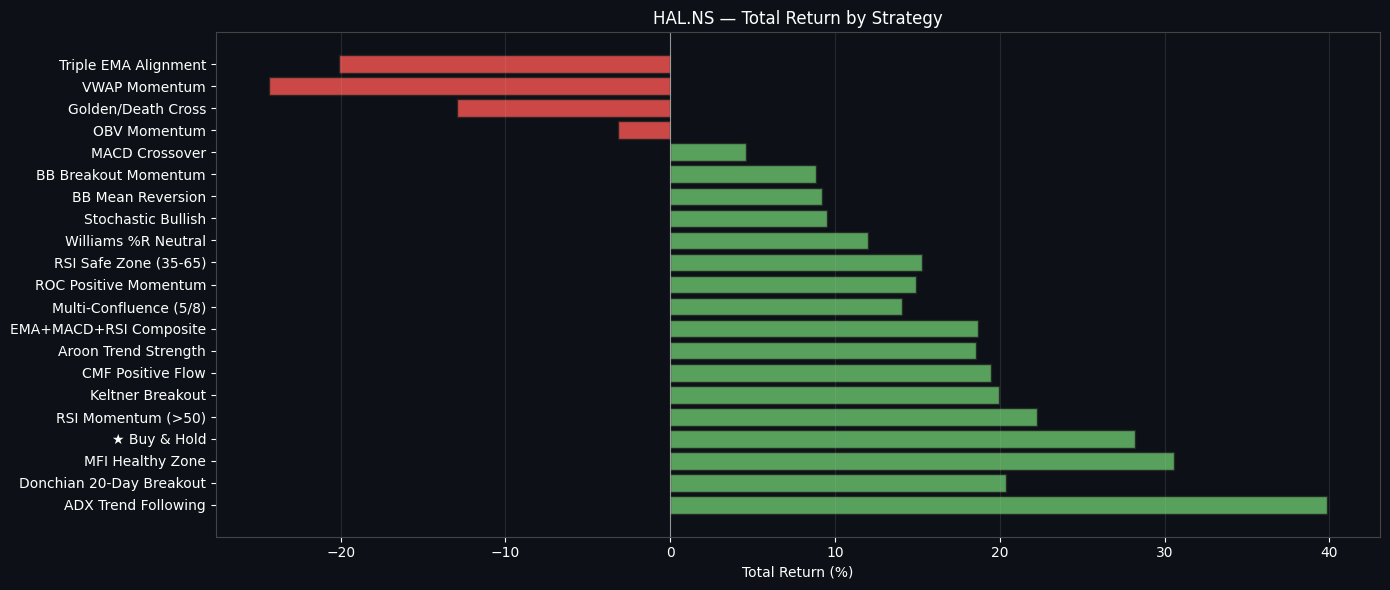

In [184]:
# ── 20-Strategy Backtesting Framework ────────────────────────────────────────
# Each strategy is long-only, signal shifted by 1 bar to avoid look-ahead bias.
# Risk-free rate = 6% annualized (Indian T-bill proxy).
# ─────────────────────────────────────────────────────────────────────────────
_cols_needed = ['Close', 'Open', 'High', 'Low', 'Volume',
                'RSI', 'MACD', 'MACD_Sig', 'EMA_20', 'EMA_50', 'SMA_200', 'SMA_50',
                'ADX', 'DI_Plus', 'DI_Minus', 'AROON_Up', 'AROON_Dn',
                'STOCH_K', 'STOCH_D', 'WILLR', 'ROC', 'MFI',
                'BB_Upper', 'BB_Mid', 'BB_Lower', 'BB_Pct',
                'ATR', 'KC_Upper', 'KC_Mid', 'KC_Lower',
                'Ulcer', 'OBV', 'VWAP', 'CMF']
_bt = df[[c for c in _cols_needed if c in df.columns]].dropna().copy()
_c   = _bt['Close']
_ret = _c.pct_change()

RF_DAILY = 0.06 / 252

def _sharpe(rets):
    exc = rets - RF_DAILY
    return (exc.mean() / exc.std()) * 252 ** 0.5 if exc.std() > 0 else 0.0

def _max_dd(cumul):
    return ((cumul - cumul.cummax()) / cumul.cummax()).min()

def _cagr(cumul, n_days):
    return (cumul.iloc[-1] ** (252 / n_days) - 1) if n_days > 0 else 0.0

def _win_rate(rets):
    r = rets.dropna(); r = r[r != 0]
    return len(r[r > 0]) / len(r) if len(r) > 0 else 0.0

def _backtest(name, sig):
    """Vectorised backtest given a 0/1 signal. Returns stats dict + cumulative series."""
    sig    = sig.reindex(_bt.index).fillna(0)
    strat  = (_ret * sig.shift(1)).fillna(0)
    cumul  = (1 + strat).cumprod()
    n      = len(strat)
    return {
        'Strategy'     : name,
        'Total Return' : cumul.iloc[-1] - 1,
        'CAGR'         : _cagr(cumul, n),
        'Sharpe'       : _sharpe(strat.dropna()),
        'Max Drawdown' : _max_dd(cumul),
        'Win Rate'     : _win_rate(strat),
        'Time in Mkt%' : float(sig.mean()),
        '_cumul'       : cumul,
        '_rets'        : strat,
    }

# ── Pre-compute reusable series ───────────────────────────────────────────────
_obv_sma20    = _bt['OBV'].rolling(20).mean()
_don20_high   = _c.shift(1).rolling(20).max()      # Donchian 20-day high

# ── 20 Strategies ─────────────────────────────────────────────────────────────
# 1. EMA + MACD + RSI Composite (original)
s1  = (((_bt['EMA_20'] > _bt['EMA_50']).astype(int)
      + (_bt['MACD']   > _bt['MACD_Sig']).astype(int)
      + ((_bt['RSI'] > 30) & (_bt['RSI'] < 70)).astype(int)) >= 2).astype(int)

# 2. Golden / Death Cross (SMA 50 vs SMA 200)
s2  = (_bt['SMA_50'] > _bt['SMA_200']).astype(int)

# 3. MACD Crossover (MACD line above signal line)
s3  = (_bt['MACD'] > _bt['MACD_Sig']).astype(int)

# 4. RSI Momentum Zone (RSI > 50 = sustained bullish momentum)
s4  = (_bt['RSI'] > 50).astype(int)

# 5. RSI Safe Zone (avoid extreme readings; trade the middle band)
s5  = ((_bt['RSI'] > 35) & (_bt['RSI'] < 65)).astype(int)

# 6. Bollinger Band Mean Reversion (price in lower quartile → buy the dip)
s6  = (_bt['BB_Pct'] < 0.30).astype(int)

# 7. Bollinger Band Breakout Momentum (price in upper quartile = breakout)
s7  = (_bt['BB_Pct'] > 0.75).astype(int)

# 8. ADX Trend Following (strong trend AND DI+ leading)
s8  = ((_bt['ADX'] > 25) & (_bt['DI_Plus'] > _bt['DI_Minus'])).astype(int)

# 9. Stochastic Bullish Cross (K > D, not in overbought)
s9  = ((_bt['STOCH_K'] > _bt['STOCH_D']) & (_bt['STOCH_K'] < 80)).astype(int)

# 10. Aroon Trend Strength (Up dominates Down and is strong)
s10 = ((_bt['AROON_Up'] > _bt['AROON_Dn']) & (_bt['AROON_Up'] > 60)).astype(int)

# 11. Williams %R Neutral Zone (not in extreme overbought or oversold)
s11 = ((_bt['WILLR'] > -80) & (_bt['WILLR'] < -20)).astype(int)

# 12. CMF Positive Money Flow (net institutional buying)
s12 = (_bt['CMF'] > 0).astype(int)

# 13. OBV Momentum (OBV above its 20-day MA → volume supports trend)
s13 = (_bt['OBV'] > _obv_sma20).astype(int)

# 14. VWAP Momentum (price above VWAP = institutional accumulation)
s14 = (_bt['Close'] > _bt['VWAP']).astype(int)

# 15. MFI Healthy Zone (not overbought; volume-weighted RSI in bullish range)
s15 = ((_bt['MFI'] > 25) & (_bt['MFI'] < 80)).astype(int)

# 16. ROC Positive Momentum (positive rate of change = price trending up)
s16 = (_bt['ROC'] > 0).astype(int)

# 17. Triple EMA Bullish Alignment (all timeframes aligned: 20 > 50 > 200)
s17 = ((_bt['EMA_20'] > _bt['EMA_50']) & (_bt['EMA_50'] > _bt['SMA_200'])).astype(int)

# 18. Donchian Channel 20-Day Breakout (classic turtle-trader entry)
s18 = (_c > _don20_high).astype(int)

# 19. Keltner Channel Breakout (volatility-adjusted momentum)
s19 = (_bt['Close'] > _bt['KC_Upper']).astype(int)

# 20. Multi-Signal Confluence (5+ of 8 independent indicators agree)
_multi_sum = ((_bt['EMA_20'] > _bt['EMA_50']).astype(int)
            + (_bt['MACD'] > _bt['MACD_Sig']).astype(int)
            + (_bt['RSI'] > 50).astype(int)
            + (_bt['ADX'] > 20).astype(int)
            + (_bt['CMF'] > 0).astype(int)
            + (_bt['OBV'] > _obv_sma20).astype(int)
            + (_bt['STOCH_K'] > _bt['STOCH_D']).astype(int)
            + (_bt['Close'] > _bt['VWAP']).astype(int))
s20 = (_multi_sum >= 5).astype(int)

# ── Run all 20 strategies ─────────────────────────────────────────────────────
_strategy_map = {
    'EMA+MACD+RSI Composite'    : s1,
    'Golden/Death Cross'        : s2,
    'MACD Crossover'            : s3,
    'RSI Momentum (>50)'        : s4,
    'RSI Safe Zone (35-65)'     : s5,
    'BB Mean Reversion'         : s6,
    'BB Breakout Momentum'      : s7,
    'ADX Trend Following'       : s8,
    'Stochastic Bullish'        : s9,
    'Aroon Trend Strength'      : s10,
    'Williams %R Neutral'       : s11,
    'CMF Positive Flow'         : s12,
    'OBV Momentum'              : s13,
    'VWAP Momentum'             : s14,
    'MFI Healthy Zone'          : s15,
    'ROC Positive Momentum'     : s16,
    'Triple EMA Alignment'      : s17,
    'Donchian 20-Day Breakout'  : s18,
    'Keltner Breakout'          : s19,
    'Multi-Confluence (5/8)'    : s20,
}

bt_all_results = []
_cumuls        = {}
for name, sig in _strategy_map.items():
    r = _backtest(name, sig)
    _cumuls[name] = r.pop('_cumul')
    _strat_rets_map = {name: r.pop('_rets')}
    bt_all_results.append(r)

# Add Buy & Hold as benchmark
_bh_ret   = _ret.fillna(0)
_bh_cumul = (1 + _bh_ret).cumprod()
bt_all_results.append({
    'Strategy'     : '★ Buy & Hold',
    'Total Return' : _bh_cumul.iloc[-1] - 1,
    'CAGR'         : _cagr(_bh_cumul, len(_bt)),
    'Sharpe'       : _sharpe(_bh_ret.dropna()),
    'Max Drawdown' : _max_dd(_bh_cumul),
    'Win Rate'     : _win_rate(_bh_ret),
    'Time in Mkt%' : 1.0,
})
_cumuls['★ Buy & Hold'] = _bh_cumul

# ── Results table sorted by Sharpe ────────────────────────────────────────────
bt_df_all = pd.DataFrame(bt_all_results).set_index('Strategy')
bt_df_all = bt_df_all.sort_values('Sharpe', ascending=False)

_best_strategy_name = next(s for s in bt_df_all.index if s != '★ Buy & Hold')
_best_sig           = _strategy_map[_best_strategy_name]
# Re-compute best strategy daily returns for Kelly (exported)
strategy_rets = (_ret * _best_sig.reindex(_bt.index).fillna(0).shift(1)).dropna()
backtest_summary = bt_df_all.copy()   # kept for export cell

# Display formatted table
_disp = bt_df_all.copy()
for col in ['Total Return', 'CAGR', 'Max Drawdown', 'Win Rate', 'Time in Mkt%']:
    _disp[col] = _disp[col].apply(lambda x: f"{x:+.1%}")
_disp['Sharpe'] = _disp['Sharpe'].apply(lambda x: f"{x:.3f}")

print(f"=== {TICKER} — 20-Strategy Backtest (sorted by Sharpe Ratio) ===\n")

def _row_style(row):
    if row.name == '★ Buy & Hold':
        return ['background:#1a3a5c;color:gold;font-weight:bold'] * len(row)
    if row.name == _best_strategy_name:
        return ['background:#0d3b26;color:#4ade80;font-weight:bold'] * len(row)
    return [''] * len(row)

display(_disp.style.apply(_row_style, axis=1))
print(f"\n  ★ Best strategy by Sharpe: {_best_strategy_name}")

# ── Equity curve plot — top 5 + Buy & Hold ────────────────────────────────────
_top5 = [s for s in bt_df_all.index if s != '★ Buy & Hold'][:5]
_palette = ['#00bcd4', '#ff9800', '#e040fb', '#66bb6a', '#ef5350']

fig_bt, ax_bt = plt.subplots(figsize=(14, 6))
fig_bt.patch.set_facecolor('#0d1117')
ax_bt.set_facecolor('#0d1117')

for i, name in enumerate(_top5):
    ax_bt.plot(_bt.index, _cumuls[name], linewidth=1.8,
               color=_palette[i % len(_palette)], label=name)
ax_bt.plot(_bt.index, _bh_cumul, color='white', linewidth=2,
           linestyle='--', label='★ Buy & Hold', alpha=0.85)

ax_bt.set_title(f"{TICKER} — Top 5 Strategies vs Buy & Hold", color='white', fontsize=13)
ax_bt.set_ylabel("Cumulative Return (×)", color='white')
ax_bt.tick_params(colors='white')
for sp in ax_bt.spines.values():
    sp.set_color('#444')
ax_bt.legend(facecolor='#1e1e2e', labelcolor='white', fontsize=9,
             loc='upper left', ncol=2)
ax_bt.grid(True, alpha=0.18)
plt.tight_layout()
plt.show()

# ── Bar chart: Total Return by strategy ───────────────────────────────────────
_sorted_names = bt_df_all.index.tolist()
_returns      = bt_df_all['Total Return'].apply(lambda x: float(x.strip('%+').strip('%')) / 100
                                                if isinstance(x, str) else x).values
_bar_colors   = ['#66bb6a' if v >= 0 else '#ef5350' for v in _returns]

fig_bar, ax_bar = plt.subplots(figsize=(14, 6))
fig_bar.patch.set_facecolor('#0d1117')
ax_bar.set_facecolor('#0d1117')
ax_bar.barh(_sorted_names, bt_df_all['Total Return'].values * 100,
            color=_bar_colors, edgecolor='#222', alpha=0.85)
ax_bar.axvline(0, color='white', linewidth=0.8, alpha=0.5)
ax_bar.set_xlabel("Total Return (%)", color='white')
ax_bar.set_title(f"{TICKER} — Total Return by Strategy", color='white', fontsize=12)
ax_bar.tick_params(colors='white')
for sp in ax_bar.spines.values():
    sp.set_color('#444')
ax_bar.grid(True, alpha=0.15, axis='x')
plt.tight_layout()
plt.show()


## 10.6 — Position Sizing (Kelly Criterion + ATR-based Stop Loss)

In [185]:
# ── Kelly Criterion Position Sizing ──────────────────────────────────────────
# strategy_rets is set by the backtest cell = daily returns of best Sharpe strategy
# Kelly formula: K = p_win - (1 - p_win) / b   where b = avg_win / avg_loss
# ─────────────────────────────────────────────────────────────────────────────
wins   = strategy_rets[strategy_rets > 0]
losses = strategy_rets[strategy_rets < 0]

if len(wins) > 0 and len(losses) > 0:
    p_win      = len(wins) / (len(wins) + len(losses))
    avg_win    = wins.mean()
    avg_loss   = abs(losses.mean())
    b          = avg_win / avg_loss             # win-to-loss ratio
    kelly_f    = p_win - (1 - p_win) / b        # full Kelly fraction
    half_kelly = kelly_f / 2                    # conservative half-Kelly
    ev_per_trade = p_win * avg_win - (1 - p_win) * avg_loss
else:
    p_win, b, kelly_f, half_kelly, ev_per_trade = 0.5, 1.0, 0.0, 0.0, 0.0

# ATR-based stop loss & profit targets
atr_val       = df['ATR'].iloc[-1] if 'ATR' in df.columns and not np.isnan(df['ATR'].iloc[-1]) else (close.iloc[-1] * 0.02)
current_price = close.iloc[-1]

# Risk unit = 1.5× ATR; targets are multiples of the same risk unit
stop_loss_1x  = current_price - 1.5 * atr_val    # 1:1 risk unit below
stop_loss_2x  = current_price - 2.0 * atr_val    # 2× ATR stop (tighter)
target_1r     = current_price + 1.5 * atr_val    # 1:1 reward:risk
target_2r     = current_price + 3.0 * atr_val    # 2:1 reward:risk

print("═" * 57)
print("  POSITION SIZING GUIDE")
print("═" * 57)
print(f"  Best Backtest Strategy   : {_best_strategy_name}")
print(f"  Strategy Win Rate        : {p_win:.1%}")
print(f"  Avg Win / Avg Loss       : {b:.3f}")
print(f"  Expected Value per Trade : {ev_per_trade:+.4%}")
print(f"  Kelly Fraction           : {kelly_f:.1%}")
print(f"  Half-Kelly (advised)     : {half_kelly:.1%}  of capital")

if kelly_f < 0:
    print()
    print("  ⚠  NEGATIVE KELLY — What this means:")
    print(f"     Win rate {p_win:.1%} is not enough to overcome the")
    print(f"     loss magnitude (avg_loss > avg_win → b = {b:.3f} < 1).")
    print(f"     EV = {p_win:.1%}×{avg_win:.4%} − {1-p_win:.1%}×{avg_loss:.4%} = {ev_per_trade:+.4%}")
    print("     Optimal allocation = 0% (don't size into this strategy).")
    print("     ✓ The formula and 0-share output are CORRECT.")
    print("     → Try a higher-Sharpe strategy or use Buy & Hold sizing.")
elif kelly_f < 0.1:
    print()
    print("  ℹ  Small Kelly — use Half-Kelly or fixed fractional sizing.")

print()
print(f"  Current Price          : {CURRENCY_SYM}{current_price:.2f}")
print(f"  ATR (14-day)           : {CURRENCY_SYM}{atr_val:.2f}")
print(f"  Stop Loss (1.5× ATR)   : {CURRENCY_SYM}{stop_loss_1x:.2f}  ({(stop_loss_1x/current_price-1)*100:+.1f}%)")
print(f"  Stop Loss (2.0× ATR)   : {CURRENCY_SYM}{stop_loss_2x:.2f}  ({(stop_loss_2x/current_price-1)*100:+.1f}%)")
print(f"  Target 1 (1:1 R:R)     : {CURRENCY_SYM}{target_1r:.2f}  ({(target_1r/current_price-1)*100:+.1f}%)")
print(f"  Target 2 (2:1 R:R)     : {CURRENCY_SYM}{target_2r:.2f}  ({(target_2r/current_price-1)*100:+.1f}%)")
print()

PORTFOLIO_SIZE = 100_000
position_value = PORTFOLIO_SIZE * max(half_kelly, 0)
n_shares       = int(position_value / current_price) if current_price > 0 else 0
print(f"  Example Portfolio      : {CURRENCY_SYM}{PORTFOLIO_SIZE:,.0f}")
print(f"  Suggested Allocation   : {CURRENCY_SYM}{position_value:,.0f}  ({max(half_kelly, 0):.1%})")
print(f"  Approx. Shares         : {n_shares}")
print("═" * 57)
print("  ⚠ Mathematical framework only — not financial advice.")


═════════════════════════════════════════════════════════
  POSITION SIZING GUIDE
═════════════════════════════════════════════════════════
  Best Backtest Strategy   : ADX Trend Following
  Strategy Win Rate        : 56.3%
  Avg Win / Avg Loss       : 1.228
  Expected Value per Trade : +0.3462%
  Kelly Fraction           : 20.7%
  Half-Kelly (advised)     : 10.4%  of capital

  Current Price          : ₹4303.80
  ATR (14-day)           : ₹111.79
  Stop Loss (1.5× ATR)   : ₹4136.12  (-3.9%)
  Stop Loss (2.0× ATR)   : ₹4080.22  (-5.2%)
  Target 1 (1:1 R:R)     : ₹4471.48  (+3.9%)
  Target 2 (2:1 R:R)     : ₹4639.17  (+7.8%)

  Example Portfolio      : ₹100,000
  Suggested Allocation   : ₹10,364  (10.4%)
  Approx. Shares         : 2
═════════════════════════════════════════════════════════
  ⚠ Mathematical framework only — not financial advice.


---
# Section 11 — Full Investment Report Dashboard

In [186]:
from IPython.display import HTML

def sentiment_badge(score):
    if score > 0.2: color, label = "#4caf50", "POSITIVE"
    elif score < -0.2: color, label = "#f44336", "NEGATIVE"
    else: color, label = "#ff9800", "NEUTRAL"
    return f'<span style="background:{color};color:white;padding:2px 8px;border-radius:4px;font-weight:bold">{label}</span>'

def signal_badge(s):
    if "BUY" in s:  c = "#4caf50"
    elif "SELL" in s: c = "#f44336"
    else: c = "#ff9800"
    return f'<span style="background:{c};color:white;padding:4px 14px;border-radius:6px;font-size:1.2em;font-weight:bold">{s.split()[0]}</span>'

top_headlines = []
if 'df_news' in dir() and len(df_news) > 0:
    col = 'title' if 'title' in df_news.columns else df_news.columns[0]
    top_headlines = df_news[col].dropna().head(5).tolist()

rows_data = [
    ("Current Price",      f"{CURRENCY_SYM}{close.iloc[-1]:.2f}"),
    ("52-Week High",       f"{CURRENCY_SYM}{info.get('fiftyTwoWeekHigh', 'N/A')}"),
    ("52-Week Low",        f"{CURRENCY_SYM}{info.get('fiftyTwoWeekLow', 'N/A')}"),
    ("Market Cap",         f"{CURRENCY_SYM}{info.get('marketCap',0)/1e9:.2f}B" if info.get('marketCap') else "N/A"),
    ("P/E Ratio",          f"{info.get('trailingPE','N/A'):.1f}" if isinstance(info.get('trailingPE'), float) else "N/A"),
    ("EPS (TTM)",          f"{CURRENCY_SYM}{info.get('trailingEps','N/A'):.2f}" if isinstance(info.get('trailingEps'), float) else "N/A"),
    ("Revenue Growth",     f"{info.get('revenueGrowth',0):.1%}" if info.get('revenueGrowth') else "N/A"),
    ("Profit Margin",      f"{info.get('profitMargins',0):.1%}" if info.get('profitMargins') else "N/A"),
    ("Piotroski F-Score",  f"{piotroski_score} / 9"),
    ("Altman Z-Score",     f"{altman_z:.2f}"),
    ("Sharpe Ratio",       f"{sharpe:.2f}"),
    ("Annualised Vol",     f"{ann_vol:.1%}"),
    ("RSI (14)",           f"{df['RSI'].iloc[-1]:.1f}" if 'RSI' in df.columns else "N/A"),
    ("LSTM 30d Forecast",  f"{CURRENCY_SYM}{lstm_future[-1]:.2f} ({(lstm_future[-1]/close.iloc[-1]-1)*100:+.1f}%)"),
    ("Transformer 30d",    f"{CURRENCY_SYM}{trans_future[-1]:.2f} ({(trans_future[-1]/close.iloc[-1]-1)*100:+.1f}%)"),
    ("Ensemble 30d",       f"{CURRENCY_SYM}{ensemble_future[-1]:.2f} ({forecast_return:+.1%})"),
    ("Sentiment",          sentiment_badge(sent_score)),
    ("Overall Signal",     signal_badge(signal)),
]

rows_html = ""
for i, (k, v) in enumerate(rows_data):
    bg = "#1e1e2e" if i % 2 == 0 else "#16213e"
    rows_html += f'<tr style="background:{bg}"><td style="padding:6px 12px;color:#9e9e9e">{k}</td><td style="padding:6px 12px;color:#ffffff">{v}</td></tr>'

headline_html = "".join(f'<li style="color:#b0bec5;padding:2px 0">{h}</li>' for h in top_headlines)

risk_html = "".join(
    f'<li style="color:#ff5252">{r[0]}: {r[1]}</li>' for r in risks
) if risks else '<li style="color:#69f0ae">No major risks detected</li>'

html_report = f"""
<div style="font-family:Arial,sans-serif;background:#0d1117;padding:24px;border-radius:12px;max-width:900px">
  <h1 style="color:#90caf9;margin-bottom:4px">{company_name} ({TICKER})</h1>
  <p style="color:#607d8b;margin-top:0">{info.get('sector','')}&nbsp;|&nbsp;{info.get('exchange','')}&nbsp;|&nbsp;{info.get('country','')}</p>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:20px">
    <div>
      <h3 style="color:#80cbc4">Key Metrics</h3>
      <table style="width:100%;border-collapse:collapse">{rows_html}</table>
    </div>
    <div>
      <h3 style="color:#80cbc4">Score Breakdown</h3>
      <table style="width:100%;border-collapse:collapse">
        {''.join(f'<tr style="background:{"#1e1e2e" if i%2==0 else "#16213e"}"><td style="padding:6px 12px;color:#9e9e9e">{k}</td><td style="padding:6px 12px;color:{"#4caf50" if v>=0 else "#f44336"}">{v:+.3f}</td><td style="padding:6px 12px;color:#607d8b">{WEIGHTS[k]:.0%}</td></tr>' for i,(k,v) in enumerate(pillar_scores.items()))}
      </table>
      <h3 style="color:#80cbc4;margin-top:16px">Top News Headlines</h3>
      <ul style="margin:0;padding-left:18px">{headline_html}</ul>
      <h3 style="color:#80cbc4;margin-top:16px">Risk Flags</h3>
      <ul style="margin:0;padding-left:18px">{risk_html}</ul>
    </div>
  </div>

  <div style="margin-top:24px;text-align:center;padding:16px;background:#0f2027;border-radius:8px">
    <div style="font-size:1.1em;color:#90caf9;margin-bottom:8px">Final Investment Signal</div>
    <div style="font-size:2.5em">{signal}</div>
    <div style="color:#607d8b;margin-top:8px">Composite Score: <span style="color:#fff">{final_score:+.4f}</span> &nbsp;|&nbsp; Confidence: <span style="color:#fff">{confidence_pct:.1f}%</span></div>
  </div>

  <p style="color:#37474f;font-size:0.75em;margin-top:16px">
    ⚠️  This analysis is for informational purposes only and does not constitute financial advice.
    Always do your own research and consult a qualified financial advisor before investing.
  </p>
</div>
"""

display(HTML(html_report))

Current Price,₹4303.80
52-Week High,₹5147.0
52-Week Low,₹3479.1
Market Cap,₹2878.27B
P/E Ratio,31.5
EPS (TTM),₹136.43
Revenue Growth,1.8%
Profit Margin,27.5%
Piotroski F-Score,5 / 9
Altman Z-Score,3.52
Sharpe Ratio,-0.02


---
# Section 12 — Export & Save Results

In [187]:
import os, json
from datetime import datetime

out_dir = f"outputs/{TICKER}_{datetime.now().strftime('%Y%m%d_%H%M')}"
os.makedirs(out_dir, exist_ok=True)

# 1. Price + indicators CSV
df.to_csv(f"{out_dir}/price_indicators.csv")
print(f"Saved: {out_dir}/price_indicators.csv")

# 2. News corpus CSV (with relevance scores)
if 'df_news' in dir() and len(df_news) > 0:
    df_news.to_csv(f"{out_dir}/news_corpus.csv", index=False)
    print(f"Saved: {out_dir}/news_corpus.csv  ({len(df_news)} articles)")

# 3. Sentiment summary CSV
if 'df_sentiment_summary' in dir() and len(df_sentiment_summary) > 0:
    df_sentiment_summary.to_csv(f"{out_dir}/sentiment_summary.csv")
    print(f"Saved: {out_dir}/sentiment_summary.csv")

# 4. Forecast CSV
forecast_df = pd.DataFrame({
    'Date'        : future_dates,
    'LSTM'        : lstm_future,
    'Transformer' : trans_future,
    'Ensemble'    : ensemble_future,
})
forecast_df.to_csv(f"{out_dir}/forecast_30d.csv", index=False)
print(f"Saved: {out_dir}/forecast_30d.csv")

# 5. Backtest CSV
if 'bt_df' in dir():
    bt_df[['Close','signal','strat_ret','cumul_strat','cumul_bh']].to_csv(
        f"{out_dir}/backtest.csv")
    print(f"Saved: {out_dir}/backtest.csv")

# 6. Signal + thesis JSON
signal_data = {
    'ticker'               : TICKER,
    'company'              : company_name,
    'date'                 : str(datetime.now().date()),
    'current_price'        : float(round(close.iloc[-1], 2)),
    'signal'               : signal.split()[0],
    'final_score'          : float(round(final_score, 4)),
    'confidence_pct'       : confidence_pct,
    'pillar_scores'        : {k: float(round(v, 4)) for k, v in pillar_scores.items()},
    'ensemble_30d_forecast': float(round(ensemble_future[-1], 2)),
    'forecast_return_pct'  : float(round(forecast_return * 100, 2)),
    'risks'                : [r[0] for r in risks],
    'investment_thesis'    : investment_thesis if 'investment_thesis' in dir() else '',
    'kelly_fraction'       : float(round(kelly_f, 4)) if 'kelly_f' in dir() else None,
    'stop_loss_1x_atr'     : float(round(stop_loss_1x, 2)) if 'stop_loss_1x' in dir() else None,
    'target_2r'            : float(round(target_2r, 2)) if 'target_2r' in dir() else None,
    'backtest_strategy_return' : float(round(strat_total, 4)) if 'strat_total' in dir() else None,
    'backtest_bh_return'       : float(round(bh_total, 4)) if 'bh_total' in dir() else None,
}
with open(f"{out_dir}/signal_report.json", 'w') as f:
    json.dump(signal_data, f, indent=2)
print(f"Saved: {out_dir}/signal_report.json")

# 7. PyTorch models
torch.save(lstm_model.state_dict(),  f"{out_dir}/lstm_model.pt")
torch.save(trans_model.state_dict(), f"{out_dir}/transformer_model.pt")
print(f"Saved: model checkpoints (.pt)")

print(f"\n✅  All outputs saved to: {out_dir}/")

Saved: outputs/HAL.NS_20260531_0016/price_indicators.csv
Saved: outputs/HAL.NS_20260531_0016/news_corpus.csv  (57 articles)
Saved: outputs/HAL.NS_20260531_0016/sentiment_summary.csv
Saved: outputs/HAL.NS_20260531_0016/forecast_30d.csv
Saved: outputs/HAL.NS_20260531_0016/backtest.csv
Saved: outputs/HAL.NS_20260531_0016/signal_report.json
Saved: model checkpoints (.pt)

✅  All outputs saved to: outputs/HAL.NS_20260531_0016/
